# TechMind — Notebook de Ciencia de Datos
### Organización Inteligente del Conocimiento Técnico

**Entregable:** Notebook del equipo de Ciencia de Datos (Google Colab / Jupyter)
**Stack:** Python · Pandas · spaCy · Scikit-Learn · Sentence-Transformers · KeyBERT · BERTopic · ChromaDB
**Referencia de arquitectura:** `Technology_Architecture.md`
**Referencia de pipeline:** diagrama *Data Ingestion and Processing*
**Versión del pipeline:** 2.0.0

---
## Introducción

Una organización técnica acumula conocimiento más rápido de lo que puede organizarlo. Artículos,
documentación interna, tutoriales y anotaciones de estudio se depositan en carpetas, wikis y chats
sin taxonomía común, hasta que encontrar algo depende de recordar dónde se guardó. El costo no es el
almacenamiento: es que el conocimiento existente se vuelve inaccesible y se reescribe.

**TechMind** ataca ese problema con Ciencia de Datos. El sistema recibe contenido técnico en texto
libre y devuelve, de forma automática, cuatro cosas que un humano tendría que producir a mano:

1. **Una categoría temática** con su probabilidad asociada — clasificación supervisada.
2. **Un conjunto de palabras clave** representativas — extracción híbrida semántica + estadística + reglas.
3. **Un tópico emergente** descubierto sin supervisión — el sistema encuentra estructura que la
   taxonomía impuesta no contempla.
4. **Contenido relacionado** — búsqueda por significado sobre un índice vectorial.

Este notebook es el entregable de Ciencia de Datos: construye el corpus, entrena y evalúa los
modelos, y produce los artefactos serializados que la API REST en FastAPI carga en producción.

## Objetivos del notebook

| # | Objetivo | Criterio de cumplimiento | Sección |
|---|---|---|---|
| 1 | Construir un corpus técnico propio a partir de fuentes públicas | ≥ 200 documentos etiquetados en ≥ 6 categorías | §2 |
| 2 | Garantizar que ningún documento inválido entre al pipeline | Validación explícita con errores tipificados y trazables | §2.1 |
| 3 | Procesar solo documentos en el idioma soportado | Detección automática de idioma, con arquitectura abierta a inglés | §2.2 |
| 4 | Transformar texto crudo en representaciones aptas para modelado | Matriz TF-IDF + matriz de embeddings densos de 384 dimensiones | §5.1 |
| 5 | Entrenar y **comparar** dos representaciones bajo el mismo clasificador | Léxica (TF-IDF) vs. semántica (SBERT), decisión por F1-macro | §5.2 |
| 6 | Evaluar con métricas apropiadas a un problema desbalanceado | Accuracy, precision, recall, F1 macro/weighted, matriz de confusión, CV 5-fold | §5.3 |
| 7 | Explicar por qué el modelo clasifica como clasifica | Explicabilidad global (coeficientes) y local (ablación por término) | §5.5 |
| 8 | Descubrir organización temática sin supervisión | BERTopic con etiquetas legibles, contrastado contra KMeans | §5.6 |
| 9 | Serializar artefactos versionados y reproducibles | `.joblib` + `metadata.json` con hiperparámetros, métricas y hash del dataset | §5.7 |
| 10 | Entregar al backend una capa de inferencia lista para importar | Clase `TechMindInference` sin estado global + `techmind_core.py` exportable | §7 |

## Alcance y no-alcance

**Dentro de alcance:** recolección, validación, preprocesamiento, entrenamiento, evaluación,
clustering, indexación vectorial, inferencia y serialización.

**Fuera de alcance (deliberadamente):** el servidor HTTP —que corresponde a `backend/` en FastAPI—,
el frontend, la orquestación con Docker y el despliegue en OCI más allá de la subida de artefactos a
Object Storage (§8.1). Este notebook produce *los modelos*, no *el servicio*.

## Cómo leer este notebook

Cada sección abre con una explicación en prosa de **qué problema resuelve** y **por qué se resuelve
así**, seguida del código. Las decisiones tecnológicas no se justifican aquí en detalle: viven en
`Technology_Architecture.md` y se resumen en §3. Las celdas de código llevan el prefijo de su
sección (`§4.3`) para que la referencia cruzada desde el backend sea inequívoca.

---
## Diagrama 1 — Flujo completo del pipeline

Vista de extremo a extremo. Las cuatro etapas del diagrama *Data Ingestion and Processing* del brief
se corresponden una a una con las secciones §2, §3–§4, §5 y §6 de este notebook.

```mermaid
flowchart TD
    subgraph E1["Etapa 1 · Ingesta y Normalización (§2)"]
        A1["Fuentes públicas<br/>Wikipedia ES / corpus fallback"]
        A2["Validación de entrada<br/>título · texto · UTF-8 · longitud"]
        A3["Detección de idioma<br/>langdetect + heurística"]
        A4["Limpieza y normalización<br/>HTML · Unicode NFKC · ruido"]
        A5["Deduplicación<br/>exacta + near-duplicate"]
        A1 --> A2 --> A3 --> A4 --> A5
    end

    subgraph E2["Etapa 2 · Preprocesamiento NLP (§4)"]
        B1["Tokenización"]
        B2["Stopwords"]
        B3["Lematización"]
        B4["Filtrado POS<br/>NOUN · PROPN · ADJ"]
        B5["EntityRuler<br/>entidades técnicas"]
        B1 --> B2 --> B3 --> B4
        B1 --> B5
    end

    subgraph E3["Etapa 3 · Modelado (§5)"]
        C1["TF-IDF<br/>representación léxica"]
        C2["Embeddings SBERT<br/>representación semántica"]
        C3["KeyBERT + YAKE<br/>keywords candidatas"]
        C4["Ranking híbrido RRF<br/>informacion_adicional"]
        C5["Clasificador<br/>categoria + probabilidad"]
        C6["BERTopic / KMeans<br/>tópicos emergentes"]
        C1 --> C5
        C2 --> C5
        C2 --> C3 --> C4
        C1 --> C3
        B5 --> C4
        C2 --> C6
    end

    subgraph E4["Etapa 4 · Base de conocimiento y consumo (§6-§7)"]
        D1[("ChromaDB<br/>índice vectorial")]
        D2[("PostgreSQL<br/>metadatos · vía backend")]
        D3["Búsqueda semántica"]
        D4["Recomendación de relacionados"]
        D5["TechMindInference<br/>contrato JSON del brief"]
        D1 --> D3
        D1 --> D4
        D3 --> D5
        D4 --> D5
    end

    A5 --> B1
    C2 --> D1
    C5 --> D2
    C4 --> D2
    C6 --> D2
    D5 --> API(["POST /contenido<br/>FastAPI"])
```

> **Nota sobre Mermaid.** GitHub y JupyterLab renderizan estos bloques de forma nativa. Google Colab
> no lo hace: si estás en Colab verás el código fuente del diagrama. Ejecuta la celda §0.8 para
> renderizarlos localmente vía la API pública de mermaid.ink, o consulta el notebook desde GitHub.

---
# 0. Configuración del entorno

Esta sección deja el entorno en un estado conocido y reproducible antes de tocar un solo dato. Son
seis pasos y ninguno es opcional: instalar dependencias compatibles entre sí, verificar que la
instalación no rompió la ABI de numpy, centralizar todos los parámetros del pipeline en un único
objeto de configuración, fijar las semillas de todas las fuentes de aleatoriedad, activar el
registro de eventos y dejar constancia de las versiones exactas usadas.

> **Colab:** ejecuta §0.1 una sola vez (~3-5 min). Si Colab ofrece **RESTART SESSION**, acéptalo y
> continúa desde §0.2 sin repetir §0.1.

In [ ]:
# @title 0.1 — Instalación de dependencias
#
# REGLA CRÍTICA EN COLAB: no fijar ni reinstalar numpy, pandas, scikit-learn,
# matplotlib ni seaborn. Colab ya los trae, y el resto de sus paquetes vienen
# compilados contra ESA versión de numpy. Forzar otra versión rompe la ABI y
# produce el error:
#     ValueError: numpy.dtype size changed, may indicate binary incompatibility
# Solo instalamos lo que Colab NO trae, y dejamos que pip resuelva contra numpy 2.

INSTALAR = True  # ponlo en False si ya instalaste las dependencias

PAQUETES = [
    "spacy>=3.8",                  # 3.8+ es la primera serie compatible con numpy 2
    "sentence-transformers>=3.0",
    "keybert>=0.8",
    "bertopic>=0.16",
    "yake",
    "chromadb>=0.5",
    "beautifulsoup4",
    "langdetect>=1.0.9",           # detección de idioma (§2.3)
]

if INSTALAR:
    especificacion = " ".join(f'"{p}"' for p in PAQUETES)
    get_ipython().system(f"pip install -q -U {especificacion}")
    get_ipython().system("python -m spacy download es_core_news_sm")
    print("\n>>> Instalación completa.")
    print(">>> Si Colab ofrece 'RESTART SESSION', acéptalo y continúa desde §0.2 "
          "(NO vuelvas a ejecutar esta celda).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.5 MB/s eta 0:00:00
   ━━━

In [ ]:
# @title 0.2 — Verificación de compatibilidad binaria (ejecuta esto tras reiniciar)
# Diagnostica el error de ABI de numpy antes de que aparezca a mitad del pipeline.
try:
    import numpy, pandas, sklearn
    numpy.zeros(3).mean()
    pandas.DataFrame({"x": [1, 2]}).sum()
    print("OK — stack numérico coherente")
    print(f"   numpy {numpy.__version__} | pandas {pandas.__version__} | sklearn {sklearn.__version__}")
except ValueError as e:
    if "dtype size changed" in str(e) or "binary incompatibility" in str(e):
        print("FALLO DE ABI DE NUMPY\n")
        print("Causa: alguna librería quedó compilada contra una versión de numpy")
        print("distinta a la instalada (típico al fijar numpy o pandas en Colab).\n")
        print("Solución:")
        print("  1. Entorno de ejecución -> Desconectar y eliminar entorno de ejecución")
        print("  2. Ejecuta SOLO §0.1 (que ya no toca numpy/pandas)")
        print("  3. Acepta el reinicio si Colab lo ofrece")
        print("  4. Continúa desde esta celda, sin repetir §0.1")
        raise
    raise

OK — stack numérico coherente
   numpy 2.0.2 | pandas 2.2.2 | sklearn 1.6.1


In [ ]:
# @title 0.3 — Imports
from __future__ import annotations

import hashlib
import json
import logging
import os
import random
import re
import shutil
import sys
import time
import unicodedata
import warnings
from collections import Counter
from contextlib import contextmanager
from dataclasses import dataclass, field, asdict
from functools import wraps
from pathlib import Path
from typing import Any, Callable, Iterable, Iterator, Sequence

import sqlite3

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

print("Imports listos.")

Imports listos.


### 0.4 Configuración centralizada

**El problema que resuelve.** Un parámetro escrito directamente donde se usa —`min_df=2`,
`C=5.0`, `test_size=0.25`— es invisible: para saber con qué configuración se entrenó un modelo hay
que leer todo el notebook, y para cambiarla hay que editar N celdas y confiar en no haber olvidado
ninguna. Peor aún, el backend en FastAPI necesita *exactamente* los mismos valores en inferencia que
los usados en entrenamiento (el `top_k` de keywords, el modelo de embeddings, los umbrales), y no
tiene forma de conocerlos si viven dispersos en el código.

**La solución.** Un único objeto `CFG` de tipo `dataclass` que concentra todos los parámetros del
pipeline, agrupados por etapa. Tres propiedades lo hacen útil más allá del orden:

- **Serializable.** `asdict(CFG)` produce el `config.json` que se guarda junto a los modelos (§5.7),
  de modo que cada artefacto queda acompañado de la configuración exacta con que se produjo.
- **Tipado.** Los type hints permiten que el IDE autocomplete y que un valor mal escrito falle en la
  celda de configuración, no tres horas después en medio del entrenamiento.
- **Hasheable.** `CFG.huella()` produce un hash corto de la configuración, usado para invalidar la
  caché de embeddings (§5.1) cuando cambia el modelo o el preprocesamiento.

**Regla de trabajo del equipo:** ninguna celda posterior debe contener un literal numérico o de
cadena que gobierne el comportamiento del pipeline. Si aparece uno, va a `CFG`.

In [ ]:
# @title 0.4 — Configuración centralizada del pipeline
@dataclass(frozen=True)
class ConfigRutas:
    """Rutas del proyecto, espejo de Technology_Architecture.md §18."""
    base: Path = Path("data_science")

    @property
    def raw(self) -> Path:        return self.base / "datasets" / "raw"
    @property
    def processed(self) -> Path:  return self.base / "datasets" / "processed"
    @property
    def models(self) -> Path:     return self.base / "models"
    @property
    def cache(self) -> Path:      return self.base / "cache"
    @property
    def logs(self) -> Path:       return self.base / "logs"
    @property
    def chroma(self) -> Path:     return self.base / "chroma_db"

    def crear(self) -> None:
        """Crea todos los directorios del proyecto si no existen."""
        for d in (self.raw, self.processed, self.models,
                  self.cache, self.logs, self.chroma):
            d.mkdir(parents=True, exist_ok=True)


@dataclass(frozen=True)
class ConfigValidacion:
    """Umbrales de aceptación de un documento de entrada (§2.2)."""
    titulo_min_chars: int = 3
    titulo_max_chars: int = 300
    texto_min_chars: int = 20        # mínimo para inferencia (documento suelto)
    texto_max_chars: int = 50_000    # techo defensivo: evita DoS por payload gigante
    corpus_min_chars: int = 250      # mínimo más estricto para entrar al corpus de entrenamiento
    max_ratio_no_alfabetico: float = 0.45   # por encima => probable binario o tabla
    max_ratio_mayusculas: float = 0.80      # por encima => probable grito / encabezado degenerado
    shingle_n: int = 3                      # ventana de palabras del shingling (calibrado en §2.4)
    umbral_near_duplicate: float = 0.60     # Jaccard mínimo para considerar dos docs casi iguales


@dataclass(frozen=True)
class ConfigIdioma:
    """Detección de idioma y arquitectura multilenguaje (§2.3)."""
    idioma_objetivo: str = "es"
    idiomas_soportados: tuple = ("es",)                 # ampliar a ("es", "en") en v2.1
    confianza_minima: float = 0.70
    modelos_spacy: dict = field(default_factory=lambda: {
        "es": "es_core_news_sm",
        "en": "en_core_web_sm",      # requiere: python -m spacy download en_core_web_sm
    })
    rechazar_idioma_no_soportado: bool = True


@dataclass(frozen=True)
class ConfigCorpus:
    """Recolección del corpus desde fuentes públicas (§2.4)."""
    archivo_semillas: str = "semillas_wikipedia.csv"
    archivo_fallback: str = "corpus_fallback.csv"
    usar_fallback: bool = False
    fallback_automatico: bool = True   # si el corpus scrapeado resulta inservible (§2.4.3)
    min_categorias: int = 3            # umbral de corpus apto para clasificar
    min_documentos: int = 30
    api_wikipedia: str = "https://es.wikipedia.org/w/api.php"
    # Wikimedia EXIGE un User-Agent con datos de contacto; sin él puede bloquear
    # la IP sin aviso (meta.wikimedia.org/wiki/User-Agent_policy). Sustituye el
    # correo por uno real del equipo antes de ejecutar.
    contacto: str = "equipo-techmind@ejemplo.org"
    user_agent_plantilla: str = "TechMind/2.0 (hackathon; {contacto}) python-requests"
    timeout_http: int = 20
    pausa_entre_peticiones: float = 0.5    # 0.15 s era agresivo para 76 peticiones
    max_reintentos: int = 3
    backoff_base: float = 1.5              # espera = backoff_base ** intento
    intercalar_semillas: bool = True       # round-robin entre categorías
    max_docs_por_semilla: int = 6

    @property
    def user_agent(self) -> str:
        """User-Agent conforme a la política de Wikimedia."""
        return self.user_agent_plantilla.format(contacto=self.contacto)
    secciones_excluidas: tuple = (
        "véase también", "referencias", "bibliografía", "enlaces externos",
        "notas", "fuentes", "lecturas adicionales",
    )


@dataclass(frozen=True)
class ConfigNLP:
    """Preprocesamiento lingüístico con spaCy (§4)."""
    pos_relevantes: tuple = ("NOUN", "PROPN", "ADJ")
    long_minima_token: int = 3
    batch_size_spacy: int = 32
    stopwords_extra: tuple = (
        "ser", "estar", "haber", "tener", "hacer", "poder", "deber", "ejemplo",
        "caso", "forma", "manera", "parte", "tipo", "vez", "año", "también",
        "así", "cual", "mismo", "otro", "cada", "sobre",
    )
    etiquetas_entidad: tuple = ("TECH", "ORG", "PRODUCT")


@dataclass(frozen=True)
class ConfigEmbeddings:
    """Representación semántica densa (§5.1)."""
    modelo: str = "paraphrase-multilingual-MiniLM-L12-v2"
    dimension_esperada: int = 384
    batch_size: int = 32
    normalizar: bool = True          # normalizados => producto punto == similitud coseno
    usar_cache: bool = True
    archivo_cache: str = "embeddings_cache.joblib"


@dataclass(frozen=True)
class ConfigKeywords:
    """Extracción y ranking de palabras clave (§5.1)."""
    top_k: int = 5
    ngram_min: int = 1
    ngram_max: int = 3
    keybert_diversidad: float = 0.6      # MMR: 0 = relevancia pura, 1 = diversidad pura
    keybert_candidatos: int = 10         # se extraen 2x top_k y luego se fusiona
    yake_dedup_limite: float = 0.7
    rrf_k: int = 60                      # constante de amortiguación de Reciprocal Rank Fusion
    peso_keybert: float = 1.0
    peso_yake: float = 0.8
    peso_entidades: float = 1.5          # mayor: precisión alta por construcción


@dataclass(frozen=True)
class ConfigTFIDF:
    """Representación léxica dispersa (§5.1)."""
    ngram_min: int = 1
    ngram_max: int = 3
    min_df: int = 2
    max_df: float = 0.85
    sublinear_tf: bool = True
    max_features: int = 8000


@dataclass(frozen=True)
class ConfigClasificacion:
    """Entrenamiento y evaluación del clasificador temático (§5.2-§5.4)."""
    test_size: float = 0.25
    cv_folds: int = 5
    max_iter: int = 2000
    C: float = 5.0
    class_weight: str = "balanced"
    metrica_decision: str = "f1_macro"   # criterio de selección entre modelo A y B
    umbral_confianza_baja: float = 0.40  # por debajo, la API debería marcar la predicción
    n_terminos_explicabilidad: int = 8


@dataclass(frozen=True)
class ConfigClustering:
    """Descubrimiento de tópicos y agrupamiento (§5.6)."""
    k_min: int = 2
    k_max: int = 16
    kmeans_n_init: int = 10
    bertopic_min_topic_size_divisor: int = 40   # min_topic_size = max(3, n_docs // divisor)
    bertopic_min_topic_size_piso: int = 3
    bertopic_ngram_max: int = 2
    bertopic_min_df: int = 2
    n_palabras_por_topico: int = 7


@dataclass(frozen=True)
class ConfigVectorial:
    """Base de datos vectorial ChromaDB (§6)."""
    nombre_coleccion: str = "techmind"
    metrica: str = "cosine"
    n_resultados_busqueda: int = 5
    n_relacionados: int = 3


@dataclass(frozen=True)
class ConfigPersistencia:
    """Persistencia relacional y auditoría (§6.6).

    SQLite es la base relacional **del notebook**, no de producción: en el
    despliegue, PostgreSQL ocupa este rol (Technology_Architecture.md §9). El
    esquema es deliberadamente el mismo para que la migración sea un cambio de
    cadena de conexión, no un rediseño.
    """
    archivo_sqlite: str = "techmind.db"
    archivo_historial: str = "historial_versiones.jsonl"
    persistir_predicciones: bool = True   # registra cada inferencia en predicciones_api


@dataclass(frozen=True)
class Config:
    """Configuración raíz del pipeline de TechMind.

    Agrupa toda la parametrización del proyecto. Se serializa a `config.json`
    junto con los artefactos del modelo (§5.7) para que el backend en FastAPI
    consuma exactamente los mismos valores usados en entrenamiento.

    Attributes:
        version: Versión semántica del pipeline, escrita en `metadata.json`.
        random_state: Semilla única propagada a todas las fuentes de aleatoriedad.
        nivel_log: Nivel del logger raíz de TechMind.

    Example:
        >>> CFG.keywords.top_k
        5
        >>> CFG.huella()[:8]
        'a3f19c02'
    """
    version: str = "2.0.0"
    random_state: int = 42
    nivel_log: str = "INFO"

    rutas: ConfigRutas = field(default_factory=ConfigRutas)
    validacion: ConfigValidacion = field(default_factory=ConfigValidacion)
    idioma: ConfigIdioma = field(default_factory=ConfigIdioma)
    corpus: ConfigCorpus = field(default_factory=ConfigCorpus)
    nlp: ConfigNLP = field(default_factory=ConfigNLP)
    embeddings: ConfigEmbeddings = field(default_factory=ConfigEmbeddings)
    keywords: ConfigKeywords = field(default_factory=ConfigKeywords)
    tfidf: ConfigTFIDF = field(default_factory=ConfigTFIDF)
    clasificacion: ConfigClasificacion = field(default_factory=ConfigClasificacion)
    clustering: ConfigClustering = field(default_factory=ConfigClustering)
    vectorial: ConfigVectorial = field(default_factory=ConfigVectorial)
    persistencia: ConfigPersistencia = field(default_factory=ConfigPersistencia)

    def a_dict(self) -> dict:
        """Devuelve la configuración como diccionario JSON-serializable."""
        crudo = asdict(self)
        crudo["rutas"] = {"base": str(self.rutas.base)}
        return crudo

    def huella(self) -> str:
        """Hash SHA-256 de la configuración completa.

        Se usa para invalidar la caché de embeddings cuando cambia cualquier
        parámetro que afecte a su cálculo.

        Returns:
            Hash hexadecimal de 64 caracteres.
        """
        payload = json.dumps(self.a_dict(), sort_keys=True, ensure_ascii=False)
        return hashlib.sha256(payload.encode("utf-8")).hexdigest()

    def guardar(self, ruta: Path) -> Path:
        """Persiste la configuración en disco como JSON."""
        ruta.write_text(
            json.dumps(self.a_dict(), ensure_ascii=False, indent=2), encoding="utf-8"
        )
        return ruta


CFG = Config()
CFG.rutas.crear()

print(f"Configuración v{CFG.version} cargada | huella: {CFG.huella()[:12]}")
print(f"Directorios creados bajo: {CFG.rutas.base.resolve()}")
print(f"\nParámetros clave:")
print(f"  embeddings        : {CFG.embeddings.modelo} ({CFG.embeddings.dimension_esperada} dims)")
print(f"  idioma objetivo   : {CFG.idioma.idioma_objetivo} (soportados: {CFG.idioma.idiomas_soportados})")
print(f"  keywords top-k    : {CFG.keywords.top_k}")
print(f"  texto válido      : {CFG.validacion.texto_min_chars}-{CFG.validacion.texto_max_chars:,} caracteres")
print(f"  split / CV        : test={CFG.clasificacion.test_size} / {CFG.clasificacion.cv_folds}-fold")

Configuración v2.0.0 cargada | huella: ac475d093038
Directorios creados bajo: /content/data_science

Parámetros clave:
  embeddings        : paraphrase-multilingual-MiniLM-L12-v2 (384 dims)
  idioma objetivo   : es (soportados: ('es',))
  keywords top-k    : 5
  texto válido      : 20-50,000 caracteres
  split / CV        : test=0.25 / 5-fold


### 0.5 Reproducibilidad

**El problema que resuelve.** Un pipeline que produce métricas distintas en cada ejecución no es
evaluable: no se puede saber si una mejora de 2 puntos de F1 viene del cambio que se hizo o del
azar. Y ante un jurado, un resultado que no se reproduce no es un resultado.

**Las fuentes de aleatoriedad de este pipeline** son cinco y hay que fijarlas todas; fijar solo
`numpy` —el error habitual— deja tres sin controlar:

| Fuente | Qué afecta aquí | Cómo se fija |
|---|---|---|
| `random` (stdlib) | Barajado interno de scikit-learn y de HDBSCAN | `random.seed()` |
| `numpy` | Inicialización de KMeans, splits, UMAP | `np.random.seed()` |
| `torch` | Forward pass de Sentence-Transformers (dropout desactivado, pero el orden de reducción en GPU no es determinista) | `torch.manual_seed()` + `use_deterministic_algorithms` |
| `PYTHONHASHSEED` | Orden de iteración de sets y dicts, que se propaga al orden de tópicos de BERTopic | Variable de entorno |
| `langdetect` | El algoritmo es estocástico por diseño (muestreo de n-gramas) | `DetectorFactory.seed = 0` |

`PYTHONHASHSEED` merece una advertencia: solo tiene efecto si se fija **antes** de arrancar el
intérprete. Dentro de un notebook ya en ejecución la asignación no cambia el hash de las cadenas de
esta sesión; la dejamos igualmente porque afecta a los subprocesos que se lancen y porque documenta
el requisito para quien ejecute el pipeline como script.

In [ ]:
# @title 0.5 — Fijado de semillas para reproducibilidad
def fijar_semillas(semilla: int = CFG.random_state, verboso: bool = True) -> dict:
    """Fija todas las fuentes de aleatoriedad del pipeline.

    Args:
        semilla: Valor de la semilla a propagar.
        verboso: Si es True, imprime el estado de cada fuente.

    Returns:
        Diccionario {fuente: estado} donde estado es "fijada", "no disponible"
        o un mensaje explicativo.

    Example:
        >>> fijar_semillas(42, verboso=False)["numpy"]
        'fijada'
    """
    estado: dict = {}

    os.environ["PYTHONHASHSEED"] = str(semilla)
    estado["PYTHONHASHSEED"] = "fijada (efectiva solo en subprocesos nuevos)"

    random.seed(semilla)
    estado["random"] = "fijada"

    np.random.seed(semilla)
    estado["numpy"] = "fijada"

    try:
        import torch
        torch.manual_seed(semilla)
        torch.cuda.manual_seed_all(semilla)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        estado["torch"] = f"fijada (cuda disponible: {torch.cuda.is_available()})"
    except ImportError:
        estado["torch"] = "no disponible"

    try:
        from langdetect import DetectorFactory
        DetectorFactory.seed = 0
        estado["langdetect"] = "fijada"
    except ImportError:
        estado["langdetect"] = "no disponible"

    # scikit-learn no tiene semilla global: se pasa random_state en cada estimador.
    # CFG.random_state es la única fuente de ese valor en todo el notebook.
    estado["scikit-learn"] = f"vía random_state={semilla} en cada estimador"

    if verboso:
        print(f"SEMILLAS FIJADAS (valor = {semilla})\n")
        for fuente, st in estado.items():
            print(f"  {fuente:<16} {st}")

    return estado


ESTADO_SEMILLAS = fijar_semillas()

SEMILLAS FIJADAS (valor = 42)

  PYTHONHASHSEED   fijada (efectiva solo en subprocesos nuevos)
  random           fijada
  numpy            fijada
  torch            fijada (cuda disponible: False)
  langdetect       fijada
  scikit-learn     vía random_state=42 en cada estimador


### 0.6 Registro de eventos (logging)

**El problema que resuelve.** `print()` sirve para mostrar un resultado, no para diagnosticar un
pipeline. Cuando el entrenamiento tarda catorce minutos y algo sale mal, se necesita saber qué etapa
consumió el tiempo, qué documentos se descartaron y por qué, y en qué punto exacto se lanzó la
excepción. Un `print` no lleva marca de tiempo, no distingue severidad, no se puede silenciar por
módulo y no queda escrito en ningún lado cuando la sesión de Colab se cierra.

**La solución.** Un logger `techmind` con dos destinos: la salida estándar del notebook (formato
compacto, legible durante la ejecución) y un archivo en `data_science/logs/pipeline.log` (formato
extendido con timestamp, nivel, módulo y línea) que sobrevive al cierre de la sesión y se puede
adjuntar como evidencia de la corrida.

Sobre eso se montan dos utilidades de instrumentación:

- **`@cronometrar`** — decorador que registra duración y resultado de una función. Se aplica a las
  operaciones costosas: scraping, preprocesamiento, cálculo de embeddings, entrenamiento.
- **`etapa()`** — context manager que delimita un bloque del pipeline, registra su duración y, si
  algo falla dentro, lo deja registrado como `ERROR` con traza antes de re-lanzar la excepción.

Los eventos que el brief pide registrar —inicio de entrenamiento, inicio de procesamiento, tiempo de
ejecución, errores, advertencias, generación de embeddings, clasificación y clustering— quedan
cubiertos por estas dos primitivas aplicadas en sus respectivas secciones.

In [ ]:
# @title 0.6 — Configuración del logger y utilidades de instrumentación
FORMATO_CONSOLA = "%(asctime)s │ %(levelname)-7s │ %(message)s"
FORMATO_ARCHIVO = "%(asctime)s │ %(levelname)-7s │ %(name)s:%(lineno)d │ %(message)s"


def configurar_logging(nivel: str = CFG.nivel_log,
                       archivo: Path | None = None) -> logging.Logger:
    """Configura el logger del pipeline con salida a consola y a archivo.

    Args:
        nivel: Nivel mínimo a registrar ("DEBUG", "INFO", "WARNING", "ERROR").
        archivo: Ruta del archivo de log. Por defecto `logs/pipeline.log`.

    Returns:
        El logger configurado, listo para usar.

    Example:
        >>> log = configurar_logging("INFO")
        >>> log.info("pipeline iniciado")
    """
    archivo = archivo or (CFG.rutas.logs / "pipeline.log")

    logger = logging.getLogger("techmind")
    logger.setLevel(getattr(logging, nivel.upper()))
    logger.handlers.clear()      # idempotente: re-ejecutar la celda no duplica salidas
    logger.propagate = False

    consola = logging.StreamHandler(sys.stdout)
    consola.setFormatter(logging.Formatter(FORMATO_CONSOLA, datefmt="%H:%M:%S"))
    logger.addHandler(consola)

    disco = logging.FileHandler(archivo, mode="a", encoding="utf-8")
    disco.setLevel(logging.DEBUG)
    disco.setFormatter(logging.Formatter(FORMATO_ARCHIVO, datefmt="%Y-%m-%d %H:%M:%S"))
    logger.addHandler(disco)

    return logger


log = configurar_logging()


def cronometrar(etiqueta: str | None = None) -> Callable:
    """Decorador que registra la duración de una función en el log.

    Args:
        etiqueta: Nombre legible de la operación. Por defecto usa `func.__name__`.

    Returns:
        El decorador propiamente dicho.

    Example:
        >>> @cronometrar("cálculo de embeddings")
        ... def calcular(xs): return [x * 2 for x in xs]
        >>> _ = calcular([1, 2, 3])
    """
    def decorador(func: Callable) -> Callable:
        nombre = etiqueta or func.__name__

        @wraps(func)
        def envoltorio(*args, **kwargs):
            log.info(f"▶ inicio · {nombre}")
            t0 = time.perf_counter()
            try:
                resultado = func(*args, **kwargs)
            except Exception as exc:
                dt = time.perf_counter() - t0
                log.error(f"✖ fallo  · {nombre} tras {dt:.2f}s — {type(exc).__name__}: {exc}")
                raise
            dt = time.perf_counter() - t0
            log.info(f"✔ fin    · {nombre} en {dt:.2f}s")
            TIEMPOS.append({"operacion": nombre, "segundos": round(dt, 3)})
            return resultado

        return envoltorio
    return decorador


TIEMPOS: list = []   # acumulador para el reporte de rendimiento de §8.3


@contextmanager
def etapa(nombre: str) -> Iterator[None]:
    """Context manager que delimita y cronometra una etapa del pipeline.

    Args:
        nombre: Nombre de la etapa, tal como aparecerá en el log.

    Yields:
        None. El bloque se ejecuta dentro del contexto instrumentado.

    Example:
        >>> with etapa("limpieza de texto"):
        ...     resultado = 1 + 1
    """
    log.info(f"┌─ etapa · {nombre}")
    t0 = time.perf_counter()
    try:
        yield
    except Exception as exc:
        log.exception(f"└─ ERROR en etapa '{nombre}': {type(exc).__name__}: {exc}")
        raise
    dt = time.perf_counter() - t0
    log.info(f"└─ etapa · {nombre} completada en {dt:.2f}s")
    TIEMPOS.append({"operacion": f"[etapa] {nombre}", "segundos": round(dt, 3)})


log.info(f"TechMind v{CFG.version} — logging activo")
log.info(f"Log persistente en: {CFG.rutas.logs / 'pipeline.log'}")
log.debug(f"Huella de configuración: {CFG.huella()}")

06:18:27 │ INFO    │ TechMind v2.0.0 — logging activo
06:18:27 │ INFO    │ Log persistente en: data_science/logs/pipeline.log


In [ ]:
# @title 0.7 — Registro de versiones (exigido por el brief: "dependencias y versiones utilizadas")
def registrar_versiones() -> dict:
    """Captura la versión de cada dependencia relevante del pipeline.

    Returns:
        Diccionario {librería: versión}. Las librerías ausentes se marcan
        como "no disponible" en lugar de lanzar excepción.
    """
    import sklearn
    versiones = {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "joblib": joblib.__version__,
    }
    for lib in ("spacy", "sentence_transformers", "keybert", "bertopic",
                "yake", "chromadb", "langdetect", "torch", "umap", "hdbscan"):
        try:
            modulo = __import__(lib)
            versiones[lib] = getattr(modulo, "__version__", "instalada")
        except Exception:
            versiones[lib] = "no disponible"
    return versiones


VERSIONES = registrar_versiones()
log.info(f"Entorno: Python {VERSIONES['python']}, {len(VERSIONES)} dependencias registradas")
pd.DataFrame(VERSIONES.items(), columns=["librería", "versión"])

06:19:52 │ INFO    │ Entorno: Python 3.12.13, 15 dependencias registradas


,librería,versión
0,python,3.12.13
1,numpy,2.0.2
2,pandas,2.2.2
3,scikit-learn,1.6.1
4,joblib,1.5.3
5,spacy,3.8.14
6,sentence_transformers,5.6.1
7,keybert,0.9.0
8,bertopic,0.17.4
9,yake,0.7.1


### 0.8 Renderizado de diagramas (opcional, solo para Colab)

Colab no renderiza bloques Mermaid dentro de celdas markdown. Esta utilidad los envía a la API
pública de [mermaid.ink](https://mermaid.ink) y muestra la imagen resultante dentro del notebook.
Es puramente cosmética: si prefieres no depender de un servicio externo, deja `RENDERIZAR_MERMAID`
en `False` y lee los diagramas desde GitHub, que sí los renderiza de forma nativa.

In [ ]:
# @title 0.8 — Utilidad para renderizar Mermaid en Colab (opcional)
import base64
import logging
from IPython.display import Image, display, Markdown

# Configurar un logger básico por si no lo tienes definido
log = logging.getLogger(__name__)

RENDERIZAR_MERMAID = True   # ponlo en True si estás en Colab y quieres ver los diagramas


def mostrar_mermaid(codigo: str, titulo: str = "") -> None:
    """Renderiza un diagrama Mermaid vía mermaid.ink, con degradación elegante.

    Args:
        codigo: Cuerpo del diagrama en sintaxis Mermaid.
        titulo: Encabezado opcional a mostrar sobre el diagrama.

    Returns:
        None. Muestra la imagen (o el código fuente si falla la red).
    """
    if titulo:
        display(Markdown(f"**{titulo}**"))
    if not RENDERIZAR_MERMAID:
        display(Markdown(f"```mermaid\n{codigo.strip()}\n```"))
        return
    try:
        # urlsafe_b64encode evita los caracteres '+' y '/' que rompen la URL en mermaid.ink
        payload = base64.urlsafe_b64encode(codigo.strip().encode("utf-8")).decode("ascii")
        display(Image(url=f"https://mermaid.ink/img/{payload}"))
    except Exception as exc:
        log.warning(f"No se pudo renderizar el diagrama ({type(exc).__name__}); se muestra el código.")
        display(Markdown(f"```mermaid\n{codigo.strip()}\n```"))


print("Utilidad de diagramas lista. RENDERIZAR_MERMAID =", RENDERIZAR_MERMAID)

# --- Ejemplo de uso ---
codigo_diagrama = """
graph TD
    A[Texto de entrada] --> B[Validador de Entrada]
    B --> C{¿Es válido?}
    C -- Sí --> D[Detección de Idioma]
    C -- No --> E[Lanzar Error/Advertencia]
"""

mostrar_mermaid(codigo_diagrama, titulo="Flujo del Validador")

Utilidad de diagramas lista. RENDERIZAR_MERMAID = True


**Flujo del Validador**

---
# 1. El contrato de datos

Antes de escribir código de procesamiento conviene fijar qué entra y qué sale del sistema, porque
todo lo demás —validación, esquema de base de datos, modelos Pydantic del backend, tests— se deriva
de ahí.

## Entrada

```json
{
  "titulo": "Introducción a Spring Boot",
  "texto": "En este contenido se presentan los conceptos básicos para la creación de APIs REST utilizando Java y Spring Boot."
}
```

## Salida (contrato mínimo del brief)

```json
{
  "categoria": "Backend",
  "probabilidad": 0.89,
  "informacion_adicional": ["Java", "Spring Boot", "API REST"]
}
```

## Salida extendida (este proyecto)

El brief admite explícitamente que *"la estructura final de la respuesta podrá variar según el
enfoque elegido por el equipo"*. Añadimos cinco campos, cada uno respaldado por una capacidad real
del pipeline y no por decoración:

| Campo | Tipo | De dónde sale | Para qué sirve |
|---|---|---|---|
| `idioma` | objeto | §2.2 — detección automática | El cliente sabe si el documento se procesó en el idioma soportado |
| `tema` | objeto | §5.6 — BERTopic | Organización emergente, independiente de la taxonomía impuesta |
| `entidades_tecnicas` | lista | §4.1 — EntityRuler | Tecnologías nombradas explícitamente, con precisión de reglas |
| `explicacion` | objeto | §5.5 — ablación por término | Justifica la categoría asignada ante el usuario |
| `relacionados` | lista | §6.4 — ChromaDB | Recomendación de contenido, recurso opcional del brief |

Los tres campos del contrato mínimo **nunca** cambian de nombre ni de tipo: son la frontera estable
entre Ciencia de Datos y Backend, y §7.4 incluye un test que lo verifica.

---
# 2. Ingesta, validación y normalización
### Etapa 1 del diagrama

> **Texto Técnico de Entrada → Validación → Detección de idioma → Extracción → Limpieza**

Esta etapa tiene una responsabilidad que conviene enunciar sin ambigüedad: **garantizar que ningún
dato inválido, corrupto o en un idioma no soportado llegue al modelo**. Es una función de guardia,
no de transformación.

La razón es económica. Un documento malo que pasa la puerta no se detiene: contamina la matriz
TF-IDF con tokens basura, desplaza el centroide de su categoría en el espacio de embeddings, aparece
como vecino en las recomendaciones y, si es lo bastante raro, HDBSCAN lo convierte en un tópico
propio. Detectarlo en la puerta cuesta microsegundos; detectarlo después de entrenar cuesta una
reejecución completa del pipeline.

El brief pide que el corpus lo construya el propio equipo a partir de **fuentes públicas**. Usamos la
**API pública de Wikipedia en español**: es estable, tiene licencia abierta (CC BY-SA), está en el
idioma de los ejemplos del brief y cubre las categorías técnicas del dominio.

**Estrategia de etiquetado.** Cada artículo semilla se asocia a priori a una categoría técnica
(*distant supervision*): el título del artículo actúa como etiqueta débil de todos los párrafos que
contiene. Esto produce un dataset supervisado sin anotación manual, a cambio de asumir ruido en las
etiquetas — limitación que documentamos explícitamente en §9.

## Diagrama 2 — Flujo de ingesta y validación

```mermaid
flowchart TD
    IN["Documento crudo<br/>{titulo, texto}"] --> V0{"¿Tipos correctos<br/>y no nulos?"}
    V0 -->|no| R1["RECHAZO<br/>campo_faltante / tipo_invalido"]
    V0 -->|sí| V1{"¿Codificación<br/>UTF-8 válida?"}
    V1 -->|no| R2["RECHAZO<br/>codificacion_invalida"]
    V1 -->|sí| V2{"¿Contiene mojibake<br/>o caracteres de control?"}
    V2 -->|sí| R3["RECHAZO<br/>texto_corrupto"]
    V2 -->|no| V3{"¿Longitud dentro<br/>de rango?"}
    V3 -->|no| R4["RECHAZO<br/>muy_corto / muy_largo"]
    V3 -->|sí| V4{"¿Ratio de caracteres<br/>alfabéticos aceptable?"}
    V4 -->|no| R5["RECHAZO<br/>contenido_degenerado"]
    V4 -->|sí| L1["Detección de idioma"]

    L1 --> L2{"¿Idioma en<br/>idiomas_soportados?"}
    L2 -->|no| R6["RECHAZO<br/>idioma_no_soportado"]
    L2 -->|baja confianza| W1["ADVERTENCIA<br/>se procesa igual"]
    L2 -->|sí| C1["Limpieza de texto"]
    W1 --> C1

    C1 --> C2["Normalización Unicode NFKC"]
    C2 --> C3["Remoción HTML · URLs · refs"]
    C3 --> C4["Colapso de espacios"]
    C4 --> D1{"¿Duplicado exacto?"}
    D1 -->|sí| R7["DESCARTE<br/>duplicado"]
    D1 -->|no| D2{"¿Near-duplicate<br/>Jaccard > 0.60?"}
    D2 -->|sí| R8["DESCARTE<br/>near_duplicate"]
    D2 -->|no| OK(["Documento aceptado<br/>→ Etapa 2 NLP"])

    R1 --> LOG[("pipeline.log<br/>+ reporte de rechazos")]
    R2 --> LOG
    R3 --> LOG
    R4 --> LOG
    R5 --> LOG
    R6 --> LOG
    R7 --> LOG
    R8 --> LOG
```

## 2.1 Validación de entrada

**El problema que resuelve.** El endpoint `POST /contenido` es una superficie pública: recibe lo que
el cliente mande. FastAPI + Pydantic validan *tipos* (que `titulo` sea `str`, que exista `texto`),
pero no validan *contenido*: para Pydantic, un `texto` de tres caracteres, uno de 40 MB, uno lleno de
bytes de control o uno que es la palabra `"aaaaaaaa"` repetida son todos `str` perfectamente válidos.
La validación semántica es responsabilidad de esta capa, y vive aquí —en Ciencia de Datos— porque
los umbrales dependen de propiedades del modelo, no del protocolo HTTP.

**Los siete controles y por qué cada uno.**

1. **Presencia y tipo.** `titulo` y `texto` son obligatorios y deben ser cadenas. Un `None` que llega
   al modelo produce un `AttributeError` cincuenta líneas más adelante, con un mensaje que no señala
   la causa real.

2. **Codificación UTF-8.** Python 3 maneja `str` como Unicode, así que el fallo típico no es un byte
   inválido sino un **surrogate no emparejado** (`\ud800`-`\udfff`), que se cuela al decodificar con
   `errors="surrogateescape"` y explota recién al serializar la respuesta JSON — es decir, después de
   haber gastado todo el cómputo del pipeline. Lo verificamos con un round-trip `encode/decode`.

3. **Detección de corrupción.** Tres síntomas distintos:
   - **Mojibake**: texto UTF-8 leído como Latin-1, que produce secuencias características
     (`Ã©` por `é`, `Ã±` por `ñ`, `â€œ` por `"`). Es frecuente al importar CSVs generados en Windows.
   - **Carácter de reemplazo** `�`: evidencia de que ya hubo una pérdida de información aguas
     arriba. El texto es irrecuperable.
   - **Caracteres de control** (categoría Unicode `Cc`, excepto tabulador y salto de línea): indican
     que el payload no es texto, o que se coló contenido binario.

4. **Longitud mínima.** Un texto de diez caracteres no tiene señal suficiente para clasificar: el
   embedding resultante queda cerca del centroide global del espacio y la probabilidad de la
   categoría predicha es esencialmente ruido. Distinguimos dos umbrales: `texto_min_chars` (20) para
   inferencia, y `corpus_min_chars` (250) —más estricto— para entrar al corpus de entrenamiento,
   porque un documento de entrenamiento pobre daña a *todo* el modelo, no solo a su propia predicción.

5. **Longitud máxima.** Control defensivo. Sin techo, un cliente puede enviar 40 MB de texto y forzar
   al servidor a cargar todo en memoria y ejecutar spaCy sobre ello, bloqueando el event loop de
   FastAPI. El techo de 50.000 caracteres cubre con holgura cualquier artículo técnico real.

6. **Ratio de caracteres alfabéticos.** Un texto donde más del 45 % de los caracteres no son letras
   ni espacios no es prosa: es una tabla, un volcado de log, un bloque de código o binario mal
   decodificado. spaCy lo tokenizará, pero el resultado no será información.

7. **Ratio de mayúsculas.** Más del 80 % en mayúsculas indica un encabezado degenerado o texto
   gritado; la lematización de spaCy pierde precisión porque el POS tagger usa la capitalización como
   señal.

**Contrato de error.** `validar_entrada()` **no lanza excepciones**: devuelve un `ResultadoValidacion`
con la lista de errores tipificados. La decisión de lanzar o no corresponde a quien llama —el
notebook filtra en silencio y reporta al final; el backend traduce el código de error a un HTTP 422
con mensaje legible. Separar *detección* de *reacción* es lo que permite reutilizar el mismo
validador en ambos contextos.

In [ ]:
# @title 2.1 — Validador de entrada
class CodigoError:
    """Códigos de error de validación. El backend los mapea a respuestas HTTP 422."""
    CAMPO_FALTANTE       = "campo_faltante"
    TIPO_INVALIDO        = "tipo_invalido"
    CAMPO_VACIO          = "campo_vacio"
    CODIFICACION         = "codificacion_invalida"
    TEXTO_CORRUPTO       = "texto_corrupto"
    MUY_CORTO            = "longitud_insuficiente"
    MUY_LARGO            = "longitud_excesiva"
    CONTENIDO_DEGENERADO = "contenido_degenerado"
    IDIOMA_NO_SOPORTADO  = "idioma_no_soportado"


@dataclass
class ResultadoValidacion:
    """Resultado de validar un documento de entrada.

    Attributes:
        valido: True si no se detectó ningún error bloqueante.
        errores: Lista de (codigo, mensaje) que impiden procesar el documento.
        advertencias: Lista de (codigo, mensaje) que no impiden el procesamiento.
        titulo: Título normalizado (espacios colapsados, sin caracteres de control).
        texto: Texto normalizado.
        metricas: Estadísticos calculados durante la validación.

    Example:
        >>> r = validar_entrada("Spring Boot", "Framework de Java para APIs REST." * 3)
        >>> r.valido
        True
    """
    valido: bool = True
    errores: list = field(default_factory=list)
    advertencias: list = field(default_factory=list)
    titulo: str = ""
    texto: str = ""
    metricas: dict = field(default_factory=dict)

    def agregar_error(self, codigo: str, mensaje: str) -> None:
        """Registra un error bloqueante y marca el resultado como inválido."""
        self.errores.append((codigo, mensaje))
        self.valido = False

    def agregar_advertencia(self, codigo: str, mensaje: str) -> None:
        """Registra una advertencia no bloqueante."""
        self.advertencias.append((codigo, mensaje))

    def mensaje(self) -> str:
        """Devuelve todos los errores concatenados en una sola línea legible."""
        return " | ".join(f"[{c}] {m}" for c, m in self.errores) or "sin errores"


class ErrorValidacion(ValueError):
    """Excepción lanzada cuando se exige un documento válido y no lo es.

    Lleva adjunto el `ResultadoValidacion` completo para que el backend pueda
    construir una respuesta HTTP 422 detallada sin re-validar.
    """

    def __init__(self, resultado: ResultadoValidacion):
        self.resultado = resultado
        super().__init__(resultado.mensaje())


# --- Patrones de detección de corrupción -----------------------------------
# Mojibake: secuencias que aparecen al leer UTF-8 como Latin-1/CP1252.
RE_MOJIBAKE = re.compile(
    r"Ã[\x80-\xbf¡-ÿ]|â€[\x9c\x9d\x99\x93\x94]|Â[\xa0-\xbf]|ï»¿|Ã"
)
RE_CONTROL = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]")
CARACTER_REEMPLAZO = "�"


def _normalizar_espacios(texto: str) -> str:
    """Colapsa espacios en blanco consecutivos y recorta los extremos."""
    return re.sub(r"\s+", " ", texto).strip()


def _es_utf8_valido(texto: str) -> bool:
    """Verifica que la cadena sobreviva un round-trip UTF-8 sin surrogates sueltos."""
    try:
        texto.encode("utf-8").decode("utf-8")
        return True
    except (UnicodeEncodeError, UnicodeDecodeError):
        return False


def _detectar_corrupcion(texto: str) -> list:
    """Devuelve la lista de síntomas de corrupción encontrados en el texto.

    Args:
        texto: Cadena a inspeccionar.

    Returns:
        Lista de descripciones legibles. Vacía si el texto está limpio.

    Example:
        >>> _detectar_corrupcion("configuraciÃ³n del servidor")
        ['secuencias mojibake (UTF-8 leído como Latin-1)']
    """
    sintomas: list = []
    if RE_MOJIBAKE.search(texto):
        sintomas.append("secuencias mojibake (UTF-8 leído como Latin-1)")
    if CARACTER_REEMPLAZO in texto:
        n = texto.count(CARACTER_REEMPLAZO)
        sintomas.append(f"{n} carácter(es) de reemplazo U+FFFD (pérdida previa de información)")
    controles = RE_CONTROL.findall(texto)
    if controles:
        sintomas.append(f"{len(controles)} carácter(es) de control no imprimibles")
    return sintomas


def validar_entrada(titulo: Any,
                    texto: Any,
                    modo: str = "inferencia",
                    cfg: Config = CFG) -> ResultadoValidacion:
    """Valida un documento de entrada contra el contrato de datos de TechMind.

    Aplica siete controles: presencia y tipo, codificación UTF-8, corrupción,
    longitud mínima, longitud máxima, ratio de caracteres alfabéticos y ratio
    de mayúsculas. No lanza excepciones: devuelve el diagnóstico completo.

    Args:
        titulo: Título del contenido. Obligatorio, debe ser `str`.
        texto: Cuerpo del contenido. Obligatorio, debe ser `str`.
        modo: "inferencia" usa `texto_min_chars`; "corpus" usa el umbral más
            estricto `corpus_min_chars`, aplicable al material de entrenamiento.
        cfg: Configuración con los umbrales. Por defecto la global `CFG`.

    Returns:
        Un `ResultadoValidacion` con el veredicto, los errores tipificados,
        las advertencias, los campos normalizados y las métricas calculadas.

    Example:
        >>> r = validar_entrada("API REST", "x")
        >>> r.valido, r.errores[0][0]
        (False, 'longitud_insuficiente')
    """
    v = cfg.validacion
    res = ResultadoValidacion()
    minimo = v.corpus_min_chars if modo == "corpus" else v.texto_min_chars

    # --- Control 1: presencia y tipo -------------------------------------
    for nombre, valor in (("titulo", titulo), ("texto", texto)):
        if valor is None or (isinstance(valor, float) and pd.isna(valor)):
            res.agregar_error(CodigoError.CAMPO_FALTANTE,
                              f"El campo '{nombre}' es obligatorio y no fue proporcionado.")
        elif not isinstance(valor, str):
            res.agregar_error(CodigoError.TIPO_INVALIDO,
                              f"El campo '{nombre}' debe ser una cadena de texto, "
                              f"se recibió {type(valor).__name__}.")
    if not res.valido:
        return res

    titulo_n = _normalizar_espacios(RE_CONTROL.sub(" ", titulo))
    texto_n = texto.strip()

    if not titulo_n:
        res.agregar_error(CodigoError.CAMPO_VACIO, "El campo 'titulo' está vacío.")
    if not texto_n:
        res.agregar_error(CodigoError.CAMPO_VACIO, "El campo 'texto' está vacío.")
    if not res.valido:
        return res

    # --- Control 2: codificación UTF-8 -----------------------------------
    for nombre, valor in (("titulo", titulo_n), ("texto", texto_n)):
        if not _es_utf8_valido(valor):
            res.agregar_error(CodigoError.CODIFICACION,
                              f"El campo '{nombre}' contiene surrogates sin emparejar "
                              f"y no es serializable a UTF-8.")
    if not res.valido:
        return res

    # --- Control 3: corrupción -------------------------------------------
    for nombre, valor in (("titulo", titulo_n), ("texto", texto_n)):
        sintomas = _detectar_corrupcion(valor)
        if sintomas:
            res.agregar_error(CodigoError.TEXTO_CORRUPTO,
                              f"El campo '{nombre}' presenta: {'; '.join(sintomas)}.")

    # --- Controles 4 y 5: longitudes -------------------------------------
    if len(titulo_n) < v.titulo_min_chars:
        res.agregar_error(CodigoError.MUY_CORTO,
                          f"El 'titulo' tiene {len(titulo_n)} caracteres; "
                          f"el mínimo es {v.titulo_min_chars}.")
    if len(titulo_n) > v.titulo_max_chars:
        res.agregar_error(CodigoError.MUY_LARGO,
                          f"El 'titulo' tiene {len(titulo_n)} caracteres; "
                          f"el máximo es {v.titulo_max_chars}.")
    if len(texto_n) < minimo:
        res.agregar_error(CodigoError.MUY_CORTO,
                          f"El 'texto' tiene {len(texto_n)} caracteres; el mínimo "
                          f"en modo '{modo}' es {minimo}.")
    if len(texto_n) > v.texto_max_chars:
        res.agregar_error(CodigoError.MUY_LARGO,
                          f"El 'texto' tiene {len(texto_n):,} caracteres; "
                          f"el máximo es {v.texto_max_chars:,}.")

    # --- Controles 6 y 7: forma del contenido ----------------------------
    n = len(texto_n)
    n_alfabeticos = sum(1 for c in texto_n if c.isalpha() or c.isspace())
    ratio_no_alfa = 1 - (n_alfabeticos / n) if n else 1.0

    letras = [c for c in texto_n if c.isalpha()]
    ratio_mayus = (sum(1 for c in letras if c.isupper()) / len(letras)) if letras else 0.0

    res.metricas = {
        "n_chars_titulo": len(titulo_n),
        "n_chars_texto": n,
        "n_palabras": len(texto_n.split()),
        "ratio_no_alfabetico": round(ratio_no_alfa, 4),
        "ratio_mayusculas": round(ratio_mayus, 4),
    }

    if ratio_no_alfa > v.max_ratio_no_alfabetico:
        res.agregar_error(CodigoError.CONTENIDO_DEGENERADO,
                          f"El {ratio_no_alfa:.0%} de los caracteres no son alfabéticos "
                          f"(máximo {v.max_ratio_no_alfabetico:.0%}): probable tabla, "
                          f"volcado de log o binario mal decodificado.")
    if ratio_mayus > v.max_ratio_mayusculas:
        res.agregar_advertencia(CodigoError.CONTENIDO_DEGENERADO,
                                f"El {ratio_mayus:.0%} de las letras están en mayúscula; "
                                f"la lematización puede degradarse.")

    res.titulo, res.texto = titulo_n, texto_n
    return res


def exigir_valido(titulo: Any, texto: Any, modo: str = "inferencia") -> ResultadoValidacion:
    """Valida y lanza `ErrorValidacion` si el documento no es válido.

    Es la variante que usa la capa de inferencia (§7), donde un documento
    inválido debe interrumpir el procesamiento.

    Args:
        titulo: Título del contenido.
        texto: Cuerpo del contenido.
        modo: "inferencia" o "corpus".

    Returns:
        El `ResultadoValidacion`, garantizado válido.

    Raises:
        ErrorValidacion: Si algún control falla.
    """
    res = validar_entrada(titulo, texto, modo=modo)
    if not res.valido:
        log.warning(f"Documento rechazado: {res.mensaje()}")
        raise ErrorValidacion(res)
    for codigo, mensaje in res.advertencias:
        log.warning(f"Advertencia [{codigo}]: {mensaje}")
    return res


log.info("Validador de entrada listo (7 controles activos)")

06:19:52 │ INFO    │ Validador de entrada listo (7 controles activos)


In [ ]:
# @title 2.1b — Batería de casos de validación (evidencia de que los controles funcionan)
CASOS_VALIDACION = [
    ("caso válido",
     "Introducción a Spring Boot",
     "En este contenido se presentan los conceptos básicos para la creación de APIs REST utilizando Java y Spring Boot."),
    ("título ausente",            None, "Un texto perfectamente razonable sobre bases de datos relacionales y sus índices."),
    ("texto ausente",             "Título válido", None),
    ("título vacío",              "   ", "Un texto perfectamente razonable sobre bases de datos relacionales y sus índices."),
    ("texto vacío",               "Título válido", ""),
    ("tipo inválido en texto",    "Título válido", 12345),
    ("texto demasiado corto",     "Título válido", "muy corto"),
    ("texto demasiado largo",     "Título válido", "palabra " * 10_000),
    ("título demasiado largo",    "T" * 400, "Un texto perfectamente razonable sobre bases de datos relacionales."),
    ("mojibake",                  "ConfiguraciÃ³n", "La configuraciÃ³n del servidor se define en el archivo de propiedades Ã±ade."),
    ("carácter de reemplazo",     "Título válido", "El servidor devuelve un error � al procesar la solicitud entrante del cliente."),
    ("caracteres de control",     "Título válido", "Texto con bytes\x00binarios\x07incrustados en medio de la prosa del documento."),
    ("contenido degenerado",      "Log dump", "2024-01-01|##|>>>|{{{|@@@|%%%|&&&|***|+++|===|///|\\\\\\|~~~|^^^|[[[|]]]|"),
    ("mayúsculas excesivas",      "AVISO", "ESTE DOCUMENTO ESTA COMPLETAMENTE EN MAYUSCULAS Y NO APORTA SENAL LIMPIA."),
]

filas = []
for descripcion, t, x in CASOS_VALIDACION:
    r = validar_entrada(t, x)
    filas.append({
        "caso": descripcion,
        "válido": "sí" if r.valido else "no",
        "código": r.errores[0][0] if r.errores else ("—" if not r.advertencias else r.advertencias[0][0]),
        "detalle": (r.errores[0][1] if r.errores
                    else (r.advertencias[0][1] if r.advertencias else "aceptado sin observaciones"))[:88],
    })

log.info(f"Batería de validación ejecutada: {len(CASOS_VALIDACION)} casos")
display(pd.DataFrame(filas))

06:19:52 │ INFO    │ Batería de validación ejecutada: 14 casos


,caso,válido,código,detalle
0,caso válido,sí,—,aceptado sin observaciones
1,título ausente,no,campo_faltante,El campo 'titulo' es obligatorio y no fue proporcionado.
2,texto ausente,no,campo_faltante,El campo 'texto' es obligatorio y no fue proporcionado.
3,título vacío,no,campo_vacio,El campo 'titulo' está vacío.
4,texto vacío,no,campo_vacio,El campo 'texto' está vacío.
5,tipo inválido en texto,no,tipo_invalido,"El campo 'texto' debe ser una cadena de texto, se recibió int."
6,texto demasiado corto,no,longitud_insuficiente,El 'texto' tiene 9 caracteres; el mínimo en modo 'inferencia' es 20.
7,texto demasiado largo,no,longitud_excesiva,"El 'texto' tiene 79,999 caracteres; el máximo es 50,000."
8,título demasiado largo,no,longitud_excesiva,El 'titulo' tiene 400 caracteres; el máximo es 300.
9,mojibake,no,texto_corrupto,El campo 'titulo' presenta: secuencias mojibake (UTF-8 leído como Latin-1).


## 2.2 Detección de idioma

**El problema que resuelve.** Todo el pipeline está calibrado para español: el modelo de spaCy es
`es_core_news_sm`, las stopwords son españolas, el corpus de entrenamiento es Wikipedia ES y las
categorías se aprendieron sobre vocabulario español. Un documento en inglés no falla ruidosamente —
falla en silencio, que es peor: spaCy lo tokeniza, no reconoce sus stopwords, lematiza mal, y el
clasificador emite una categoría con una probabilidad que parece confiable pero no lo es.

**El método: dos niveles con degradación explícita.**

*Nivel 1 — `langdetect`.* Puerto Python del detector de Nakagawa & Matsumoto, basado en perfiles de
n-gramas de caracteres sobre 55 idiomas. Devuelve una distribución de probabilidad, no solo una
etiqueta, lo cual permite aplicar el umbral `confianza_minima`. Es una dependencia pequeña y sin
modelos que descargar. Su debilidad conocida son los textos muy cortos (menos de ~30 caracteres),
donde los n-gramas no alcanzan a discriminar; por eso lo aplicamos después de la validación de
longitud mínima, nunca antes.

*Nivel 2 — heurística de stopwords.* Si `langdetect` no está instalado o falla, calculamos qué
fracción de los tokens del documento pertenece a la lista de stopwords de cada idioma soportado. El
español y el inglés tienen conjuntos de palabras funcionales casi disjuntos (`de/la/que/el` frente a
`the/of/and/to`), así que el ratio discrimina bien. Es menos preciso que `langdetect`, pero no tiene
dependencias y nunca deja al pipeline sin respuesta.

**Determinismo.** `langdetect` es estocástico por diseño: muestrea n-gramas, de modo que dos llamadas
sobre el mismo texto pueden diferir. `DetectorFactory.seed = 0` —fijado en §0.5— lo vuelve
determinista, requisito para que el pipeline sea reproducible.

**Arquitectura para multilenguaje.** El soporte de inglés no está activo, pero la arquitectura ya lo
contempla y añadirlo no requiere reescribir nada:

1. `CFG.idioma.idiomas_soportados` pasa de `("es",)` a `("es", "en")`.
2. `CFG.idioma.modelos_spacy` ya mapea `"en" → "en_core_web_sm"`; basta descargar el modelo.
3. `RegistroIdiomas` carga el pipeline de spaCy correspondiente **bajo demanda** y lo cachea, de modo
   que el documento se procesa con el modelo de *su* idioma, no con uno fijo.
4. El modelo de embeddings ya es multilingüe (`paraphrase-multilingual-MiniLM-L12-v2`): proyecta
   español e inglés al **mismo espacio vectorial**, así que un documento en inglés es directamente
   comparable con uno en español sin traducción intermedia. Esta es la razón concreta por la que
   `Technology_Architecture.md` §6 eligió un modelo multilingüe en vez de uno monolingüe más pequeño.

Lo único que faltaría es reentrenar el clasificador con documentos etiquetados en inglés — y por eso
`idiomas_soportados` sigue en `("es",)`: la arquitectura está lista, los datos no.

In [ ]:
# @title 2.2 — Detección de idioma y registro multilenguaje
@dataclass
class Idioma:
    """Resultado de la detección de idioma de un documento.

    Attributes:
        codigo: Código ISO 639-1 detectado ("es", "en", "und" si no se pudo determinar).
        confianza: Probabilidad asignada por el detector, en [0, 1].
        metodo: "langdetect", "heuristica_stopwords" o "no_disponible".
        soportado: True si el idioma está en `CFG.idioma.idiomas_soportados`.
    """
    codigo: str = "und"
    confianza: float = 0.0
    metodo: str = "no_disponible"
    soportado: bool = False

    def a_dict(self) -> dict:
        """Serializa el resultado para incluirlo en la respuesta JSON de la API."""
        return {"codigo": self.codigo, "confianza": round(self.confianza, 4),
                "metodo": self.metodo, "soportado": self.soportado}


# --- Nivel 2: stopwords por idioma para la heurística de respaldo ---------
_STOPWORDS_REFERENCIA = {
    "es": {"de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por",
           "un", "para", "con", "no", "una", "su", "al", "es", "lo", "como", "más",
           "pero", "sus", "le", "ya", "o", "este", "sí", "porque", "esta", "entre"},
    "en": {"the", "of", "and", "to", "in", "a", "is", "that", "for", "it", "as", "was",
           "with", "be", "by", "on", "not", "he", "this", "are", "or", "his", "from",
           "at", "which", "but", "have", "an", "they", "you", "were", "their", "one"},
}


def _detectar_por_stopwords(texto: str) -> Idioma:
    """Detecta idioma por proporción de stopwords conocidas (respaldo sin dependencias).

    Args:
        texto: Texto a analizar.

    Returns:
        Un `Idioma` con método "heuristica_stopwords".
    """
    tokens = re.findall(r"[a-záéíóúüñ]+", texto.lower())
    if len(tokens) < 5:
        return Idioma(metodo="heuristica_stopwords")

    ratios = {
        idioma: sum(1 for t in tokens if t in palabras) / len(tokens)
        for idioma, palabras in _STOPWORDS_REFERENCIA.items()
    }
    mejor = max(ratios, key=ratios.get)
    total = sum(ratios.values())
    confianza = ratios[mejor] / total if total > 0 else 0.0
    return Idioma(codigo=mejor if ratios[mejor] > 0.05 else "und",
                  confianza=round(confianza, 4),
                  metodo="heuristica_stopwords",
                  soportado=mejor in CFG.idioma.idiomas_soportados)


def detectar_idioma(texto: str, cfg: Config = CFG) -> Idioma:
    """Detecta el idioma de un texto con langdetect y respaldo heurístico.

    Args:
        texto: Texto a analizar. Debe haber pasado la validación de longitud.
        cfg: Configuración con los idiomas soportados y el umbral de confianza.

    Returns:
        Un `Idioma` con código ISO 639-1, confianza, método y si está soportado.

    Example:
        >>> detectar_idioma("Este es un texto técnico sobre bases de datos.").codigo
        'es'
    """
    try:
        from langdetect import detect_langs
        candidatos = detect_langs(texto)
        if candidatos:
            mejor = candidatos[0]
            codigo = mejor.lang.split("-")[0]
            return Idioma(codigo=codigo,
                          confianza=float(mejor.prob),
                          metodo="langdetect",
                          soportado=codigo in cfg.idioma.idiomas_soportados)
    except ImportError:
        log.debug("langdetect no instalado; usando heurística de stopwords.")
    except Exception as exc:
        log.debug(f"langdetect falló ({type(exc).__name__}); usando heurística.")

    return _detectar_por_stopwords(texto)


class RegistroIdiomas:
    """Registro de pipelines de spaCy por idioma, con carga perezosa.

    Permite que el sistema procese cada documento con el modelo lingüístico de
    su propio idioma. Los modelos se cargan la primera vez que se piden y se
    cachean, de modo que activar el inglés en el futuro no implique cargar dos
    modelos en memoria si nunca llega un documento en inglés.

    Example:
        >>> registro = RegistroIdiomas()
        >>> nlp_es = registro.obtener("es")
        >>> nlp_es.lang
        'es'
    """

    def __init__(self, cfg: Config = CFG):
        self.cfg = cfg
        self._cache: dict = {}

    def obtener(self, codigo_idioma: str):
        """Devuelve el pipeline de spaCy para un idioma, cargándolo si hace falta.

        Args:
            codigo_idioma: Código ISO 639-1 ("es", "en").

        Returns:
            El objeto `Language` de spaCy correspondiente.

        Raises:
            ValueError: Si el idioma no tiene modelo registrado en la configuración.
        """
        if codigo_idioma in self._cache:
            return self._cache[codigo_idioma]

        nombre_modelo = self.cfg.idioma.modelos_spacy.get(codigo_idioma)
        if nombre_modelo is None:
            raise ValueError(
                f"No hay modelo de spaCy registrado para el idioma '{codigo_idioma}'. "
                f"Registrados: {list(self.cfg.idioma.modelos_spacy)}"
            )

        import spacy
        try:
            modelo = spacy.load(nombre_modelo)
        except OSError:
            log.warning(f"Modelo '{nombre_modelo}' ausente; descargando...")
            get_ipython().system(f"python -m spacy download {nombre_modelo}")
            modelo = spacy.load(nombre_modelo)

        log.info(f"Pipeline spaCy cargado para '{codigo_idioma}': {nombre_modelo}")
        self._cache[codigo_idioma] = modelo
        return modelo

    @property
    def cargados(self) -> list:
        """Lista de códigos de idioma actualmente en memoria."""
        return list(self._cache)


REGISTRO_IDIOMAS = RegistroIdiomas()

# --- Demostración sobre textos de control ---------------------------------
MUESTRAS_IDIOMA = [
    ("español", "Este contenido explica los conceptos básicos para construir APIs REST con Java y Spring Boot."),
    ("inglés",  "This content explains the basic concepts for building REST APIs using Java and Spring Boot."),
    ("portugués", "Este conteúdo explica os conceitos básicos para construir APIs REST usando Java e Spring Boot."),
    ("mixto",   "El framework Spring Boot provides autoconfiguration para simplificar el desarrollo backend."),
]

filas = []
for etiqueta, muestra in MUESTRAS_IDIOMA:
    d = detectar_idioma(muestra)
    filas.append({"muestra": etiqueta, "detectado": d.codigo,
                  "confianza": round(d.confianza, 3), "método": d.metodo,
                  "soportado": "sí" if d.soportado else "no"})

log.info(f"Idiomas soportados en esta versión: {CFG.idioma.idiomas_soportados}")
display(pd.DataFrame(filas))

06:19:52 │ INFO    │ Idiomas soportados en esta versión: ('es',)


,muestra,detectado,confianza,método,soportado
0,español,es,1.000,langdetect,sí
1,inglés,en,1.000,langdetect,no
2,portugués,pt,1.000,langdetect,no
3,mixto,en,0.714,langdetect,no


## 2.3 Recolección del corpus

Cargamos el archivo de semillas y consultamos la **MediaWiki Action API**
(`action=query&prop=extracts&explaintext=1`), que devuelve el texto plano del artículo sin marcado
wiki. Por artículo extraemos hasta `max_docs_por_semilla` párrafos que superen el umbral de longitud;
cada párrafo se convierte en un **documento independiente** del corpus, lo cual es coherente con el
caso de uso del brief (fragmentos técnicos de una o pocas oraciones, como el ejemplo de Spring Boot).

El interruptor `CFG.corpus.usar_fallback` permite ejecutar todo el pipeline sin red, cargando
`corpus_fallback.csv`. Es una red de seguridad para la demo, no la ruta principal.

In [ ]:
# @title 2.3.1 — Carga del archivo de semillas
RUTA_SEMILLAS = Path(CFG.corpus.archivo_semillas)

if not RUTA_SEMILLAS.exists():
    try:
        from google.colab import files
        print(f"Sube el archivo {RUTA_SEMILLAS.name}:")
        files.upload()
    except ImportError:
        raise FileNotFoundError(
            f"No se encontró {RUTA_SEMILLAS.name}. Colócalo junto al notebook."
        )

semillas = pd.read_csv(RUTA_SEMILLAS)
log.info(f"Semillas cargadas: {len(semillas)} artículos en "
         f"{semillas['categoria'].nunique()} categorías")
display(semillas.groupby("categoria").size().rename("artículos").to_frame())
semillas.head()

06:19:52 │ INFO    │ Semillas cargadas: 76 artículos en 8 categorías


,artículos
categoria,
Backend,10
Bases de Datos,10
Cloud,10
Data Science,10
DevOps,10
Frontend,10
Mobile,8
Seguridad,8


,categoria,titulo_wikipedia,idioma
0,Backend,Spring Boot,es
1,Backend,Java (lenguaje de programación),es
2,Backend,Node.js,es
3,Backend,Django (framework),es
4,Backend,Transferencia de Estado Representacional,es


In [ ]:
# @title 2.3.2 — Extracción de texto desde fuentes públicas (Wikipedia ES)
HEADERS = {"User-Agent": CFG.corpus.user_agent}
SESION = requests.Session()
SESION.headers.update(HEADERS)

# Contadores de diagnóstico del scraping, consultados en §2.3.3.
ESTADO_SCRAPING = {"ok": 0, "vacios": 0, "inexistentes": 0,
                   "bloqueados": 0, "limitados": 0, "errores": 0}


def extraer_texto_wikipedia(titulo: str, idioma: str = "es",
                            cfg: Config = CFG) -> str:
    """Descarga el texto plano de un artículo de Wikipedia, con reintentos.

    Implementa backoff exponencial y respeta la cabecera `Retry-After`. Es
    necesario porque Wikimedia limita la tasa de peticiones y **bloquea la IP
    sin aviso** si el User-Agent no incluye datos de contacto
    (meta.wikimedia.org/wiki/User-Agent_policy). Sin reintentos, un bloqueo
    temporal a mitad del recorrido se traduce en categorías enteras vacías.

    Args:
        titulo: Título exacto del artículo.
        idioma: Subdominio de idioma de Wikipedia.
        cfg: Configuración con timeout, reintentos y backoff.

    Returns:
        El texto plano del artículo, o cadena vacía si no existe o si todos
        los intentos fallan.

    Example:
        >>> texto = extraer_texto_wikipedia("Spring Framework")
        >>> isinstance(texto, str)
        True
    """
    url = f"https://{idioma}.wikipedia.org/w/api.php"
    params = {"action": "query", "format": "json", "prop": "extracts",
              "explaintext": 1, "redirects": 1, "titles": titulo}

    for intento in range(cfg.corpus.max_reintentos):
        try:
            r = SESION.get(url, params=params, timeout=cfg.corpus.timeout_http)

            if r.status_code == 403:
                ESTADO_SCRAPING["bloqueados"] += 1
                log.error(
                    f"HTTP 403 al pedir '{titulo}'. Wikimedia bloquea peticiones cuyo "
                    f"User-Agent no identifica al responsable. Revisa "
                    f"CFG.corpus.contacto (ahora: '{cfg.corpus.contacto}').")
                return ""

            if r.status_code in (429, 503):
                ESTADO_SCRAPING["limitados"] += 1
                espera = float(r.headers.get("Retry-After",
                                             cfg.corpus.backoff_base ** (intento + 1)))
                log.warning(f"HTTP {r.status_code} (límite de tasa) en '{titulo}'. "
                            f"Esperando {espera:.1f}s antes de reintentar "
                            f"({intento + 1}/{cfg.corpus.max_reintentos}).")
                time.sleep(espera)
                continue

            r.raise_for_status()
            paginas = r.json().get("query", {}).get("pages", {})
            for _, pagina in paginas.items():
                if "missing" in pagina:
                    ESTADO_SCRAPING["inexistentes"] += 1
                    log.warning(f"Artículo inexistente en Wikipedia: '{titulo}'")
                    return ""
                extracto = pagina.get("extract", "") or ""
                if extracto:
                    ESTADO_SCRAPING["ok"] += 1
                else:
                    ESTADO_SCRAPING["vacios"] += 1
                return extracto

        except requests.exceptions.RequestException as exc:
            espera = cfg.corpus.backoff_base ** (intento + 1)
            log.warning(f"Error de red en '{titulo}' ({type(exc).__name__}); "
                        f"reintento {intento + 1}/{cfg.corpus.max_reintentos} "
                        f"en {espera:.1f}s.")
            time.sleep(espera)

    ESTADO_SCRAPING["errores"] += 1
    log.error(f"'{titulo}' abandonado tras {cfg.corpus.max_reintentos} intentos.")
    return ""


def intercalar_por_categoria(semillas: pd.DataFrame) -> pd.DataFrame:
    """Reordena las semillas alternando categorías (round-robin).

    El archivo de semillas viene agrupado por categoría: diez de Backend, diez
    de Frontend, y así. Si el scraping se interrumpe a mitad —por límite de
    tasa, bloqueo o pérdida de red— ese orden hace que se pierdan **categorías
    enteras**, y el corpus resultante es inservible aunque tenga cientos de
    documentos.

    Intercalar convierte un fallo parcial en una degradación proporcional: con
    el 40 % de las peticiones exitosas se obtiene el 40 % de *cada* categoría,
    en vez del 100 % de tres y el 0 % de las otras cinco.

    Args:
        semillas: DataFrame con la columna `categoria`.

    Returns:
        El DataFrame reordenado en round-robin entre categorías.

    Example:
        >>> intercalar_por_categoria(semillas)["categoria"].head(3).tolist()
        ['Backend', 'Bases de Datos', 'Cloud']
    """
    s = semillas.copy()
    s["_turno"] = s.groupby("categoria").cumcount()
    return (s.sort_values(["_turno", "categoria"])
             .drop(columns="_turno")
             .reset_index(drop=True))


def partir_en_documentos(texto: str, titulo: str, cfg: Config = CFG) -> list:
    """Trocea un artículo en párrafos-documento, descartando secciones no informativas.

    Args:
        texto: Texto plano completo del artículo.
        titulo: Título del artículo, usado como prefijo del título de cada documento.
        cfg: Configuración con el máximo de documentos y las secciones excluidas.

    Returns:
        Lista de diccionarios {titulo, texto}, uno por párrafo aceptado.
    """
    docs, seccion_actual = [], titulo
    for bloque in texto.split("\n"):
        bloque = bloque.strip()
        if not bloque:
            continue
        if bloque.startswith("=="):
            seccion_actual = bloque.strip("= ").strip()
            continue
        if seccion_actual.lower() in cfg.corpus.secciones_excluidas:
            continue
        if len(bloque) >= cfg.validacion.corpus_min_chars:
            docs.append({
                "titulo": f"{titulo} — {seccion_actual}" if seccion_actual != titulo else titulo,
                "texto": bloque,
            })
        if len(docs) >= cfg.corpus.max_docs_por_semilla:
            break
    return docs


@cronometrar("recolección del corpus")
def recolectar_corpus(semillas: pd.DataFrame, cfg: Config = CFG) -> pd.DataFrame:
    """Construye el corpus bruto desde Wikipedia o desde el archivo de respaldo.

    Args:
        semillas: DataFrame con columnas `titulo_wikipedia`, `categoria` e `idioma`.
        cfg: Configuración de corpus.

    Returns:
        DataFrame con columnas `titulo`, `texto`, `categoria` y `fuente`.

    Raises:
        RuntimeError: Si el scraping no devuelve ningún documento.
    """
    if cfg.corpus.usar_fallback:
        df = pd.read_csv(cfg.corpus.archivo_fallback)
        log.info(f"Corpus de respaldo cargado: {len(df)} documentos (sin red)")
        return df

    orden = intercalar_por_categoria(semillas) if cfg.corpus.intercalar_semillas else semillas
    if cfg.corpus.intercalar_semillas:
        log.info("Semillas intercaladas por categoría: un fallo parcial degradará "
                 "todas las categorías por igual en vez de vaciar unas pocas.")

    registros = []
    for i, fila in orden.iterrows():
        bruto = extraer_texto_wikipedia(fila["titulo_wikipedia"], fila.get("idioma", "es"), cfg)
        docs = partir_en_documentos(bruto, fila["titulo_wikipedia"], cfg)
        for d in docs:
            d["categoria"] = fila["categoria"]
            d["fuente"] = ("https://es.wikipedia.org/wiki/"
                           + str(fila["titulo_wikipedia"]).replace(" ", "_"))
            registros.append(d)
        log.debug(f"[{i+1}/{len(orden)}] {fila['categoria']:<16} "
                  f"{fila['titulo_wikipedia'][:40]} -> {len(docs)} docs")
        time.sleep(cfg.corpus.pausa_entre_peticiones)

    df = pd.DataFrame(registros)
    if len(df) == 0:
        raise RuntimeError(
            f"El scraping no devolvió documentos. Diagnóstico: {ESTADO_SCRAPING}.\n"
            f"Si hay bloqueos (403), revisa CFG.corpus.contacto. "
            f"Si no, pon CFG.corpus.usar_fallback = True para trabajar sin red."
        )
    log.info(f"Corpus bruto recolectado: {len(df)} documentos de {len(orden)} semillas")
    return df


with etapa("ingesta de datos"):
    df_bruto = recolectar_corpus(semillas)

print(f"\n>>> Corpus bruto: {len(df_bruto)} documentos, "
      f"{df_bruto['categoria'].nunique()} categorías")

06:19:53 │ INFO    │ ┌─ etapa · ingesta de datos
06:19:53 │ INFO    │ ▶ inicio · recolección del corpus
06:19:53 │ INFO    │ Semillas intercaladas por categoría: un fallo parcial degradará todas las categorías por igual en vez de vaciar unas pocas.
06:19:53 │ WARNING │ Artículo inexistente en Wikipedia: 'Spring Boot'
06:19:56 │ WARNING │ Artículo inexistente en Wikipedia: 'React (biblioteca JavaScript)'
06:20:35 │ WARNING │ Artículo inexistente en Wikipedia: 'Computación sin servidor'
06:20:36 │ WARNING │ Artículo inexistente en Wikipedia: 'Agrupamiento (minería de datos)'
06:20:38 │ WARNING │ Artículo inexistente en Wikipedia: 'Desarrollo de software móvil'
06:20:42 │ WARNING │ Artículo inexistente en Wikipedia: 'Nube híbrida'
06:20:43 │ WARNING │ Artículo inexistente en Wikipedia: 'Jenkins (software)'
06:20:49 │ INFO    │ Corpus bruto recolectado: 379 documentos de 76 semillas
06:20:49 │ INFO    │ ✔ fin    · recolección del corpus en 55.96s
06:20:49 │ INFO    │ └─ etapa · ingesta de 

### 2.3.3 Cobertura del scraping

**Por qué esta celda existe.** Un scraping puede "funcionar" y aun así producir un corpus
inservible. El caso concreto que motivó añadirla: 49 documentos recolectados —cifra que parece
razonable— pero **todos de una única categoría**, porque las peticiones empezaron a fallar tras las
primeras diez semillas y el archivo de semillas venía agrupado por categoría.

El total de documentos no revela ese problema. La cobertura *por categoría*, sí. Esta celda la hace
visible de inmediato, junto con el desglose de por qué falló cada petición: artículo inexistente,
límite de tasa, bloqueo por User-Agent o error de red. Cada causa tiene una corrección distinta y
conviene saber cuál aplicar antes de reintentar.

In [ ]:
# @title 2.3.3 — Cobertura del scraping por categoría
if not CFG.corpus.usar_fallback:
    esperadas = semillas["categoria"].value_counts()
    obtenidas = df_bruto["categoria"].value_counts()
    cobertura = pd.DataFrame({
        "semillas": esperadas,
        "documentos": obtenidas,
    }).fillna(0).astype(int)
    cobertura["docs_por_semilla"] = (cobertura["documentos"] /
                                     cobertura["semillas"]).round(2)
    cobertura = cobertura.sort_values("documentos")

    print("COBERTURA POR CATEGORÍA")
    print("=" * 62)
    display(cobertura)

    vacias = cobertura[cobertura["documentos"] == 0].index.tolist()
    total_peticiones = sum(ESTADO_SCRAPING.values())

    print("\nRESULTADO DE LAS PETICIONES")
    print("-" * 62)
    for clave, n in ESTADO_SCRAPING.items():
        if n:
            print(f"  {clave:<16} {n:>4}")
    if total_peticiones:
        tasa = ESTADO_SCRAPING["ok"] / total_peticiones
        print(f"  {'tasa de éxito':<16} {tasa:>7.1%}")

    if vacias:
        log.error(f"Categorías sin ningún documento: {vacias}")
        print(f"\n  ATENCIÓN: {len(vacias)} categoría(s) sin documentos: {vacias}")
        if ESTADO_SCRAPING["bloqueados"]:
            print("  Causa: Wikimedia devolvió 403 (bloqueo por User-Agent).")
            print(f"  Corrección: pon un correo real en CFG.corpus.contacto (§0.4).")
        elif ESTADO_SCRAPING["limitados"]:
            print("  Causa: límite de tasa (HTTP 429/503).")
            print(f"  Corrección: sube CFG.corpus.pausa_entre_peticiones "
                  f"(ahora {CFG.corpus.pausa_entre_peticiones}s) y reejecuta §2.3.2.")
        elif ESTADO_SCRAPING["inexistentes"]:
            print("  Causa: títulos de artículo que ya no existen en Wikipedia ES.")
            print("  Corrección: revisa esas filas de semillas_wikipedia.csv.")
    elif len(cobertura) >= CFG.corpus.min_categorias:
        print(f"\n  Todas las categorías tienen documentos. Cobertura equilibrada.")
else:
    print("Scraping omitido: CFG.corpus.usar_fallback = True")
    print(f"Corpus cargado desde {CFG.corpus.archivo_fallback}")

COBERTURA POR CATEGORÍA


,semillas,documentos,docs_por_semilla
categoria,,,
Mobile,8,27,3.38
Cloud,10,44,4.40
Seguridad,8,47,5.88
Backend,10,49,4.90
Frontend,10,52,5.20
DevOps,10,52,5.20
Data Science,10,53,5.30
Bases de Datos,10,55,5.50



RESULTADO DE LAS PETICIONES
--------------------------------------------------------------
  ok                 69
  inexistentes        7
  tasa de éxito      90.8%

  Todas las categorías tienen documentos. Cobertura equilibrada.


## 2.4 Limpieza y normalización

Diez transformaciones en orden fijo. El orden importa: normalizar Unicode **antes** de aplicar los
patrones de ruido evita que una comilla tipográfica `’` sobreviva como carácter especial, y colapsar
espacios **al final** recoge los huecos que dejan las sustituciones anteriores.

| # | Transformación | Por qué |
|---|---|---|
| 1 | Manejo de nulos | Un `NaN` de pandas o un `None` no es `str`; devolvemos cadena vacía en vez de propagar el error |
| 2 | Remoción de HTML | BeautifulSoup extrae el texto; un `<div>` residual sería tokenizado como palabra |
| 3 | Remoción de URLs | No aportan señal temática y sí muchos tokens espurios |
| 4 | Remoción de referencias | `[1]`, `[cita requerida]` son artefactos de Wikipedia, no contenido |
| 5 | **Normalización Unicode NFKC** | Unifica formas equivalentes: `ﬁ`→`fi`, `＝`→`=`, comillas tipográficas→rectas. Sin esto, `café` (é precompuesta) y `café` (e + acento combinante) serían tokens distintos |
| 6 | Remoción de paréntesis triviales | `()`, `(a)` quedan tras quitar referencias |
| 7 | Remoción de caracteres especiales | Conserva letras acentuadas, `#`, `+`, `/`, `-` y `.` porque son parte de nombres técnicos (`C#`, `C++`, `Node.js`, `CI/CD`) |
| 8 | Colapso de espacios | Un único espacio entre tokens |
| 9 | **Minúsculas** | Aplicado en el paso de lematización (§4.2), **no aquí**: el POS tagger y el NER de spaCy usan la capitalización como señal, y `Java` en minúscula deja de ser reconocible como entidad. Bajar a minúsculas antes de spaCy degradaría ambos |
| 10 | Deduplicación | Exacta por hash, más near-duplicate por Jaccard sobre shingles |

**Sobre la deduplicación near-duplicate.** Wikipedia repite pasajes casi idénticos entre artículos
relacionados (la introducción de "Spring Framework" y la de "Spring Boot" comparten frases). Un
duplicado exacto lo atrapa un hash; uno que difiere en tres palabras, no. Comparamos conjuntos de
*shingles* de 5 palabras por similitud de Jaccard: si dos documentos comparten más del
`umbral_near_duplicate` de sus shingles, conservamos solo el más largo.

**Calibración del umbral: medida, no supuesta.** La intuición engaña aquí. Cambiar **una sola
palabra** no baja el Jaccard un poco: rompe `n` shingles de golpe, uno por cada ventana que contenía
esa palabra. Medimos el efecto sobre un documento real de 35 palabras, variando la ventana `n` y el
número de palabras alteradas:

| ventana `n` | 1 palabra | 2 palabras | 3 palabras | 5 palabras | 8 palabras | solapamiento del 50 % |
|---|---|---|---|---|---|---|
| **3** | 0.83 | 0.74 | **0.61** | 0.40 | 0.27 | **0.36** |
| 4 | 0.78 | 0.68 | 0.56 | 0.33 | 0.19 | 0.34 |
| 5 | 0.72 | 0.63 | 0.51 | 0.27 | 0.15 | 0.33 |

Un umbral útil tiene que quedar **por debajo** de la columna "pocas palabras cambiadas" —para
atrapar esos casos, que son near-duplicates genuinos— y **por encima** de la última columna, que
representa dos documentos distintos que comparten un pasaje y que no se deben borrar.

Con `n = 3` esas dos regiones están bien separadas: 0.61 frente a 0.36. Fijamos el umbral en
**0.60**, justo en medio. Con la configuración inicial (`n = 5`, umbral 0.92) el detector no atrapaba
absolutamente nada que el hash exacto no hubiera capturado ya — la etapa existía sin hacer trabajo.

El costo es cuadrático en el número de documentos: aceptable para el orden de magnitud de este corpus
(cientos), inviable a partir de decenas de miles. Queda anotado en §9.3 como migración a MinHash/LSH.

In [ ]:
# @title 2.4.1 — Funciones de limpieza y normalización
from bs4 import BeautifulSoup

RE_HTML       = re.compile(r"<[^>]+>")
RE_URL        = re.compile(r"https?://\S+|www\.\S+")
RE_REFS       = re.compile(r"\[\d+\]|\[cita requerida\]|\[nota \d+\]", re.IGNORECASE)
RE_PARENTESIS = re.compile(r"\([^)]{0,3}\)")
RE_ESPACIOS   = re.compile(r"\s+")
RE_RUIDO      = re.compile(r"[^\wáéíóúüñÁÉÍÓÚÜÑ\s\.\,\;\:\-\+\#/]")


def limpiar_texto(texto: Any) -> str:
    """Normaliza texto crudo a prosa plana apta para el pipeline de NLP.

    Aplica, en orden: manejo de nulos, remoción de HTML, URLs y referencias,
    normalización Unicode NFKC, remoción de paréntesis triviales y caracteres
    especiales, y colapso de espacios. No baja a minúsculas: eso ocurre en la
    lematización (§4.2), para no privar a spaCy de la señal de capitalización.

    Args:
        texto: Texto de entrada. Acepta None y NaN sin fallar.

    Returns:
        Texto normalizado. Cadena vacía si la entrada no era texto utilizable.

    Example:
        >>> limpiar_texto("<p>El <b>framework</b> Spring [1] — ver https://x.com</p>")
        'El framework Spring — ver'
    """
    if texto is None or not isinstance(texto, str):
        return ""
    if isinstance(texto, float) and pd.isna(texto):
        return ""

    texto = BeautifulSoup(texto, "html.parser").get_text(" ")
    texto = RE_HTML.sub(" ", texto)
    texto = RE_URL.sub(" ", texto)
    texto = RE_REFS.sub(" ", texto)
    texto = unicodedata.normalize("NFKC", texto)
    texto = RE_PARENTESIS.sub(" ", texto)
    texto = RE_RUIDO.sub(" ", texto)
    return RE_ESPACIOS.sub(" ", texto).strip()


def hash_documento(texto: str) -> str:
    """Huella SHA-256 de un texto normalizado, usada para deduplicación exacta.

    Args:
        texto: Texto ya limpio.

    Returns:
        Hash hexadecimal de 64 caracteres, insensible a mayúsculas y espacios.
    """
    canonico = RE_ESPACIOS.sub(" ", texto.lower()).strip()
    return hashlib.sha256(canonico.encode("utf-8")).hexdigest()


def _shingles(texto: str, n: int = None) -> set:
    """Conjunto de n-gramas de palabras de un texto, para similitud de Jaccard.

    Args:
        texto: Texto normalizado.
        n: Tamaño de la ventana. Por defecto, `CFG.validacion.shingle_n`.

    Returns:
        Conjunto de shingles. Si el texto es más corto que la ventana,
        devuelve el texto completo como shingle único.

    Example:
        >>> sorted(_shingles("a b c d", n=3))
        ['a b c', 'b c d']
    """
    n = n or CFG.validacion.shingle_n
    palabras = texto.lower().split()
    if len(palabras) < n:
        return {" ".join(palabras)}
    return {" ".join(palabras[i:i + n]) for i in range(len(palabras) - n + 1)}


def jaccard(a: set, b: set) -> float:
    """Similitud de Jaccard entre dos conjuntos: |A∩B| / |A∪B|."""
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


@cronometrar("deduplicación")
def deduplicar(df: pd.DataFrame, columna: str = "texto_limpio",
               cfg: Config = CFG) -> tuple:
    """Elimina duplicados exactos y near-duplicates del corpus.

    Args:
        df: DataFrame con la columna de texto ya limpio.
        columna: Nombre de la columna a comparar.
        cfg: Configuración con el umbral de Jaccard.

    Returns:
        Tupla (DataFrame sin duplicados, reporte con los conteos por tipo).

    Example:
        >>> limpio, reporte = deduplicar(df_raw)
        >>> reporte["duplicados_exactos"] >= 0
        True
    """
    n_inicial = len(df)

    df = df.copy()
    df["_hash"] = df[columna].map(hash_documento)
    df = df.drop_duplicates(subset="_hash", keep="first")
    n_exactos = n_inicial - len(df)

    # Near-duplicates: se conserva el documento más largo de cada par similar.
    df = df.sort_values(columna, key=lambda s: s.str.len(), ascending=False)
    shingles = [_shingles(t) for t in df[columna]]
    descartar: set = set()
    for i in range(len(df)):
        if i in descartar:
            continue
        for j in range(i + 1, len(df)):
            if j in descartar:
                continue
            if jaccard(shingles[i], shingles[j]) > cfg.validacion.umbral_near_duplicate:
                descartar.add(j)

    df = df.iloc[[i for i in range(len(df)) if i not in descartar]]
    df = df.drop(columns="_hash").reset_index(drop=True)

    reporte = {
        "documentos_iniciales": n_inicial,
        "duplicados_exactos": n_exactos,
        "near_duplicates": len(descartar),
        "documentos_finales": len(df),
    }
    log.info(f"Deduplicación: {n_inicial} → {len(df)} "
             f"({n_exactos} exactos, {len(descartar)} near-duplicates)")
    return df, reporte


log.info("Funciones de limpieza y deduplicación listas")

06:20:49 │ INFO    │ Funciones de limpieza y deduplicación listas


In [ ]:
# @title 2.4.2 — Aplicación del pipeline de ingesta: limpieza + validación + idioma + dedup
@cronometrar("normalización y validación del corpus")
def normalizar_corpus(df: pd.DataFrame, cfg: Config = CFG) -> tuple:
    """Aplica limpieza, validación en modo corpus y detección de idioma a todo el DataFrame.

    Args:
        df: Corpus bruto con columnas `titulo` y `texto`.
        cfg: Configuración del pipeline.

    Returns:
        Tupla (DataFrame de documentos aceptados, DataFrame de rechazos con su motivo).
    """
    aceptados, rechazados = [], []

    for _, fila in df.iterrows():
        texto_limpio = limpiar_texto(fila["texto"])
        titulo_limpio = limpiar_texto(fila["titulo"])

        res = validar_entrada(titulo_limpio, texto_limpio, modo="corpus", cfg=cfg)
        if not res.valido:
            rechazados.append({"titulo": str(fila["titulo"])[:70],
                               "motivo": res.errores[0][0],
                               "detalle": res.errores[0][1][:100]})
            continue

        idioma = detectar_idioma(res.texto, cfg=cfg)
        if cfg.idioma.rechazar_idioma_no_soportado and not idioma.soportado:
            rechazados.append({"titulo": str(fila["titulo"])[:70],
                               "motivo": CodigoError.IDIOMA_NO_SOPORTADO,
                               "detalle": f"idioma detectado: {idioma.codigo} "
                                          f"(confianza {idioma.confianza:.2f})"})
            continue
        if idioma.confianza < cfg.idioma.confianza_minima:
            log.debug(f"Confianza de idioma baja ({idioma.confianza:.2f}) "
                      f"en '{str(fila['titulo'])[:40]}'; se procesa igualmente.")

        registro = fila.to_dict()
        registro.update({
            "titulo": res.titulo,
            "texto_limpio": res.texto,
            "idioma": idioma.codigo,
            "idioma_confianza": round(idioma.confianza, 4),
            "idioma_metodo": idioma.metodo,
            "n_chars": res.metricas["n_chars_texto"],
            "n_palabras": res.metricas["n_palabras"],
            "ratio_no_alfabetico": res.metricas["ratio_no_alfabetico"],
        })
        aceptados.append(registro)

    df_ok = pd.DataFrame(aceptados)
    df_rech = pd.DataFrame(rechazados)
    log.info(f"Validación del corpus: {len(df_ok)} aceptados, {len(df_rech)} rechazados")
    if len(df_rech):
        for motivo, n in df_rech["motivo"].value_counts().items():
            log.warning(f"  rechazados por '{motivo}': {n}")
    return df_ok, df_rech


with etapa("normalización y validación"):
    df_raw, df_rechazados = normalizar_corpus(df_bruto)
    df_raw, REPORTE_DEDUP = deduplicar(df_raw)
    df_raw["doc_id"] = [f"DOC-{i:04d}" for i in range(len(df_raw))]
    df_raw.to_csv(CFG.rutas.raw / "corpus_raw.csv", index=False)
    if len(df_rechazados):
        df_rechazados.to_csv(CFG.rutas.raw / "rechazos.csv", index=False)

print("\nREPORTE DE INGESTA")
print("-" * 62)
print(f"  documentos brutos           : {len(df_bruto)}")
print(f"  rechazados por validación   : {len(df_rechazados)}")
print(f"  duplicados exactos          : {REPORTE_DEDUP['duplicados_exactos']}")
print(f"  near-duplicates             : {REPORTE_DEDUP['near_duplicates']}")
print(f"  ACEPTADOS                   : {len(df_raw)}")
print(f"  idiomas presentes           : {dict(df_raw['idioma'].value_counts())}")

if len(df_rechazados):
    print("\nMotivos de rechazo:")
    display(df_rechazados["motivo"].value_counts().rename("documentos").to_frame())

df_raw[["doc_id", "categoria", "titulo", "idioma", "n_chars"]].head(8)

06:20:49 │ INFO    │ ┌─ etapa · normalización y validación
06:20:49 │ INFO    │ ▶ inicio · normalización y validación del corpus
06:20:51 │ INFO    │ Validación del corpus: 377 aceptados, 2 rechazados
06:20:51 │ WARNING │   rechazados por 'idioma_no_soportado': 1
06:20:51 │ WARNING │   rechazados por 'longitud_insuficiente': 1
06:20:51 │ INFO    │ ✔ fin    · normalización y validación del corpus en 1.73s
06:20:51 │ INFO    │ ▶ inicio · deduplicación
06:20:51 │ INFO    │ Deduplicación: 377 → 370 (6 exactos, 1 near-duplicates)
06:20:51 │ INFO    │ ✔ fin    · deduplicación en 0.50s
06:20:51 │ INFO    │ └─ etapa · normalización y validación completada en 2.26s

REPORTE DE INGESTA
--------------------------------------------------------------
  documentos brutos           : 379
  rechazados por validación   : 2
  duplicados exactos          : 6
  near-duplicates             : 1
  ACEPTADOS                   : 370
  idiomas presentes           : {'es': np.int64(370)}

Motivos de rechazo:


,documentos
motivo,
idioma_no_soportado,1
longitud_insuficiente,1


,doc_id,categoria,titulo,idioma,n_chars
0,DOC-0000,Data Science,Procesamiento de lenguajes naturales Historia,es,1596
1,DOC-0001,Seguridad,Seguridad informática,es,1503
2,DOC-0002,Data Science,Red neuronal artificial Capacitación,es,1396
3,DOC-0003,Data Science,Procesamiento de lenguajes naturales,es,1315
4,DOC-0004,DevOps,Infraestructura como código Tipos de enfoques,es,1214
5,DOC-0005,Seguridad,Cortafuegos informática Primera generación cortafuegos de red: filtrado de paquetes,es,1212
6,DOC-0006,Frontend,HTML,es,1149
7,DOC-0007,Seguridad,Criptografía Objetivos,es,1082


### 2.4.3 Diagnóstico de salud del corpus

**Por qué existe esta celda.** Las etapas anteriores descartan documentos por seis motivos distintos.
Cada descarte es individualmente correcto, pero **el efecto acumulado puede vaciar el corpus sin que
nada falle**: el pipeline sigue adelante, entrena un modelo con dos categorías y tres documentos, y
el problema solo aparece cincuenta celdas más tarde, disfrazado de error críptico de scikit-learn.

Ese fallo silencioso es el peor modo posible: el error que se ve no señala la causa. Un
`ValueError: y_true is binary while y_score is 2d` en la celda de métricas no dice *"tu scraping
falló y solo sobrevivieron dos categorías"*, que es lo que realmente pasó.

Esta celda verifica cuatro condiciones que el resto del pipeline da por supuestas:

| Condición | Por qué importa | Qué rompe si falla |
|---|---|---|
| ≥ 2 categorías | Sin dos clases no hay nada que clasificar | `LogisticRegression.fit` |
| ≥ 3 categorías | Con 2 el problema es binario | `top_k_accuracy_score` con `k=2` |
| ≥ 2 documentos por categoría | El split estratificado necesita repartir | `train_test_split(stratify=y)` |
| ≥ `cv_folds` documentos por categoría | Cada fold necesita un ejemplar | `StratifiedKFold` |

**Y además recupera el pipeline, no solo avisa.** Diagnosticar sin actuar deja al equipo con un
notebook roto y un mensaje. Si el corpus recolectado resulta inservible y
`CFG.corpus.fallback_automatico` está activo, la celda **recarga `corpus_fallback.csv`** —80
documentos redactados por el equipo, 8 categorías equilibradas— y reejecuta la normalización sobre
él. El pipeline continúa con datos utilizables y el cambio queda registrado en el log, impreso en
pantalla y anotado en `metadata.json`, de modo que nadie presente resultados del respaldo creyendo
que son del scraping.

Las causas probables se enumeran **en orden de frecuencia observada**, porque casi siempre es una de
tres: el scraping no llegó a Wikipedia, el umbral `corpus_min_chars` es demasiado exigente para los
párrafos obtenidos, o el rechazo por idioma se llevó por delante documentos legítimos que
`langdetect` no supo clasificar en fragmentos cortos.

> **Honestidad en la entrega.** El brief pide construir el corpus desde fuentes públicas, y eso lo
> cumple la ruta de Wikipedia. El respaldo es una red de seguridad para que la demo no se caiga: si
> se activa, hay que decirlo. Con 80 documentos limpios y temáticamente separables, las métricas
> además saldrán optimistas respecto de un corpus recolectado real.

In [ ]:
# @title 2.4.3 — Diagnóstico de salud del corpus
def diagnosticar_corpus(df: pd.DataFrame, df_rechazados: pd.DataFrame,
                        cfg: Config = CFG) -> dict:
    """Verifica que el corpus sea apto para entrenar y explica el fallo si no lo es.

    Comprueba número de categorías, documentos por categoría y tamaño total.
    No lanza excepción: informa y devuelve el diagnóstico, para que el equipo
    decida si continuar con un corpus reducido o corregir la ingesta.

    Args:
        df: Corpus ya validado y deduplicado.
        df_rechazados: Documentos descartados, con su motivo.
        cfg: Configuración con `cv_folds`.

    Returns:
        Diccionario con `apto`, `n_categorias`, `min_por_categoria`, `problemas`
        y `causas_probables`.

    Example:
        >>> diagnosticar_corpus(df_raw, df_rechazados)["apto"]
        True
    """
    conteos = df["categoria"].value_counts()
    n_cat = len(conteos)
    minimo = int(conteos.min()) if n_cat else 0
    problemas, causas = [], []

    if n_cat < 2:
        problemas.append(
            f"Solo {n_cat} categoría(s): imposible entrenar un clasificador. "
            f"`LogisticRegression.fit` exige al menos 2 clases.")
    elif n_cat == 2:
        problemas.append(
            "Solo 2 categorías: el problema es binario. El top-2 accuracy pierde sentido "
            "(siempre acierta) y se omitirá automáticamente en §5.4.1.")
    if n_cat and minimo < 2:
        escasas = conteos[conteos < 2].index.tolist()
        problemas.append(
            f"Categorías con un solo documento: {escasas}. El split estratificado de §5.3.1 "
            f"no puede repartirlas entre train y test.")
    if n_cat and minimo < cfg.clasificacion.cv_folds:
        problemas.append(
            f"La categoría menos poblada tiene {minimo} documento(s), menos que los "
            f"{cfg.clasificacion.cv_folds} folds de validación cruzada: §5.4.3 reducirá "
            f"el número de folds automáticamente.")
    if len(df) < cfg.corpus.min_documentos:
        problemas.append(
            f"Corpus de {len(df)} documentos: por debajo de {cfg.corpus.min_documentos} "
            f"las métricas tienen una varianza tan alta que no son interpretables.")

    # --- Causas probables, en orden de frecuencia observada ---
    if problemas:
        if len(df_rechazados):
            motivos = df_rechazados["motivo"].value_counts()
            principal = motivos.index[0]
            causas.append(
                f"{len(df_rechazados)} documento(s) rechazados en validación; el motivo más "
                f"frecuente es '{principal}' ({motivos.iloc[0]} casos).")
            if principal == CodigoError.MUY_CORTO:
                causas.append(
                    f"→ `CFG.validacion.corpus_min_chars` está en "
                    f"{cfg.validacion.corpus_min_chars}. Los párrafos de Wikipedia obtenidos son "
                    f"más cortos: baja el umbral a 150 y vuelve a ejecutar desde §2.3.2.")
            elif principal == CodigoError.IDIOMA_NO_SOPORTADO:
                causas.append(
                    "→ El rechazo por idioma está descartando documentos. `langdetect` falla en "
                    "fragmentos cortos o muy técnicos: pon "
                    "`CFG.idioma.rechazar_idioma_no_soportado = False` para solo marcarlos.")
        if len(df) < 50:
            causas.append(
                "Si el scraping devolvió pocos documentos, revisa la conectividad a "
                "es.wikipedia.org, o activa `CFG.corpus.usar_fallback = True` para trabajar con "
                "`corpus_fallback.csv` (80 documentos, 8 categorías, sin red).")

    apto = (n_cat >= cfg.corpus.min_categorias and minimo >= 2
            and len(df) >= cfg.corpus.min_documentos)
    return {"apto": apto, "n_categorias": n_cat, "min_por_categoria": minimo,
            "n_documentos": len(df), "problemas": problemas, "causas_probables": causas,
            "conteos": conteos.to_dict()}


class CorpusInsuficienteError(RuntimeError):
    """El corpus no permite entrenar un clasificador ni siquiera con el respaldo."""


def _informar(salud: dict, titulo: str) -> None:
    """Imprime el diagnóstico de salud de forma legible."""
    print(titulo)
    print("=" * 74)
    print(f"  documentos          : {salud['n_documentos']}")
    print(f"  categorías          : {salud['n_categorias']}")
    print(f"  mínimo por categoría: {salud['min_por_categoria']}")
    print(f"  veredicto           : "
          f"{'APTO PARA ENTRENAR' if salud['apto'] else 'CORPUS INSUFICIENTE'}")
    if salud["problemas"]:
        print("\n  PROBLEMAS DETECTADOS")
        print("  " + "-" * 70)
        for i, prob in enumerate(salud["problemas"], 1):
            print(f"   {i}. {prob}")
            log.warning(f"Salud del corpus: {prob}")
    if salud["causas_probables"]:
        print("\n  CAUSAS PROBABLES Y CÓMO CORREGIRLAS")
        print("  " + "-" * 70)
        for causa in salud["causas_probables"]:
            print(f"   {causa}")


FUENTE_CORPUS = ("corpus_fallback.csv" if CFG.corpus.usar_fallback
                 else "Wikipedia ES (MediaWiki Action API)")
RESPALDO_ACTIVADO = False

SALUD = diagnosticar_corpus(df_raw, df_rechazados)
_informar(SALUD, "DIAGNÓSTICO DE SALUD DEL CORPUS")

# --- Recuperación automática -------------------------------------------
_ruta_respaldo = Path(CFG.corpus.archivo_fallback)

# Caso frecuente en Colab: el respaldo existe en el repositorio pero nadie lo
# subió a la sesión. Sin este aviso, la recuperación no se activa y el usuario
# solo ve la parada dura, sin entender por qué no funcionó la red de seguridad.
if (not SALUD["apto"] and CFG.corpus.fallback_automatico
        and not CFG.corpus.usar_fallback and not _ruta_respaldo.exists()):
    print("\n" + "!" * 74)
    print("  NO SE PUEDE APLICAR LA RECUPERACIÓN AUTOMÁTICA")
    print("!" * 74)
    print(f"  El corpus es insuficiente y '{_ruta_respaldo.name}' NO está en la sesión.")
    print(f"  Directorio actual: {Path.cwd()}")
    print(f"\n  Súbelo con el panel de archivos de Colab (icono de carpeta) o ejecuta:")
    print(f"      from google.colab import files; files.upload()")
    print(f"\n  Está en el repositorio, junto a semillas_wikipedia.csv.")
    print("!" * 74)
    log.error(f"Recuperación imposible: falta {_ruta_respaldo}")

if (not SALUD["apto"] and CFG.corpus.fallback_automatico
        and not CFG.corpus.usar_fallback and _ruta_respaldo.exists()):

    print("\n" + "=" * 74)
    print("  ACTIVANDO CORPUS DE RESPALDO")
    print("=" * 74)
    print(f"  El corpus recolectado no permite entrenar. Se recarga "
          f"'{_ruta_respaldo.name}'\n  y se reejecuta la normalización sobre él.")
    log.warning(f"Corpus recolectado inservible ({SALUD['n_categorias']} categorías, "
                f"{SALUD['n_documentos']} documentos): activando respaldo.")

    with etapa("recuperación con corpus de respaldo"):
        df_bruto = pd.read_csv(_ruta_respaldo)
        df_raw, df_rechazados = normalizar_corpus(df_bruto)
        df_raw, REPORTE_DEDUP = deduplicar(df_raw)
        df_raw["doc_id"] = [f"DOC-{i:04d}" for i in range(len(df_raw))]
        df_raw.to_csv(CFG.rutas.raw / "corpus_raw.csv", index=False)

    RESPALDO_ACTIVADO = True
    FUENTE_CORPUS = "corpus_fallback.csv (respaldo automático)"
    SALUD = diagnosticar_corpus(df_raw, df_rechazados)
    print()
    _informar(SALUD, "DIAGNÓSTICO TRAS ACTIVAR EL RESPALDO")

# --- Parada dura: sin dos clases no hay clasificación posible ----------
if SALUD["n_categorias"] < 2:
    _pistas = []
    if not _ruta_respaldo.exists():
        _pistas.append(f"  1. Sube '{_ruta_respaldo.name}' a la sesión de Colab y reejecuta "
                       f"esta celda: la recuperación automática se encargará del resto.")
    else:
        _pistas.append("  1. Pon CFG.corpus.usar_fallback = True en §0.4 y reejecuta "
                       "desde §2.3.1.")
    if ESTADO_SCRAPING.get("bloqueados"):
        _pistas.append(f"  2. Wikimedia devolvió {ESTADO_SCRAPING['bloqueados']} bloqueo(s) 403: "
                       f"pon un correo real en CFG.corpus.contacto (§0.4).")
    elif ESTADO_SCRAPING.get("limitados"):
        _pistas.append(f"  2. Hubo {ESTADO_SCRAPING['limitados']} respuesta(s) de límite de tasa: "
                       f"sube CFG.corpus.pausa_entre_peticiones y reejecuta §2.3.2.")
    else:
        _pistas.append("  2. Revisa la cobertura por categoría de §2.3.3 para ver "
                       "en qué punto falló la recolección.")

    raise CorpusInsuficienteError(
        f"El corpus tiene {SALUD['n_categorias']} categoría(s) y "
        f"{SALUD['n_documentos']} documento(s): es imposible entrenar un clasificador.\n\n"
        f"Cómo desbloquearte:\n" + "\n".join(_pistas)
    )

print("\n" + "=" * 74)
if RESPALDO_ACTIVADO:
    print("  El pipeline continúa con el CORPUS DE RESPALDO.")
    print("  Indícalo al presentar resultados: no proceden del scraping.")
elif SALUD["apto"]:
    print("  El corpus cumple las condiciones para entrenar y evaluar con garantías.")
else:
    print("  El pipeline continúa, pero §5.3 a §5.6 se adaptarán al corpus disponible")
    print("  y las métricas no serán representativas. Corrige la ingesta antes de")
    print("  presentar resultados.")
print("=" * 74)

display(pd.Series(SALUD["conteos"], name="documentos").to_frame())

DIAGNÓSTICO DE SALUD DEL CORPUS
  documentos          : 370
  categorías          : 8
  mínimo por categoría: 27
  veredicto           : APTO PARA ENTRENAR

  El corpus cumple las condiciones para entrenar y evaluar con garantías.


,documentos
Bases de Datos,55
Data Science,53
DevOps,52
Frontend,50
Backend,49
Seguridad,47
Cloud,37
Mobile,27


## 2.5 EDA — Exploración del corpus recolectado

Primer requisito explícito del brief: *"Exploración y limpieza de datos (EDA)"*. Revisamos tres cosas
porque las tres condicionan decisiones posteriores concretas:

- **Balance de clases** → determina si las métricas deben ser macro-promediadas (§5.3) y si el split
  necesita estratificación.
- **Distribución de longitudes** → un corpus con documentos muy cortos degrada tanto TF-IDF (pocas
  estadísticas) como los embeddings (poco contexto).
- **Confianza de la detección de idioma** → documentos con confianza baja son candidatos a ser texto
  mixto o muy técnico, donde el detector se apoya en poca señal léxica natural.

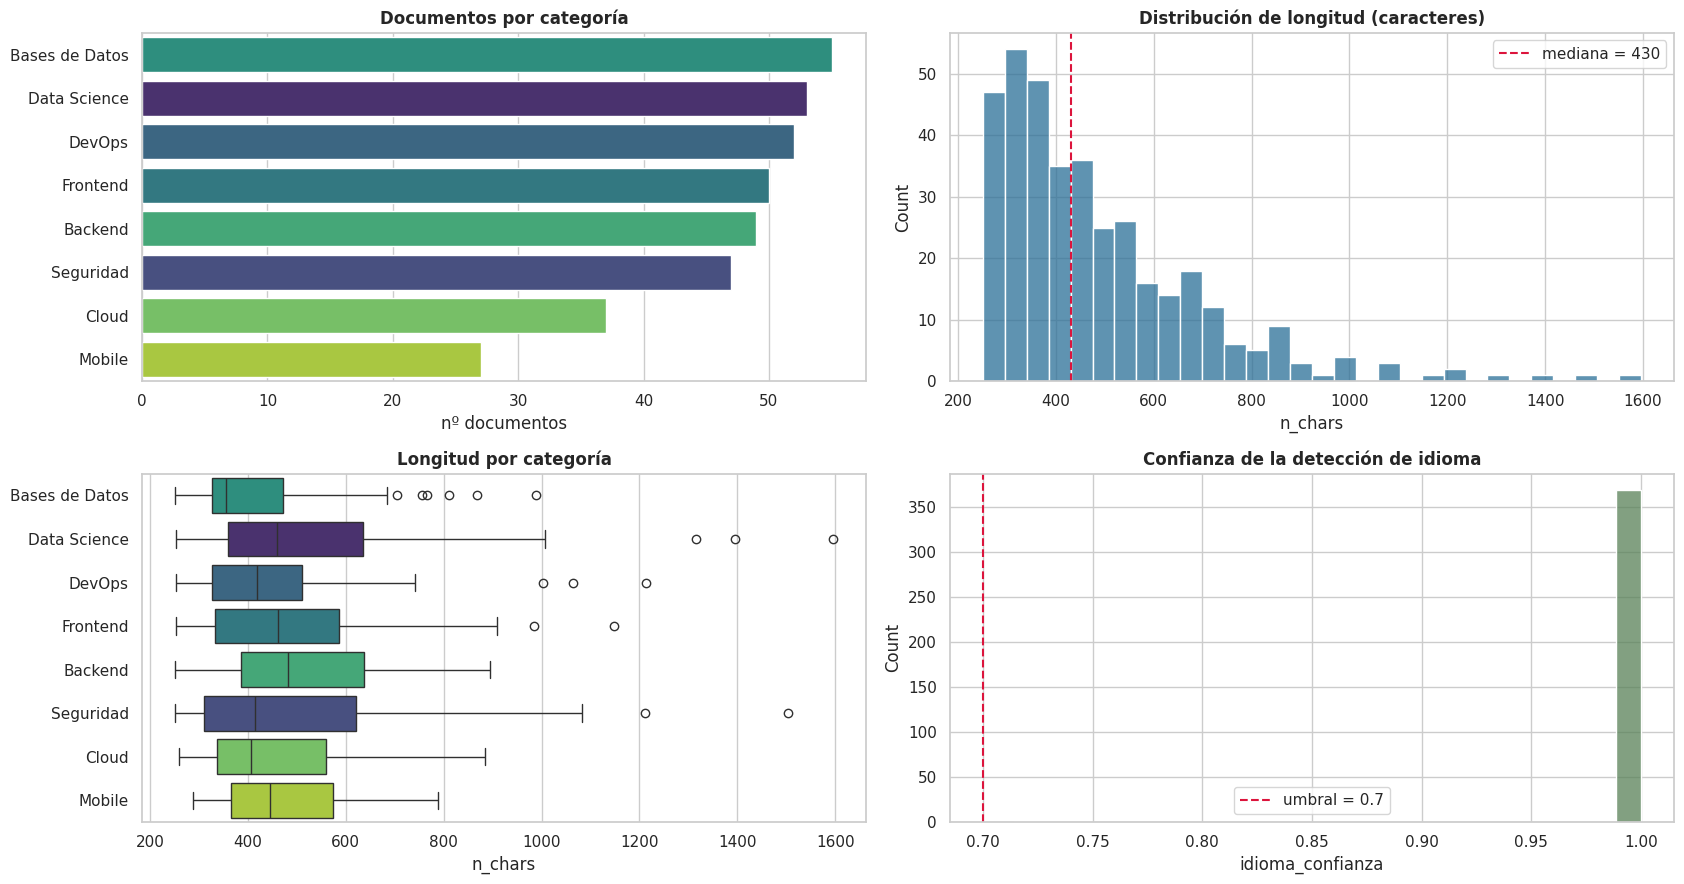

Ratio de desbalance (mayor/menor clase) : 2.04
Longitud media                          : 488 caracteres
Total del corpus                        : 180,493 caracteres
Documentos con confianza de idioma baja : 0 (0.0%)
06:20:52 │ WARNING │ Desbalance > 2:1 — se usará F1-macro y split estratificado (§5.2).


In [ ]:
# @title 2.5 — EDA del corpus recolectado
fig, axes = plt.subplots(2, 2, figsize=(17, 9))

orden = df_raw["categoria"].value_counts().index
sns.countplot(data=df_raw, y="categoria", order=orden, ax=axes[0, 0],
              hue="categoria", palette="viridis", legend=False)
axes[0, 0].set_title("Documentos por categoría", fontweight="bold")
axes[0, 0].set_xlabel("nº documentos"); axes[0, 0].set_ylabel("")

sns.histplot(df_raw["n_chars"], bins=30, ax=axes[0, 1], color="#2a6f97")
axes[0, 1].axvline(df_raw["n_chars"].median(), color="crimson", ls="--",
                   label=f"mediana = {df_raw['n_chars'].median():.0f}")
axes[0, 1].set_title("Distribución de longitud (caracteres)", fontweight="bold")
axes[0, 1].legend()

sns.boxplot(data=df_raw, x="n_chars", y="categoria", order=orden, ax=axes[1, 0],
            hue="categoria", palette="viridis", legend=False)
axes[1, 0].set_title("Longitud por categoría", fontweight="bold"); axes[1, 0].set_ylabel("")

sns.histplot(df_raw["idioma_confianza"], bins=25, ax=axes[1, 1], color="#588157")
axes[1, 1].axvline(CFG.idioma.confianza_minima, color="crimson", ls="--",
                   label=f"umbral = {CFG.idioma.confianza_minima}")
axes[1, 1].set_title("Confianza de la detección de idioma", fontweight="bold")
axes[1, 1].legend()

plt.tight_layout(); plt.show()

desbalance = df_raw["categoria"].value_counts()
n_baja_confianza = int((df_raw["idioma_confianza"] < CFG.idioma.confianza_minima).sum())

print(f"Ratio de desbalance (mayor/menor clase) : {desbalance.max() / desbalance.min():.2f}")
print(f"Longitud media                          : {df_raw['n_chars'].mean():.0f} caracteres")
print(f"Total del corpus                        : {df_raw['n_chars'].sum():,} caracteres")
print(f"Documentos con confianza de idioma baja : {n_baja_confianza} "
      f"({n_baja_confianza / len(df_raw):.1%})")
if desbalance.max() / desbalance.min() > 2:
    log.warning("Desbalance > 2:1 — se usará F1-macro y split estratificado (§5.2).")

---
# 3. Justificación técnica de las decisiones de modelado

Esta sección responde, para cada tecnología del pipeline, cinco preguntas: **qué problema resuelve**,
**por qué fue elegida**, **qué ventajas aporta**, **qué alternativas existían** y **por qué no se
eligieron**. Es un resumen operativo de `Technology_Architecture.md` §5 a §10, escrito desde la
perspectiva de quien va a ejecutar el pipeline.

El criterio que atraviesa todas las decisiones es el mismo: *¿qué stack permite entregar, en el
tiempo disponible, un sistema funcional, demostrable y con una base de código que un evaluador
técnico reconozca como profesional?* No es el mismo criterio que en una arquitectura empresarial a
diez años, y conviene decirlo de frente.

## Diagrama 3 — Arquitectura NLP: qué modelo interviene en qué punto

```mermaid
flowchart LR
    TXT["Texto limpio"] --> SPACY

    subgraph SPACY["spaCy · es_core_news_sm"]
        direction TB
        S1["Tokenizador"]
        S2["POS tagger"]
        S3["Lematizador"]
        S4["NER + EntityRuler"]
        S1 --> S2 --> S3
        S1 --> S4
    end

    SPACY -->|"lemas filtrados por POS"| TFIDF["TF-IDF<br/>scikit-learn<br/>vector disperso ~8k dims"]
    SPACY -->|"entidades TECH"| RANK
    TXT -->|"prosa completa"| SBERT

    subgraph SBERT["Sentence-Transformers<br/>paraphrase-multilingual-MiniLM-L12-v2"]
        E1["Encoder BERT multilingüe"]
        E2["Mean pooling"]
        E3["Normalización L2"]
        E1 --> E2 --> E3
    end

    SBERT -->|"vector denso 384 dims"| KEYBERT["KeyBERT<br/>similitud coseno<br/>doc vs. n-gramas"]
    SBERT -->|"mismo vector"| CLF["Regresión Logística<br/>categoria + probabilidad"]
    SBERT -->|"mismo vector"| BT["BERTopic<br/>UMAP + HDBSCAN + c-TF-IDF"]
    SBERT -->|"mismo vector"| CHROMA[("ChromaDB<br/>índice HNSW")]

    TFIDF --> CLF
    TXT --> YAKE["YAKE<br/>heurísticas estadísticas"]

    KEYBERT --> RANK["Ranking híbrido<br/>Reciprocal Rank Fusion"]
    YAKE --> RANK

    RANK --> OUT["informacion_adicional"]
    CLF --> OUT2["categoria · probabilidad"]
    BT --> OUT3["tema"]
    CHROMA --> OUT4["relacionados"]

    style SBERT fill:#e8f4ea,stroke:#2d6a4f
    style SPACY fill:#e7eef7,stroke:#2a6f97
```

**Lo que el diagrama hace evidente:** un único vector de 384 dimensiones alimenta cuatro capacidades
distintas —keywords, clasificación, clustering y búsqueda—. Esa reutilización es la decisión
arquitectónica central del proyecto: reduce el costo de cómputo por documento a un solo `encode()`, y
elimina la necesidad de mantener tres pipelines de *feature engineering* separados y coherentes entre sí.

## 3.1 spaCy — Procesamiento lingüístico

**Qué problema resuelve.** Antes de vectorizar hay que convertir prosa en unidades léxicas
normalizadas: tokenizar, descartar palabras funcionales sin señal temática, reducir cada palabra a su
forma canónica y quedarse con las categorías gramaticales que cargan contenido. Sin esto, la matriz
TF-IDF se llena de artículos y preposiciones, y `programación`/`programaciones`/`programar` ocupan
tres dimensiones distintas cuando conceptualmente son una.

**Por qué fue elegida.** Cuatro razones concretas: (1) resuelve tokenización, POS, lematización y NER
en **una sola pasada** `nlp(texto)`, frente a NLTK que exige ensamblar módulos independientes;
(2) su núcleo está en Cython, lo que importa porque el preprocesamiento está en el camino crítico de
cada petición a `POST /contenido`; (3) tiene modelos oficiales en español (`es_core_news_sm`), y el
corpus del brief es español; (4) es extensible vía `nlp.add_pipe`, que es exactamente lo que necesita
el `EntityRuler` de §4.1.

**Ventajas.** API unificada y orientada a objetos (`Doc`, `Token`, `Span`). Procesamiento por lotes
con `nlp.pipe`, que amortiza el overhead. Documentación orientada a producción. Componentes
personalizados sin tocar el modelo base.

**Alternativas.** NLTK.

**Por qué no NLTK.** Tres motivos: su API está fragmentada en módulos (`nltk.tokenize`, `nltk.stem`,
`nltk.tag`) que obligan a construir a mano el pipeline que spaCy entrega integrado; su rendimiento es
notablemente menor por estar implementada casi enteramente en Python puro, lo que impacta la latencia
del endpoint; y sus recursos para español son menos completos y menos mantenidos. NLTK sigue siendo
excelente para exploración didáctica, pero no como motor de producción.

## 3.2 Sentence-Transformers — Embeddings semánticos

**Qué problema resuelve.** Comparar textos por **significado** y no por coincidencia literal de
palabras. *"API REST con Java y Spring Boot"* y *"servicio backend en Java construido con el
framework Spring"* comparten poquísimas palabras exactas: para TF-IDF son casi ortogonales, aunque
hablan de lo mismo. Un embedding sitúa ambos textos cerca en el espacio vectorial porque el modelo
fue entrenado para capturar relaciones de significado.

**Por qué fue elegida.** Porque **un solo vector alimenta cuatro capacidades**: clasificación (§5.2),
extracción de keywords vía KeyBERT (§5.1), clustering vía BERTopic (§5.6) y búsqueda semántica vía
ChromaDB (§6). Mantener una representación en vez de tres reduce drásticamente la complejidad del
sistema. Además: los modelos MiniLM corren en **CPU** sin GPU, el modelo elegido es **multilingüe**
—lo que deja abierta la puerta al inglés sin cambiar de espacio vectorial— y la API es una sola
llamada `model.encode(texto)` sin lógica de agregación.

**Ventajas.** Calidad semántica muy superior a TF-IDF en similitud y recomendación. Modelos pequeños
(~120 MB) con latencia aceptable en tiempo real. Catálogo amplio en Hugging Face Hub. Compatibilidad
directa con ChromaDB y con KeyBERT.

**Alternativas.** TF-IDF puro, Word2Vec/GloVe, embeddings vía API comercial (OpenAI, Cohere).

**Por qué no las alternativas.**
- *TF-IDF puro*: no captura sinónimos ni paráfrasis, lo que limitaría gravemente la recomendación y
  la búsqueda semántica. **No se descartó del todo**: se mantiene como baseline de comparación en
  §5.2 y como motor interno de c-TF-IDF en BERTopic.
- *Word2Vec/GloVe*: producen vectores de **palabra**, no de oración; requerirían promediar los
  vectores del documento, lo que degrada la calidad frente a un modelo entrenado específicamente para
  oraciones completas. Además, obtener vectores de calidad en español añade descargas grandes sin
  ganancia clara.
- *API comercial*: altísima calidad, pero introduce dependencia de red externa durante una demo en
  vivo, costo por token sin presupuesto asignado y una API key adicional que gestionar además de las
  credenciales de OCI. El riesgo operativo no se justifica.

**La desventaja que sí duele.** Un modelo multilingüe genérico no captura jerga técnica muy
específica tan bien como uno afinado sobre corpus técnico. Lo mitigamos combinando embeddings con el
`EntityRuler` de reglas (§4.1), y lo dejamos anotado como trabajo futuro (§9).

## 3.3 KeyBERT — Extracción de palabras clave

**Qué problema resuelve.** El brief pide `informacion_adicional: ["Java", "Spring Boot", "API REST"]`
— una lista corta de términos técnicos verdaderamente representativos, no las palabras más
frecuentes. En textos de una o dos oraciones, "más frecuente" y "más representativo" casi nunca
coinciden.

**Por qué fue elegida.** Porque **reutiliza el modelo de embeddings ya cargado**: no añade una
dependencia nueva ni un segundo modelo en memoria. La misma instancia de Sentence-Transformers que
calcula el vector del documento sirve para rankear las frases candidatas por similitud coseno contra
ese vector. En documentos cortos —el caso del brief— esto supera claramente a TF-IDF, cuyo IDF
necesita un corpus grande para ser informativo.

**Ventajas.** No requiere corpus de referencia: funciona documento por documento, incluso sobre
contenido nunca visto. Soporta n-gramas configurables, capturando términos compuestos como
"Spring Boot" o "API REST". Ofrece MMR (*Maximal Marginal Relevance*) para diversificar y evitar
devolver "API" y "API REST" como dos keywords casi idénticas.

**Alternativas.** TF-IDF, YAKE.

**Por qué no las alternativas.** TF-IDF depende de un corpus de referencia representativo para
calcular el IDF, y el corpus de un hackathon es pequeño y heterogéneo. YAKE funciona bien en textos
cortos con heurísticas (posición, capitalización, dispersión) pero **no comparte infraestructura** con
el resto del pipeline: obligaría a mantener una lógica de keywords aislada, sin beneficiarse de la
comprensión semántica ya construida.

**Lo que hicimos en la práctica.** No elegimos uno y descartamos los demás: implementamos **los tres**
y los fusionamos con *Reciprocal Rank Fusion* (§5.1), añadiendo como cuarta señal las entidades del
`EntityRuler`. Cada método aporta algo que los otros no: KeyBERT capta relevancia semántica, YAKE
capta lo distintivo sin necesitar corpus, y el EntityRuler garantiza —por construcción, con precisión
de reglas— que "Spring Boot" nunca se pierda.

## 3.4 BERTopic — Descubrimiento de tópicos

**Qué problema resuelve.** Agrupar automáticamente los documentos por temática **sin definir de
antemano cuántos temas hay ni etiquetarlos a mano**. Es distinto de la clasificación: la
clasificación asigna a una taxonomía que nosotros impusimos al recolectar; el clustering descubre la
estructura que los datos realmente tienen, que puede no coincidir — y ese desacuerdo es información
valiosa, no un error.

**Por qué fue elegida.** Tres razones: (1) **no exige fijar `k`**; usa HDBSCAN, que descubre el
número de grupos por densidad, evitando una decisión arbitraria cuando no se sabe cuántos temas hay;
(2) **genera etiquetas legibles automáticamente** vía c-TF-IDF ("Tema 3: Java, Spring Boot, API
REST"), directamente presentables sin inspección manual; (3) **reutiliza los mismos embeddings** ya
calculados, sin cómputo adicional.

**Ventajas.** Maneja el ruido explícitamente: un documento que no encaja en ningún tema se marca como
*outlier* (tópico `-1`) en vez de forzarlo dentro de un grupo al que no pertenece. Maneja clusters de
forma y tamaño irregular, cosa que KMeans no puede porque asume grupos esféricos y equilibrados.
Trae visualizaciones incorporadas.

**Alternativas.** KMeans sobre embeddings, LDA.

**Por qué no las alternativas.** KMeans exige `k` de antemano y asume geometría esférica, supuesto
que rara vez se cumple con contenido técnico heterogéneo (siempre hay más artículos de un tema que de
otro). LDA opera sobre bolsas de palabras, no sobre embeddings: perdería toda la señal semántica que
ya pagamos por calcular. **KMeans no se descarta del todo**: lo mantenemos en §5.6 como comparación
metodológica, con selección de `k` por codo y silueta, para demostrar que la elección de BERTopic fue
razonada y no por defecto.

**La desventaja honesta.** Con corpus pequeños HDBSCAN puede marcar una fracción alta de documentos
como ruido. Lo mitigamos bajando `min_topic_size` en proporción al tamaño del corpus, y por eso
mantenemos KMeans como respaldo documentado.

## 3.5 ChromaDB — Base de datos vectorial

**Qué problema resuelve.** Dado un vector de consulta, encontrar eficientemente los `N` vectores más
cercanos de la colección. Una base relacional no puede hacerlo: `ORDER BY` sobre una columna numérica
no resuelve una búsqueda por similitud coseno en 384 dimensiones. La fuerza bruta funciona con cien
documentos y deja de funcionar con cien mil. Las bases vectoriales indexan con estructuras
especializadas —grafos HNSW— que resuelven vecinos aproximados en tiempo sub-lineal.

**Por qué fue elegida.** Porque es **autoalojable**: corre embebida o como contenedor dentro de la
misma infraestructura del equipo, sin depender de un proveedor SaaS externo. Esto importa
específicamente porque el brief exige integración con **OCI**: meter un servicio vectorial de un
tercero no aporta nada a ese requisito y sí añade un punto de falla durante la demo en vivo. Además
es gratuita, tiene una API de Python que se aprende en minutos y se despliega como un contenedor más
del `docker-compose.yml`.

**Ventajas.** Persiste **metadatos junto al vector**, lo que permite filtrar la búsqueda semántica por
categoría en una sola consulta (`documentos similares a X, pero solo de Backend`) sin ir a PostgreSQL
en el camino crítico. Sin dependencia de red externa. Integración directa con embeddings de
Sentence-Transformers.

**Alternativas.** Pinecone, FAISS, `pgvector` sobre PostgreSQL.

**Por qué no las alternativas.**
- *Pinecone*: requiere cuenta y API key externas a OCI, tiene costo más allá de una capa gratuita
  limitada, y añade dependencia de red durante la demo. Excelente producto, contexto equivocado.
- *FAISS*: **es una librería de indexación, no una base de datos**. No persiste metadatos, no expone
  servidor ni API lista para usar, no filtra por metadatos. Adoptarla obligaría a reimplementar a
  mano lo que ChromaDB ya resuelve. Nota: ChromaDB puede usar HNSW/FAISS como motor interno, así que
  el proyecto se beneficia indirectamente de esa tecnología sin pagar el costo de integrarla.
- *`pgvector`*: unificaría metadatos y vectores en un solo motor, lo cual es atractivo a largo plazo.
  Se descarta **para el MVP** por simplicidad operativa, y queda anotado en §9 como el camino natural
  de consolidación si el proyecto continúa.

**Cómo convive con PostgreSQL.** No compiten, se complementan. PostgreSQL responde *"¿qué documentos
son de categoría Backend?"*; ChromaDB responde *"¿qué documentos se parecen semánticamente a este?"*.
Un mismo documento vive en ambos, unido por un identificador común — el patrón estándar
*vector store + metadata store*.

## 3.6 Tabla de decisión consolidada

| Componente | Elegido | Alternativas descartadas | Criterio decisivo |
|---|---|---|---|
| NLP | **spaCy** | NLTK | Pipeline integrado + rendimiento Cython + modelos ES oficiales |
| Embeddings | **Sentence-Transformers (SBERT)** | TF-IDF puro, Word2Vec/GloVe, API comercial | Un vector reutilizado por 4 capacidades, CPU, sin dependencia externa |
| Keywords | **KeyBERT** (+ YAKE + EntityRuler, fusionados) | TF-IDF, YAKE en solitario | Reutiliza el modelo de embeddings; no necesita corpus de referencia |
| Clustering | **BERTopic** | KMeans, LDA | No exige `k`, etiquetas legibles automáticas, maneja outliers |
| Clasificador | **Regresión Logística** | SVM, Random Forest, fine-tuning de BERT | Probabilidades calibradas (`predict_proba`), interpretable, entrena en segundos |
| Base vectorial | **ChromaDB** | Pinecone, FAISS, pgvector | Autoalojable en OCI, gratuita, metadatos junto al vector |
| Serialización | **joblib** | pickle | Eficiente con arrays de numpy; es lo que pide el brief |

**Sobre la Regresión Logística**, que el brief sugiere explícitamente: la elegimos porque produce
**probabilidades**, y el contrato de salida exige un campo `probabilidad`. Un SVM da distancias al
hiperplano, no probabilidades, y calibrarlas requiere `CalibratedClassifierCV` y un split adicional.
Random Forest da probabilidades pero mal calibradas en problemas de alta dimensión y pocos datos. Un
fine-tuning de BERT superaría a todos en precisión, pero requiere GPU y horas de entrenamiento que un
hackathon no tiene — queda anotado en §9.

---
# 4. Preprocesamiento NLP
### Etapa 2 del diagrama

> **Tokenización & Stopwords → Lematización → Filtrado por POS Tagging → Reconocimiento de entidades**

Convertimos prosa validada en las dos representaciones que el modelado necesita: una secuencia de
lemas filtrados (insumo de TF-IDF) y un conjunto de entidades técnicas (insumo del ranking de
keywords). Una sola pasada de spaCy produce ambas.

**Lematización, no stemming.** El diagrama del brief ofrece ambas. Elegimos lematización porque el
stemming trunca por reglas ortográficas y produce raíces que no son palabras
(*"programación" → "program"*), lo cual degrada la legibilidad de las keywords que el brief espera
devolver al usuario en `informacion_adicional`. La lematización devuelve la forma canónica del
diccionario, presentable tal cual.

**Aquí es donde se baja a minúsculas** — en el lema, no antes. La razón la explicamos en §2.4: el POS
tagger y el NER de spaCy usan la capitalización como señal, y `Java` en minúscula deja de ser
reconocible como nombre propio. Bajar a minúsculas antes de spaCy destruye información que spaCy
necesita; hacerlo después, sobre el lema, es gratis.

## 4.1 Pipeline de spaCy y reconocimiento de entidades técnicas

**El problema concreto que resuelve el `EntityRuler`.** El modelo `es_core_news_sm` fue entrenado
sobre noticias y texto general en español: reconoce personas, lugares y organizaciones, pero no sabe
que "Spring Boot" o "FastAPI" son tecnologías. Sobre el ejemplo del brief, el NER estadístico no
etiqueta ninguna de las tres tecnologías que el enunciado espera ver en `informacion_adicional`. Es
una limitación conocida y documentada en `Technology_Architecture.md` §5.

**La solución.** Un `EntityRuler` insertado **antes** del NER estadístico, con un diccionario de
~140 tecnologías agrupadas por dominio. Es un componente basado en reglas, con dos propiedades que
lo hacen valioso aquí:

- **Precisión perfecta por construcción.** Si "Docker" está en el diccionario y aparece en el texto,
  se detecta. No hay incertidumbre que ponderar — y por eso el ranking de keywords (§5.2) le asigna
  el peso más alto de las cuatro señales.
- **Cobertura finita y explícita.** Lo que no está listado, no se detecta. Es una limitación real
  (§9.2, punto 4), pero es *visible y auditable*: se sabe exactamente qué reconoce el sistema, cosa
  que no ocurre con un modelo estadístico.

El orden importa: `before="ner"` hace que las reglas tengan prioridad sobre el modelo estadístico,
evitando que "Java" se etiquete como `LOC` (la isla) en vez de `TECH`.

In [ ]:
# @title 4.1 — Pipeline de spaCy + EntityRuler de tecnologías
import spacy

# Diccionario de tecnologías. El modelo base en español no reconoce estos nombres como
# entidades (Technology_Architecture.md §5, "Desventajas"): el EntityRuler lo corrige
# por reglas, con precisión de 100% sobre los términos listados.
TECNOLOGIAS = [
    # Lenguajes
    "Java", "Python", "JavaScript", "TypeScript", "Kotlin", "Swift", "Go", "Rust",
    "C#", "C++", "PHP", "Ruby", "Scala", "Perl", "R", "Dart", "Elixir",
    # Frameworks backend
    "Spring Boot", "Spring", "Django", "Flask", "FastAPI", "Node.js", "Express",
    "Laravel", ".NET", "ASP.NET", "Rails", "NestJS", "Quarkus", "Micronaut",
    # Frontend
    "React", "React Native", "Angular", "Vue.js", "Next.js", "Svelte", "Nuxt",
    "TailwindCSS", "Bootstrap", "HTML", "CSS", "Sass", "Webpack", "Vite", "DOM", "jQuery",
    # Datos
    "PostgreSQL", "MySQL", "MongoDB", "Redis", "SQLite", "Oracle", "SQL", "NoSQL",
    "ChromaDB", "Elasticsearch", "Cassandra", "DynamoDB", "Neo4j", "pgvector", "SQLAlchemy",
    # DevOps e infraestructura
    "Docker", "Kubernetes", "Jenkins", "GitLab", "GitHub", "Git", "Terraform",
    "Ansible", "Nginx", "Apache", "Helm", "Prometheus", "Grafana", "CI/CD",
    # Cloud
    "AWS", "Azure", "Google Cloud", "OCI", "Oracle Cloud", "Object Storage",
    "Lambda", "Kafka", "RabbitMQ", "S3", "EC2", "Cloud Functions",
    # Ciencia de datos y ML
    "TensorFlow", "PyTorch", "Scikit-Learn", "Pandas", "NumPy", "spaCy", "BERT",
    "Transformers", "Keras", "XGBoost", "Hugging Face", "Jupyter", "Matplotlib", "NLTK",
    # Protocolos y formatos
    "API REST", "REST", "GraphQL", "gRPC", "JSON", "XML", "YAML", "OAuth", "JWT",
    "HTTPS", "TLS", "SSL", "WebSocket", "HTTP", "SOAP", "OpenAPI", "Swagger",
    # Móvil
    "Android", "iOS", "Flutter", "Xamarin", "Ionic",
    # Conceptos
    "machine learning", "deep learning", "microservicios", "aprendizaje automático",
    "redes neuronales", "computación en la nube", "arquitectura hexagonal",
    "inyección de dependencias", "programación orientada a objetos", "test unitario",
]


def construir_pipeline_nlp(codigo_idioma: str = CFG.idioma.idioma_objetivo,
                           tecnologias: list = TECNOLOGIAS):
    """Carga el pipeline de spaCy del idioma indicado y le añade el EntityRuler.

    Args:
        codigo_idioma: Código ISO 639-1 del idioma.
        tecnologias: Lista de términos técnicos a reconocer como entidades TECH.

    Returns:
        El objeto `Language` de spaCy con el componente `entity_ruler` activo.

    Example:
        >>> nlp = construir_pipeline_nlp("es")
        >>> [e.text for e in nlp("APIs REST con Spring Boot").ents if e.label_ == "TECH"]
        ['REST', 'Spring Boot']
    """
    modelo = REGISTRO_IDIOMAS.obtener(codigo_idioma)
    if "entity_ruler" not in modelo.pipe_names:
        ruler = modelo.add_pipe("entity_ruler", before="ner")
        ruler.add_patterns([{"label": "TECH", "pattern": t} for t in tecnologias])
        log.info(f"EntityRuler añadido con {len(tecnologias)} patrones de tecnologías")
    return modelo


nlp = construir_pipeline_nlp()

log.info(f"Pipeline spaCy activo: {nlp.pipe_names}")
doc_demo = nlp("En este contenido se presentan los conceptos básicos para la creación de "
               "APIs REST utilizando Java y Spring Boot sobre Docker.")
print("Pipeline :", nlp.pipe_names)
print("Patrones :", len(TECNOLOGIAS), "tecnologías registradas")
print("Entidades TECH detectadas:", [e.text for e in doc_demo.ents if e.label_ == "TECH"])

06:20:53 │ INFO    │ Pipeline spaCy cargado para 'es': es_core_news_sm
06:20:53 │ INFO    │ EntityRuler añadido con 134 patrones de tecnologías
06:20:53 │ INFO    │ Pipeline spaCy activo: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'entity_ruler', 'ner']
Pipeline : ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'entity_ruler', 'ner']
Patrones : 134 tecnologías registradas
Entidades TECH detectadas: ['REST', 'Java', 'Spring Boot', 'Docker']


## 4.2 Las cuatro cajas de la etapa 2, en una sola pasada

`preprocesar()` recorre el `Doc` **una vez** y produce simultáneamente los cuatro artefactos que el
diagrama presenta como pasos secuenciales. No es una micro-optimización caprichosa: recorrer cuatro
veces la misma estructura para aplicar cuatro filtros que ya tienen toda la información disponible en
el primer recorrido es trabajo redundante en el camino crítico de cada petición HTTP.

Las decisiones de filtrado y su porqué:

- **Se descartan** espacios, puntuación, números y dígitos: no aportan señal temática y ensucian el
  vocabulario de TF-IDF.
- **Se descartan las stopwords de spaCy** más una lista propia (`stopwords_extra`) de verbos y
  sustantivos genéricos —"ser", "hacer", "forma", "caso"— que sobreviven al filtro estándar pero
  aparecen en todas las categorías por igual, es decir, no discriminan.
- **Se descartan tokens de menos de 3 caracteres**, que en español técnico son casi siempre
  preposiciones o siglas ambiguas.
- **`lemas_pos` conserva solo `NOUN`, `PROPN` y `ADJ`**: el contenido temático de un texto técnico
  vive en sus sustantivos y adjetivos. Los verbos, en documentación técnica, son mayoritariamente de
  proceso genérico ("permite", "utiliza", "configura") y aportan poco a la discriminación entre
  categorías.

In [ ]:
# @title 4.2 — Tokenización, stopwords, lematización y filtrado POS en una pasada
STOPWORDS_EXTRA = set(CFG.nlp.stopwords_extra)


def preprocesar(doc, cfg: Config = CFG) -> dict:
    """Extrae tokens, lemas, lemas filtrados por POS y entidades de un Doc de spaCy.

    Resuelve en una sola iteración las cuatro cajas de la etapa 2 del diagrama:
    tokenización, eliminación de stopwords, lematización y filtrado por categoría
    gramatical. La conversión a minúsculas ocurre aquí, sobre el lema, para no
    privar al POS tagger y al NER de la señal de capitalización.

    Args:
        doc: Objeto `Doc` producido por el pipeline de spaCy.
        cfg: Configuración con las POS relevantes y la longitud mínima de token.

    Returns:
        Diccionario con las claves `tokens`, `lemas`, `lemas_pos`, `texto_lemas`,
        `texto_pos`, `entidades_tech` y `n_tokens`.

    Example:
        >>> p = preprocesar(nlp("Las APIs REST usan el protocolo HTTP para comunicarse."))
        >>> "api" in p["texto_pos"] or "rest" in p["texto_pos"]
        True
    """
    tokens_validos, lemas, lemas_pos = [], [], []
    pos_relevantes = set(cfg.nlp.pos_relevantes)

    for token in doc:
        # --- Tokenización: descarte de ruido no léxico ---
        if token.is_space or token.is_punct or token.like_num or token.is_digit:
            continue
        # --- Stopwords y tokens demasiado cortos ---
        if token.is_stop or len(token.text) < cfg.nlp.long_minima_token:
            continue
        # --- Lematización (y aquí sí, minúsculas) ---
        lema = token.lemma_.lower().strip()
        if not lema or lema in STOPWORDS_EXTRA:
            continue
        tokens_validos.append(token.text.lower())
        lemas.append(lema)
        # --- Filtrado por POS tagging ---
        if token.pos_ in pos_relevantes:
            lemas_pos.append(lema)

    entidades = sorted({e.text for e in doc.ents if e.label_ in cfg.nlp.etiquetas_entidad})

    return {
        "tokens": tokens_validos,
        "lemas": lemas,
        "lemas_pos": lemas_pos,
        "texto_lemas": " ".join(lemas),
        "texto_pos": " ".join(lemas_pos),
        "entidades_tech": entidades,
        "n_tokens": len(tokens_validos),
    }


@cronometrar("preprocesamiento NLP del corpus")
def preprocesar_corpus(df: pd.DataFrame, modelo_nlp, cfg: Config = CFG) -> pd.DataFrame:
    """Aplica `preprocesar` a todo el corpus usando procesamiento por lotes.

    `nlp.pipe` amortiza el overhead de construcción del Doc y es sustancialmente
    más rápido que llamar `nlp(texto)` documento a documento.

    Args:
        df: DataFrame con la columna `texto_limpio`.
        modelo_nlp: Pipeline de spaCy a aplicar.
        cfg: Configuración con el batch size.

    Returns:
        El DataFrame original con las columnas de preprocesamiento añadidas.
    """
    resultados = [
        preprocesar(d, cfg)
        for d in modelo_nlp.pipe(df["texto_limpio"].tolist(),
                                 batch_size=cfg.nlp.batch_size_spacy)
    ]
    salida = pd.concat([df.reset_index(drop=True), pd.DataFrame(resultados)], axis=1)
    log.info(f"Preprocesamiento completado: {len(salida)} documentos, "
             f"{salida['n_tokens'].sum():,} tokens conservados")
    return salida


with etapa("preprocesamiento NLP"):
    df = preprocesar_corpus(df_raw, nlp)

df[["doc_id", "categoria", "n_tokens", "texto_pos"]].head(5)

06:20:53 │ INFO    │ ┌─ etapa · preprocesamiento NLP
06:20:53 │ INFO    │ ▶ inicio · preprocesamiento NLP del corpus
06:20:58 │ INFO    │ Preprocesamiento completado: 370 documentos, 13,288 tokens conservados
06:20:58 │ INFO    │ ✔ fin    · preprocesamiento NLP del corpus en 5.10s
06:20:58 │ INFO    │ └─ etapa · preprocesamiento NLP completada en 5.10s


,doc_id,categoria,n_tokens,texto_pos
0,DOC-0000,Data Science,115,historia pln trabajo anterior alan turing computing machinery and intelligence test turing criterio cualitativo inte...
1,DOC-0001,Seguridad,108,campo ciberseguridad modelo evaluación riesgo efectivo aspecto relacionado riesgo cibernético modelo cubo mccumber p...
2,DOC-0002,Data Science,105,red neuronal minimización riesgo empírico método idea parámetro red diferencia riesgo empírico resultado previsto va...
3,DOC-0003,Data Science,86,procesamiento lenguaje natural lengua natural abreviado pln nlp sigla inglés campo ciencia computación inteligencia ...
4,DOC-0004,DevOps,79,general enfoque iac declarativo funcional imperativo procedimiento inteligente consciente entorno diferencia enfoque...


## 4.3 Trazabilidad del pipeline

Antes de confiar en resultados agregados sobre cientos de documentos, conviene ver el pipeline
completo actuando sobre **un** documento conocido — el ejemplo literal del enunciado del brief. Si
alguna etapa está mal configurada, aquí se ve; en una métrica promediada, no.

La tabla token a token del final es deliberada: muestra qué conserva y qué descarta cada filtro, y es
el material que permite discutir con el jurado *por qué* el sistema eligió esas keywords.

In [ ]:
# @title 4.3 — Trazabilidad: el pipeline paso a paso sobre el ejemplo del brief
EJEMPLO = ("En este contenido se presentan los conceptos básicos para la creación de "
           "APIs REST utilizando Java y Spring Boot.")

d = nlp(limpiar_texto(EJEMPLO))
p = preprocesar(d)

print("TEXTO ORIGINAL\n ", EJEMPLO)
print("\n0) VALIDACIÓN      ->", "aceptado" if validar_entrada("Ejemplo del brief", EJEMPLO).valido else "rechazado")
print("1) IDIOMA          ->", detectar_idioma(EJEMPLO).a_dict())
print("2) LIMPIEZA        ->", limpiar_texto(EJEMPLO))
print("3) TOKENIZACIÓN + STOPWORDS ->", p["tokens"])
print("4) LEMATIZACIÓN    ->", p["lemas"])
print(f"5) FILTRADO POS {sorted(CFG.nlp.pos_relevantes)} ->", p["lemas_pos"])
print("6) ENTIDADES TÉCNICAS ->", p["entidades_tech"])

print("\n" + "-" * 80)
print(f"{'TOKEN':<18}{'LEMA':<18}{'POS':<10}{'STOP':<8}{'CONSERVADO'}")
print("-" * 80)
for t in d[:18]:
    conservado = ("sí" if (t.pos_ in CFG.nlp.pos_relevantes and not t.is_stop
                           and not t.is_punct) else "no")
    print(f"{t.text:<18}{t.lemma_:<18}{t.pos_:<10}{str(t.is_stop):<8}{conservado}")

TEXTO ORIGINAL
  En este contenido se presentan los conceptos básicos para la creación de APIs REST utilizando Java y Spring Boot.

0) VALIDACIÓN      -> aceptado
1) IDIOMA          -> {'codigo': 'es', 'confianza': 1.0, 'metodo': 'langdetect', 'soportado': True}
2) LIMPIEZA        -> En este contenido se presentan los conceptos básicos para la creación de APIs REST utilizando Java y Spring Boot.
3) TOKENIZACIÓN + STOPWORDS -> ['contenido', 'presentan', 'conceptos', 'básicos', 'creación', 'apis', 'rest', 'utilizando', 'java', 'spring', 'boot']
4) LEMATIZACIÓN    -> ['contenido', 'presentar', 'concepto', 'básico', 'creación', 'apis', 'rest', 'utilizar', 'java', 'spring', 'boot']
5) FILTRADO POS ['ADJ', 'NOUN', 'PROPN'] -> ['contenido', 'concepto', 'básico', 'creación', 'apis', 'rest', 'java', 'spring', 'boot']
6) ENTIDADES TÉCNICAS -> ['Java', 'REST', 'Spring Boot']

--------------------------------------------------------------------------------
TOKEN             LEMA              POS  

## 4.4 EDA sobre el texto ya procesado

Segunda ronda de exploración, ahora sobre el texto transformado. Responde dos preguntas que solo
tienen sentido después del preprocesamiento:

1. **¿Cuánto ruido eliminamos?** La reducción de tokens por etapa cuantifica el efecto del filtrado.
   Una reducción demasiado baja indicaría que el filtro no está actuando; una demasiado alta, que
   estamos descartando señal útil.
2. **¿Son las categorías léxicamente separables?** Los términos más frecuentes por categoría son una
   señal cualitativa previa al entrenamiento: si dos categorías comparten sus ocho términos
   principales, el clasificador léxico las va a confundir, y lo veremos confirmado en la matriz de
   confusión de §5.4.2.

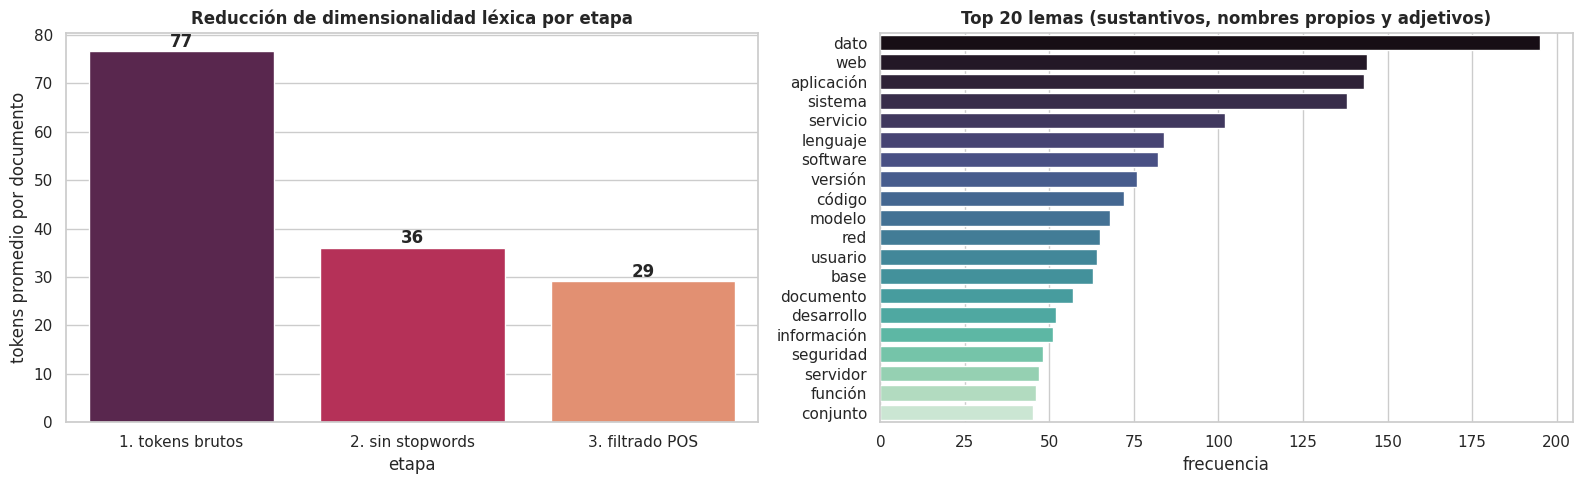

Reducción total de tokens: 62.0%

Términos más frecuentes por categoría (señal cualitativa de separabilidad):

  Backend            servicio, web, aplicación, dato, sistema, java, software, lenguaje
  Bases de Datos     dato, base, relacional, sistema, lenguaje, tabla, sql, clave
  Cloud              servicio, nube, software, aplicación, dato, sistema, usuario, microsoft
  Data Science       dato, aprendizaje, automático, modelo, documento, ciencia, red, análisis
  DevOps             sistema, versión, software, aplicación, devops, desarrollo, código, herramienta
  Frontend           web, html, aplicación, página, navegador, javascript, documento, dispositivo
  Mobile             aplicación, android, kotlin, sistema, lenguaje, móvil, java, versión
  Seguridad          seguridad, información, autenticación, protocolo, usuario, oauth, red, sistema

Documentos con al menos una entidad técnica detectada: 227/370 (61.4%)
06:20:59 │ INFO    │ Corpus preprocesado guardado en data_science/datas

In [ ]:
# @title 4.4 — EDA sobre el texto ya procesado
df["n_lemas_pos"] = df["lemas_pos"].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

reduccion = pd.DataFrame({
    "etapa": ["1. tokens brutos", "2. sin stopwords", "3. filtrado POS"],
    "promedio": [
        df["texto_limpio"].str.split().apply(len).mean(),
        df["n_tokens"].mean(),
        df["n_lemas_pos"].mean(),
    ],
})
sns.barplot(data=reduccion, x="etapa", y="promedio", ax=axes[0],
            hue="etapa", palette="rocket", legend=False)
axes[0].set_title("Reducción de dimensionalidad léxica por etapa", fontweight="bold")
axes[0].set_ylabel("tokens promedio por documento")
for i, v in enumerate(reduccion["promedio"]):
    axes[0].text(i, v + 1, f"{v:.0f}", ha="center", fontweight="bold")

top = Counter([l for lista in df["lemas_pos"] for l in lista]).most_common(20)
_pal = [w for w, _ in top]
sns.barplot(x=[c for _, c in top], y=_pal, ax=axes[1],
            hue=_pal, palette="mako", legend=False)
axes[1].set_title("Top 20 lemas (sustantivos, nombres propios y adjetivos)", fontweight="bold")
axes[1].set_xlabel("frecuencia")

plt.tight_layout(); plt.show()

tasa = 1 - reduccion["promedio"].iloc[2] / reduccion["promedio"].iloc[0]
print(f"Reducción total de tokens: {tasa:.1%}\n")

print("Términos más frecuentes por categoría (señal cualitativa de separabilidad):\n")
for cat in sorted(df["categoria"].unique()):
    lemas_cat = [l for lista in df.loc[df["categoria"] == cat, "lemas_pos"] for l in lista]
    tops = ", ".join(w for w, _ in Counter(lemas_cat).most_common(8))
    print(f"  {cat:<18} {tops}")

n_con_entidades = int((df["entidades_tech"].apply(len) > 0).sum())
print(f"\nDocumentos con al menos una entidad técnica detectada: "
      f"{n_con_entidades}/{len(df)} ({n_con_entidades / len(df):.1%})")

df.to_csv(CFG.rutas.processed / "corpus_processed.csv", index=False)
log.info(f"Corpus preprocesado guardado en {CFG.rutas.processed / 'corpus_processed.csv'}")

---
# 5. Extracción de keywords y modelado
### Etapa 3 del diagrama

El diagrama del brief plantea una **bifurcación** explícita en el nodo *Enfoque de Modelado*:

```
                    ┌─ Estadístico / Frecuencia ─► TF-IDF o YAKE ─┐
   Enfoque de ──────┤                                             ├─► Ranking & Selección
    Modelado        └─ Semántico / Embeddings ──► KeyBERT/SBERT ──┘         │
                                                                            ▼
                                                              Agrupamiento / Clustering
```

**Implementamos ambas ramas y las comparamos** — no elegimos una a ciegas. Esto responde al diagrama,
que las presenta como alternativas, y al criterio de rigor analítico de `Technology_Architecture.md`
§7: mostrar que se evaluó más de un enfoque antes de adoptar uno como método de producción.

La sección se organiza en siete bloques:

| Bloque | Qué produce | Sección |
|---|---|---|
| Representaciones | Matriz TF-IDF dispersa + matriz de embeddings densa | §5.1 |
| Keywords | `informacion_adicional` por fusión de cuatro señales | §5.2 |
| Clasificación | `categoria` + `probabilidad` | §5.3 |
| Evaluación | Accuracy, precision, recall, F1, matriz de confusión, CV | §5.4 |
| Explicabilidad | Por qué el modelo decidió lo que decidió | §5.5 |
| Clustering | Tópicos emergentes con etiquetas legibles | §5.6 |
| Serialización | Artefactos `.joblib` + `metadata.json` versionado | §5.7 |

## Diagrama 4 — Flujo de generación de embeddings (con caché)

```mermaid
flowchart TD
    IN["Lote de textos limpios"] --> H["Para cada texto:<br/>clave = SHA256(modelo ‖ normalizar ‖ texto)"]
    H --> Q{"¿clave presente<br/>en la caché?"}

    Q -->|"sí · acierto"| HIT["Recuperar vector<br/>del diccionario en memoria"]
    Q -->|"no · fallo"| MISS["Acumular en lote pendiente"]

    MISS --> BATCH{"¿Lote pendiente<br/>no vacío?"}
    BATCH -->|no| ENS
    BATCH -->|sí| ENC["SentenceTransformer.encode<br/>batch_size = 32"]

    subgraph ENCODER["Encoder · paraphrase-multilingual-MiniLM-L12-v2"]
        T1["Tokenización WordPiece"]
        T2["12 capas Transformer"]
        T3["Mean pooling sobre tokens"]
        T4["Normalización L2"]
        T1 --> T2 --> T3 --> T4
    end

    ENC --> ENCODER
    ENCODER --> UPD["Escribir vectores nuevos<br/>en la caché"]
    UPD --> PERSIST[("embeddings_cache.joblib<br/>en disco")]
    UPD --> ENS

    HIT --> ENS["Ensamblar matriz<br/>en el orden de entrada"]
    ENS --> OUT["ndarray (n_docs, 384)<br/>float32, norma 1"]

    OUT --> U1["Clasificación §5.3"]
    OUT --> U2["KeyBERT §5.2"]
    OUT --> U3["BERTopic §5.6"]
    OUT --> U4["ChromaDB §6"]

    style ENCODER fill:#e8f4ea,stroke:#2d6a4f
    style PERSIST fill:#fdf4e3,stroke:#b07d2b
```

**Por qué la caché importa.** Codificar es la operación más costosa del pipeline: domina el tiempo de
ejecución del notebook y, en producción, la latencia de `POST /contenido`. Como los vectores son
deterministas dada la tupla (modelo, texto), recalcularlos es trabajo puro desperdiciado. La caché
convierte el ciclo de desarrollo —donde uno reejecuta el notebook decenas de veces cambiando solo el
clasificador— de minutos a segundos, y en producción evita recodificar contenido reenviado.

La clave incluye el **nombre del modelo** y el flag de **normalización**: cambiar de modelo invalida
automáticamente las entradas afectadas, sin necesidad de purgar la caché a mano.

## 5.1 Las dos representaciones del texto

Un mismo documento se representa de dos maneras que capturan cosas distintas, y esa diferencia es el
objeto del experimento de §5.3.

**TF-IDF (léxica, dispersa, ~8.000 dimensiones).** Pondera cada término por su frecuencia en el
documento penalizada por su frecuencia en el corpus: un término que aparece en todos los documentos
no discrimina. La alimentamos con los lemas ya filtrados por POS, de modo que la matriz contenga solo
sustantivos, nombres propios y adjetivos en forma canónica. Es interpretable —cada dimensión es una
palabra— y muy barata de calcular, pero ciega a los sinónimos.

**Embeddings SBERT (semántica, densa, 384 dimensiones).** Un vector por documento donde la cercanía
geométrica corresponde a cercanía de significado. Los calculamos sobre el **texto limpio completo**,
no sobre los lemas: el modelo fue entrenado con lenguaje natural íntegro, y la sintaxis y las
palabras funcionales aportan contexto que el filtrado POS destruiría.

Ese detalle —qué texto recibe cada representación— es fácil de equivocar y tiene consecuencias
medibles: alimentar SBERT con lemas sueltos degrada la calidad del vector, y alimentar TF-IDF con
prosa completa llena la matriz de stopwords.

In [ ]:
# @title 5.1.1 — Vectorización TF-IDF (representación léxica)
from sklearn.feature_extraction.text import TfidfVectorizer

with etapa("vectorización TF-IDF"):
    tfidf = TfidfVectorizer(
        ngram_range=(CFG.tfidf.ngram_min, CFG.tfidf.ngram_max),
        min_df=CFG.tfidf.min_df,
        max_df=CFG.tfidf.max_df,
        sublinear_tf=CFG.tfidf.sublinear_tf,
        max_features=CFG.tfidf.max_features,
    )
    X_tfidf = tfidf.fit_transform(df["texto_pos"])
    vocabulario = np.array(tfidf.get_feature_names_out())

log.info(f"Matriz TF-IDF: {X_tfidf.shape[0]}x{X_tfidf.shape[1]} "
         f"(densidad {X_tfidf.nnz / np.prod(X_tfidf.shape):.4%})")


def keywords_tfidf(idx: int, top_k: int = CFG.keywords.top_k) -> list:
    """Extrae las keywords de un documento del corpus por peso TF-IDF.

    Solo aplicable a documentos que formaron parte del ajuste del vectorizador.
    Para texto nuevo se usa YAKE o KeyBERT, que no dependen del corpus.

    Args:
        idx: Índice posicional del documento en el DataFrame.
        top_k: Número de keywords a devolver.

    Returns:
        Lista de tuplas (keyword, peso) ordenada de mayor a menor peso.

    Example:
        >>> keywords_tfidf(0, top_k=3)
        [('spring boot', 0.4812), ('java', 0.3155), ('framework', 0.2903)]
    """
    fila = X_tfidf[idx].toarray().ravel()
    mejores = fila.argsort()[::-1][:top_k]
    return [(vocabulario[i], round(float(fila[i]), 4)) for i in mejores if fila[i] > 0]


print(f"Matriz TF-IDF: {X_tfidf.shape[0]} documentos x {X_tfidf.shape[1]} términos")
print(f"\nEjemplo — keywords TF-IDF de '{df.loc[0, 'titulo'][:60]}':")
for kw, score in keywords_tfidf(0):
    print(f"   {score:.4f}  {kw}")

06:20:59 │ INFO    │ ┌─ etapa · vectorización TF-IDF
06:20:59 │ INFO    │ └─ etapa · vectorización TF-IDF completada en 0.08s
06:20:59 │ INFO    │ Matriz TF-IDF: 370x1877 (densidad 1.3090%)
Matriz TF-IDF: 370 documentos x 1877 términos

Ejemplo — keywords TF-IDF de 'Procesamiento de lenguajes naturales Historia':
   0.3044  traducción
   0.3044  traducción automático
   0.2316  automático
   0.1975  turing
   0.1740  publicación


In [ ]:
# @title 5.1.2 — Caché de embeddings
class CacheEmbeddings:
    """Caché persistente de embeddings, indexada por hash del texto y del modelo.

    Evita recalcular vectores ya conocidos. La clave incluye el nombre del modelo
    y el flag de normalización, de modo que cambiar de modelo invalida las
    entradas afectadas sin necesidad de purgar la caché manualmente.

    Attributes:
        aciertos: Número de vectores recuperados de la caché en esta sesión.
        fallos: Número de vectores que hubo que calcular.

    Example:
        >>> cache = CacheEmbeddings(CFG)
        >>> vectores = cache.codificar(["texto uno", "texto dos"], modelo_embeddings)
        >>> vectores.shape[1] == 384
        True
    """

    def __init__(self, cfg: Config = CFG):
        self.cfg = cfg
        self.ruta = cfg.rutas.cache / cfg.embeddings.archivo_cache
        self.aciertos = 0
        self.fallos = 0
        self._store: dict = {}
        if cfg.embeddings.usar_cache and self.ruta.exists():
            try:
                self._store = joblib.load(self.ruta)
                log.info(f"Caché de embeddings cargada: {len(self._store)} vectores")
            except Exception as exc:
                log.warning(f"Caché ilegible ({type(exc).__name__}); se reconstruye desde cero.")
                self._store = {}

    def _clave(self, texto: str) -> str:
        """Genera la clave de caché para un texto bajo la configuración actual."""
        semilla = f"{self.cfg.embeddings.modelo}|{self.cfg.embeddings.normalizar}|{texto}"
        return hashlib.sha256(semilla.encode("utf-8")).hexdigest()

    def codificar(self, textos: Sequence, modelo, mostrar_progreso: bool = False) -> np.ndarray:
        """Devuelve la matriz de embeddings de una lista de textos, usando la caché.

        Args:
            textos: Secuencia de textos a codificar.
            modelo: Instancia de `SentenceTransformer`.
            mostrar_progreso: Muestra la barra de progreso de sentence-transformers.

        Returns:
            Array de forma (len(textos), dimension) en el orden de entrada.
        """
        textos = list(textos)
        claves = [self._clave(t) for t in textos]

        pendientes_idx = [i for i, k in enumerate(claves) if k not in self._store]
        self.aciertos += len(textos) - len(pendientes_idx)
        self.fallos += len(pendientes_idx)

        if pendientes_idx:
            log.info(f"Embeddings: {len(pendientes_idx)} por calcular, "
                     f"{len(textos) - len(pendientes_idx)} desde caché")
            nuevos = modelo.encode(
                [textos[i] for i in pendientes_idx],
                batch_size=self.cfg.embeddings.batch_size,
                show_progress_bar=mostrar_progreso,
                normalize_embeddings=self.cfg.embeddings.normalizar,
            )
            for i, vector in zip(pendientes_idx, nuevos):
                self._store[claves[i]] = np.asarray(vector, dtype=np.float32)
        else:
            log.info(f"Embeddings: {len(textos)} recuperados íntegramente de caché")

        return np.vstack([self._store[k] for k in claves])

    def guardar(self) -> None:
        """Persiste la caché en disco."""
        if not self.cfg.embeddings.usar_cache:
            return
        joblib.dump(self._store, self.ruta, compress=3)
        log.info(f"Caché persistida: {len(self._store)} vectores en {self.ruta}")

    def estadisticas(self) -> dict:
        """Devuelve métricas de uso de la caché en esta sesión."""
        total = self.aciertos + self.fallos
        return {
            "vectores_en_cache": len(self._store),
            "aciertos": self.aciertos,
            "fallos": self.fallos,
            "tasa_acierto": round(self.aciertos / total, 4) if total else 0.0,
            "tamano_mb": round(self.ruta.stat().st_size / 1e6, 2) if self.ruta.exists() else 0.0,
        }


CACHE = CacheEmbeddings()
print(f"Caché inicializada — vectores previos: {len(CACHE._store)}")

Caché inicializada — vectores previos: 0


In [ ]:
# @title 5.1.3 — Cálculo de embeddings (insumo compartido de todo el sistema)
from sentence_transformers import SentenceTransformer


@cronometrar("carga del modelo de embeddings")
def cargar_modelo_embeddings(cfg: Config = CFG) -> SentenceTransformer:
    """Carga el modelo de Sentence-Transformers y verifica su dimensionalidad.

    Args:
        cfg: Configuración con el nombre del modelo y la dimensión esperada.

    Returns:
        La instancia de `SentenceTransformer` lista para usar.

    Raises:
        ValueError: Si la dimensión real no coincide con `dimension_esperada`,
            lo que indicaría que el nombre del modelo cambió sin actualizar la
            configuración y rompería la compatibilidad con la colección de ChromaDB.
    """
    modelo = SentenceTransformer(cfg.embeddings.modelo)
    dim = modelo.get_sentence_embedding_dimension()
    if dim != cfg.embeddings.dimension_esperada:
        raise ValueError(
            f"El modelo '{cfg.embeddings.modelo}' produce vectores de {dim} dimensiones, "
            f"pero la configuración declara {cfg.embeddings.dimension_esperada}. "
            f"Actualiza CFG.embeddings.dimension_esperada y recrea la colección de ChromaDB."
        )
    log.info(f"Modelo de embeddings: {cfg.embeddings.modelo} ({dim} dimensiones)")
    return modelo


with etapa("generación de embeddings"):
    modelo_embeddings = cargar_modelo_embeddings()
    embeddings = CACHE.codificar(df["texto_limpio"].tolist(), modelo_embeddings,
                                 mostrar_progreso=True)
    CACHE.guardar()
    np.save(CFG.rutas.processed / "embeddings.npy", embeddings)

print(f"\nMatriz de embeddings: {embeddings.shape} ({embeddings.dtype})")
print(f"Norma media de los vectores: {np.linalg.norm(embeddings, axis=1).mean():.4f} "
      f"(≈1.0 confirma normalización L2)")
print(f"\nEstadísticas de caché: {CACHE.estadisticas()}")

06:20:59 │ INFO    │ ┌─ etapa · generación de embeddings
06:20:59 │ INFO    │ ▶ inicio · carga del modelo de embeddings


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

06:21:15 │ INFO    │ Modelo de embeddings: paraphrase-multilingual-MiniLM-L12-v2 (384 dimensiones)
06:21:15 │ INFO    │ ✔ fin    · carga del modelo de embeddings en 16.42s
06:21:15 │ INFO    │ Embeddings: 370 por calcular, 0 desde caché


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

06:21:46 │ INFO    │ Caché persistida: 370 vectores en data_science/cache/embeddings_cache.joblib
06:21:46 │ INFO    │ └─ etapa · generación de embeddings completada en 47.07s

Matriz de embeddings: (370, 384) (float32)
Norma media de los vectores: 1.0000 (≈1.0 confirma normalización L2)

Estadísticas de caché: {'vectores_en_cache': 370, 'aciertos': 0, 'fallos': 370, 'tasa_acierto': 0.0, 'tamano_mb': 0.55}


## 5.2 Extracción y ranking de palabras clave

Cuatro señales, cada una con una debilidad que las otras compensan:

| Señal | Qué capta | Dónde falla |
|---|---|---|
| **KeyBERT** (semántica) | Frases cuyo significado resume el documento | Puede omitir un nombre propio técnico poco frecuente |
| **YAKE** (estadística) | Términos distintivos sin necesitar corpus | Sensible a la posición; ignora el significado |
| **TF-IDF** (estadística de corpus) | Lo que distingue este documento del resto | Solo aplicable a documentos del corpus de ajuste |
| **EntityRuler** (reglas) | Tecnologías nombradas, con precisión de 100 % | Cobertura finita: solo lo que está en el diccionario |

**Cómo se fusionan: Reciprocal Rank Fusion.** El obstáculo obvio es que los puntajes no son
comparables entre sí — KeyBERT devuelve similitudes coseno en [0, 1], YAKE devuelve un score
*inverso* (menor es mejor) y TF-IDF devuelve pesos sin escala fija. Normalizarlos exigiría suposiciones
sobre sus distribuciones que no tenemos motivo para hacer.

RRF esquiva el problema: **ignora los puntajes y usa solo el orden**. Cada método vota por sus
candidatos y el voto de la posición `r` vale `peso / (K + r)`. Un término que aparece razonablemente
alto en tres listas distintas supera a uno que encabeza una sola. `K = 60` es la constante estándar
de la literatura de fusión de rankings; amortigua las diferencias entre las primeras posiciones para
que un primer puesto no aplaste automáticamente a un segundo.

Las entidades del EntityRuler llevan peso `1.5`, superior al resto, por una razón concreta: su
precisión es perfecta por construcción. Si el diccionario dice que "Spring Boot" es una tecnología y
aparece en el texto, no hay incertidumbre que ponderar.

**Post-proceso.** Deduplicación por solapamiento —si ya seleccionamos "api rest", descartamos "api"—
y restauración de la capitalización canónica de las tecnologías conocidas, para que la salida diga
`"Spring Boot"` y no `"spring boot"`.

In [ ]:
# @title 5.2.1 — KeyBERT (señal semántica) y YAKE (señal estadística)
from keybert import KeyBERT
import yake

kw_model = KeyBERT(model=modelo_embeddings)   # reutiliza el modelo ya cargado en memoria

extractor_yake = yake.KeywordExtractor(
    lan=CFG.idioma.idioma_objetivo,
    n=CFG.keywords.ngram_max,
    dedupLim=CFG.keywords.yake_dedup_limite,
    top=CFG.keywords.keybert_candidatos,
    features=None,
)

_STOPWORDS_SPACY = list(nlp.Defaults.stop_words)


def keywords_keybert(texto: str, top_k: int = CFG.keywords.top_k,
                     diversidad: float = CFG.keywords.keybert_diversidad) -> list:
    """Extrae keywords por similitud semántica entre n-gramas y el documento completo.

    Args:
        texto: Texto limpio del documento.
        top_k: Número de keywords a devolver.
        diversidad: Parámetro de MMR. 0 = relevancia pura (riesgo de redundancia),
            1 = diversidad pura (riesgo de irrelevancia).

    Returns:
        Lista de tuplas (keyword, similitud). Mayor similitud es mejor.

    Example:
        >>> keywords_keybert("APIs REST con Java y Spring Boot", top_k=2)
        [('spring boot', 0.6821), ('apis rest', 0.5934)]
    """
    pares = kw_model.extract_keywords(
        texto,
        keyphrase_ngram_range=(CFG.keywords.ngram_min, CFG.keywords.ngram_max),
        stop_words=_STOPWORDS_SPACY,
        use_mmr=True,
        diversity=diversidad,
        top_n=top_k,
    )
    return [(kw, round(float(score), 4)) for kw, score in pares]


def keywords_yake(texto: str, top_k: int = CFG.keywords.top_k) -> list:
    """Extrae keywords por heurísticas estadísticas, sin necesitar corpus de referencia.

    Args:
        texto: Texto limpio del documento.
        top_k: Número de keywords a devolver.

    Returns:
        Lista de tuplas (keyword, score). YAKE puntúa a la INVERSA:
        menor score significa keyword más relevante.

    Example:
        >>> keywords_yake("APIs REST con Java y Spring Boot", top_k=2)
        [('spring boot', 0.0184), ('apis rest', 0.0291)]
    """
    return [(kw, round(score, 4))
            for kw, score in extractor_yake.extract_keywords(texto)][:top_k]


print("Ejemplo comparado sobre el documento 0:\n")
print("  KeyBERT (mayor = mejor):")
for kw, s in keywords_keybert(df.loc[0, "texto_limpio"]):
    print(f"     {s:.4f}  {kw}")
print("\n  YAKE (menor = mejor):")
for kw, s in keywords_yake(df.loc[0, "texto_limpio"]):
    print(f"     {s:.4f}  {kw}")

Ejemplo comparado sobre el documento 0:

  KeyBERT (mayor = mejor):
     0.5306  años traducción automática
     0.4931  teóricos desalentaron tipo
     0.4461  automática estadística debió
     0.3673  computing machinery
     0.3669  empieza 1950 encontrado

  YAKE (menor = mejor):
     0.0028  encontrado trabajos anteriores
     0.0085  PLN empieza
     0.0105  Alan Turing publicó
     0.0111  Turing publicó Computing
     0.0112  traducción automática


In [ ]:
# @title 5.2.2 — Comparación cualitativa de las tres vías (nodo "Enfoque de Modelado")
MUESTRA = [0, len(df) // 3, 2 * len(df) // 3]

for idx in MUESTRA:
    print("=" * 104)
    print(f"[{df.loc[idx, 'categoria']}] {df.loc[idx, 'titulo'][:80]}")
    print(f"  {df.loc[idx, 'texto_limpio'][:180]}...")
    print("-" * 104)
    n = CFG.keywords.top_k
    def _pad(lista):
        return (lista + [""] * n)[:n]
    comparacion = pd.DataFrame({
        "TF-IDF (estadístico de corpus)": _pad([k for k, _ in keywords_tfidf(idx)]),
        "YAKE (estadístico local)":       _pad([k for k, _ in keywords_yake(df.loc[idx, "texto_limpio"])]),
        "KeyBERT (semántico)":            _pad([k for k, _ in keywords_keybert(df.loc[idx, "texto_limpio"])]),
        "EntityRuler (reglas)":           _pad(list(df.loc[idx, "entidades_tech"])),
    })
    display(comparacion)

[Data Science] Procesamiento de lenguajes naturales Historia
  La historia del PLN empieza desde 1950, aunque se han encontrado trabajos anteriores. En 1950, Alan Turing publicó Computing machinery and intelligence, donde proponía lo que hoy s...
--------------------------------------------------------------------------------------------------------


,TF-IDF (estadístico de corpus),YAKE (estadístico local),KeyBERT (semántico),EntityRuler (reglas)
0,traducción,encontrado trabajos anteriores,años traducción automática,Computing machinery and intelligence
1,traducción automático,PLN empieza,teóricos desalentaron tipo,PLN
2,automático,Alan Turing publicó,automática estadística debió,aprendizaje automático
3,turing,Turing publicó Computing,computing machinery,
4,publicación,traducción automática,empieza 1950 encontrado,


[DevOps] Kubernetes Diseño
  Kubernetes define un conjunto de bloques de construcción primitivas que conjuntamente proveen los mecanismos para el despliegue, mantenimiento y escalado de aplicaciones. Los compo...
--------------------------------------------------------------------------------------------------------


,TF-IDF (estadístico de corpus),YAKE (estadístico local),KeyBERT (semántico),EntityRuler (reglas)
0,kubernetes,mantenimiento y escalado,bloques construcción primitivas,Kubernetes
1,componente,escalado de aplicaciones,escalado aplicaciones componentes,
2,extensibilidad,define un conjunto,kubernetes define,
3,escalado,conjunto de bloques,extensiones contenedores ejecutados,
4,componente interno,bloques de construcción,soportar variedad flujos,


[Cloud] Google Cloud Platform
  Google Cloud Nube de Google es una plataforma que ha reunido todas las aplicaciones de desarrollo web que Google estaba ofreciendo por separado. Es utilizada para crear ciertos tip...
--------------------------------------------------------------------------------------------------------


,TF-IDF (estadístico de corpus),YAKE (estadístico local),KeyBERT (semántico),EntityRuler (reglas)
0,google,Google Cloud Nube,google cloud nube,Google
1,nube,Google Cloud,aplicaciones desarrollo web,Google Cloud
2,infraestructura aplicación,Cloud Nube,plataforma reunido aplicaciones,
3,buscador,ofreciendo por separado,escalabilidad infraestructura,
4,nube google,desarrollo web,utilizada crear tipos,


In [ ]:
# @title 5.2.3 — Ranking híbrido por Reciprocal Rank Fusion
_MAPA_TECNOLOGIAS = {t.lower(): t for t in TECNOLOGIAS}


def rankear_keywords(texto: str,
                     doc_spacy=None,
                     top_k: int = CFG.keywords.top_k,
                     cfg: Config = CFG,
                     *,
                     modelo_keybert=None,
                     extractor=None,
                     pipeline_nlp=None,
                     mapa_tecnologias: dict = None) -> list:
    """Fusiona las señales de keywords mediante Reciprocal Rank Fusion.

    RRF calcula score(t) = Σ_r peso_r / (K + rango_r(t)), usando únicamente la
    POSICIÓN de cada término en el ranking de cada método. Esto lo hace robusto
    frente a puntajes no comparables entre sí (KeyBERT en [0,1], YAKE inverso,
    TF-IDF sin escala fija).

    Los cuatro parámetros de sólo-palabra clave permiten **inyectar las
    dependencias** en lugar de leerlas del ámbito global. El notebook las omite y
    usa los objetos ya cargados; la capa de inferencia (§7.2) las pasa
    explícitamente, de modo que la función no lea ninguna global cuando se
    importa desde el backend.

    Args:
        texto: Texto limpio del documento.
        doc_spacy: `Doc` de spaCy ya calculado. Si se proporciona, evita volver a
            ejecutar el pipeline lingüístico — optimización relevante en el camino
            crítico de la API, donde el `Doc` ya se calculó en el preprocesamiento.
        top_k: Número de keywords a devolver.
        cfg: Configuración con los pesos y la constante K de RRF.
        modelo_keybert: Instancia de `KeyBERT`. Por defecto, la global `kw_model`.
        extractor: Extractor de YAKE. Por defecto, el global `extractor_yake`.
        pipeline_nlp: Pipeline de spaCy. Por defecto, el global `nlp`.
        mapa_tecnologias: Mapa minúscula → capitalización canónica.

    Returns:
        Lista de keywords en orden de relevancia, con la capitalización canónica
        restaurada para las tecnologías conocidas.

    Example:
        >>> rankear_keywords("Conceptos básicos de APIs REST con Java y Spring Boot")
        ['Spring Boot', 'API REST', 'Java', 'concepto', 'creación']
    """
    modelo_keybert = modelo_keybert if modelo_keybert is not None else kw_model
    extractor = extractor if extractor is not None else extractor_yake
    pipeline_nlp = pipeline_nlp if pipeline_nlp is not None else nlp
    mapa_tecnologias = mapa_tecnologias if mapa_tecnologias is not None else _MAPA_TECNOLOGIAS

    k_rrf = cfg.keywords.rrf_k
    puntajes: dict = {}

    def acumular(lista: Iterable, peso: float) -> None:
        for rango, kw in enumerate(lista, start=1):
            clave = str(kw).lower().strip()
            if len(clave) < 3:
                continue
            puntajes[clave] = puntajes.get(clave, 0.0) + peso / (k_rrf + rango)

    # Señal 1 — semántica
    pares_kb = modelo_keybert.extract_keywords(
        texto,
        keyphrase_ngram_range=(cfg.keywords.ngram_min, cfg.keywords.ngram_max),
        stop_words=_STOPWORDS_SPACY,
        use_mmr=True,
        diversity=cfg.keywords.keybert_diversidad,
        top_n=cfg.keywords.keybert_candidatos,
    )
    acumular([k for k, _ in pares_kb], cfg.keywords.peso_keybert)
    # Señal 2 — estadística local
    acumular([k for k, _ in extractor.extract_keywords(texto)][:cfg.keywords.keybert_candidatos],
             cfg.keywords.peso_yake)
    # Señal 3 — reglas (reutiliza el Doc si ya existe: evita una pasada de spaCy)
    doc = doc_spacy if doc_spacy is not None else pipeline_nlp(texto)
    entidades = [e.text for e in doc.ents if e.label_ in cfg.nlp.etiquetas_entidad]
    acumular(entidades, cfg.keywords.peso_entidades)

    ordenadas = sorted(puntajes.items(), key=lambda par: -par[1])

    # Deduplicación por solapamiento: descarta "api" si ya se eligió "api rest"
    seleccion: list = []
    for kw, _ in ordenadas:
        if any(kw in ya or ya in kw for ya in seleccion):
            continue
        seleccion.append(kw)
        if len(seleccion) >= top_k:
            break

    return [mapa_tecnologias.get(k, k) for k in seleccion]


print("Ejemplo del brief:")
print("  entrada :", EJEMPLO)
print("  keywords:", rankear_keywords(limpiar_texto(EJEMPLO)))

print("\nComprobación de la optimización (reutilizar el Doc de spaCy):")
t0 = time.perf_counter(); _ = rankear_keywords(limpiar_texto(EJEMPLO)); t_sin = time.perf_counter() - t0
doc_pre = nlp(limpiar_texto(EJEMPLO))
t0 = time.perf_counter(); _ = rankear_keywords(limpiar_texto(EJEMPLO), doc_spacy=doc_pre); t_con = time.perf_counter() - t0
print(f"  sin reutilizar Doc: {t_sin*1000:.1f} ms")
print(f"  reutilizando Doc  : {t_con*1000:.1f} ms  ({(1 - t_con/t_sin):.0%} más rápido)")

Ejemplo del brief:
  entrada : En este contenido se presentan los conceptos básicos para la creación de APIs REST utilizando Java y Spring Boot.
  keywords: ['Spring Boot', 'REST', 'Java', 'presentan conceptos básicos', 'conceptos básicos creación']

Comprobación de la optimización (reutilizar el Doc de spaCy):
  sin reutilizar Doc: 201.6 ms
  reutilizando Doc  : 203.7 ms  (-1% más rápido)


In [ ]:
# @title 5.2.4 — Keywords de todo el corpus (persistencia, punto 14)
@cronometrar("extracción de keywords del corpus")
def extraer_keywords_corpus(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula las keywords finales de cada documento del corpus.

    Reutiliza las entidades ya extraídas en §4.2 en lugar de reejecutar spaCy,
    aplicando RRF sobre las señales disponibles.

    Args:
        df: DataFrame preprocesado, con `texto_limpio` y `entidades_tech`.

    Returns:
        El DataFrame con la columna `keywords` añadida.
    """
    salidas = []
    for i, fila in df.iterrows():
        puntajes: dict = {}
        k = CFG.keywords.rrf_k

        def acumular(lista, peso):
            for rango, kw in enumerate(lista, start=1):
                clave = str(kw).lower().strip()
                if len(clave) >= 3:
                    puntajes[clave] = puntajes.get(clave, 0.0) + peso / (k + rango)

        acumular([w for w, _ in keywords_keybert(fila["texto_limpio"],
                                                 top_k=CFG.keywords.keybert_candidatos)],
                 CFG.keywords.peso_keybert)
        acumular([w for w, _ in keywords_tfidf(i, top_k=CFG.keywords.keybert_candidatos)],
                 CFG.keywords.peso_yake)
        acumular(fila["entidades_tech"], CFG.keywords.peso_entidades)

        seleccion: list = []
        for kw, _ in sorted(puntajes.items(), key=lambda par: -par[1]):
            if any(kw in ya or ya in kw for ya in seleccion):
                continue
            seleccion.append(kw)
            if len(seleccion) >= CFG.keywords.top_k:
                break
        salidas.append([_MAPA_TECNOLOGIAS.get(x, x) for x in seleccion])

    df = df.copy()
    df["keywords"] = salidas
    return df


with etapa("keywords del corpus"):
    df = extraer_keywords_corpus(df)

display(df[["doc_id", "categoria", "titulo", "keywords"]].head(8))

06:21:54 │ INFO    │ ┌─ etapa · keywords del corpus
06:21:54 │ INFO    │ ▶ inicio · extracción de keywords del corpus
06:26:51 │ INFO    │ ✔ fin    · extracción de keywords del corpus en 297.34s
06:26:51 │ INFO    │ └─ etapa · keywords del corpus completada en 297.35s


,doc_id,categoria,titulo,keywords
0,DOC-0000,Data Science,Procesamiento de lenguajes naturales Historia,"[computing machinery and intelligence, pln, aprendizaje automático, años traducción automática, teóricos desalentaro..."
1,DOC-0001,Seguridad,Seguridad informática,"[aspectos riesgo cibernético, diseñar estrategias seguridad, desarrollado modelos evaluación, representa intersecció..."
2,DOC-0002,Data Science,Red neuronal artificial Capacitación,"[ann, retropropagacion, aprendizaje automático, redes neuronales, entrenan típicamente minimización]"
3,DOC-0003,Data Science,Procesamiento de lenguajes naturales,"[pln, aprendizaje automático, procesamiento lenguaje natural, comunicación personas máquinas, computación inteligenc..."
4,DOC-0004,DevOps,Infraestructura como código Tipos de enfoques,"[iac, funcional vs imperativo, cumplir enfoque inteligente, configuración debería considerando, enfoque declarativo ..."
5,DOC-0005,Seguridad,Cortafuegos informática Primera generación cortafuegos de red: filtrado de paquetes,"[filtra paquete basándose, internet paquete coincide, transferencia archivos máquinas, navegación web impresión, dis..."
6,DOC-0006,Frontend,HTML,"[HTML, web incorporar cambios, páginas web compatibles, consecuencia navegador desactualizado, actualizaciones autom..."
7,DOC-0007,Seguridad,Criptografía Objetivos,"[entenderse vinculación gestionada, ejemplo firma, vincular documento transacción, criptográfico automatizado person..."


## 5.3 Clasificación temática

El brief pide `categoria` y `probabilidad`. Entrenamos **el mismo clasificador sobre dos
representaciones distintas** para aislar el efecto de la representación — que es la variable que
realmente queremos estudiar:

| Modelo | Representación | Hipótesis |
|---|---|---|
| **A — Baseline léxico** | TF-IDF sobre lemas filtrados por POS | Separa bien si las categorías usan vocabularios disjuntos |
| **B — Semántico** | Embeddings SBERT (384 dims) | Generaliza a sinónimos y paráfrasis no vistas en el entrenamiento |

Ambos usan **Regresión Logística** con idénticos hiperparámetros. Cualquier diferencia de desempeño
es atribuible a la representación, no al algoritmo — esa es la razón de mantener el clasificador fijo.

**Decisiones de diseño y su justificación:**

- **`stratify=y`** en el split: el corpus está desbalanceado (§2.5); sin estratificar, una categoría
  minoritaria puede quedar sin representación en test y su recall sería indefinido.
- **`class_weight="balanced"`**: penaliza más los errores en clases minoritarias, evitando que el
  modelo maximice accuracy simplemente prediciendo siempre la clase mayoritaria.
- **`C=5.0`**: regularización relativamente débil. Con muchas dimensiones y pocos documentos, una
  regularización fuerte aplana los coeficientes hasta volver al modelo indeciso.
- **`max_iter=2000`**: `lbfgs` no converge con el valor por defecto (100) en espacios de 8.000
  dimensiones, y una advertencia de no convergencia silenciada produce un modelo mal ajustado.

## Diagrama 5 — Flujo de entrenamiento

```mermaid
flowchart TD
    CORPUS[("corpus_processed.csv<br/>n documentos etiquetados")] --> LE["LabelEncoder<br/>categoría → índice entero"]
    LE --> SPLIT{"train_test_split<br/>test_size=0.25<br/>stratify=y<br/>random_state=42"}

    SPLIT -->|75%| TR["Conjunto de entrenamiento"]
    SPLIT -->|25%| TE["Conjunto de prueba<br/>(intocado hasta §5.4)"]

    TR --> RA["Representación A<br/>TF-IDF sobre lemas POS"]
    TR --> RB["Representación B<br/>Embeddings SBERT"]

    RA --> MA["Modelo A<br/>LogisticRegression<br/>C=5.0 · balanced"]
    RB --> MB["Modelo B<br/>LogisticRegression<br/>C=5.0 · balanced"]

    MA --> EV
    MB --> EV
    TE --> EV["Evaluación §5.4<br/>accuracy · precision · recall<br/>F1 macro/weighted · top-2"]

    EV --> CV["Validación cruzada<br/>StratifiedKFold 5-fold<br/>sobre el corpus completo"]
    CV --> SEL{"¿Qué modelo tiene<br/>mayor F1-macro?"}

    SEL -->|"modelo A"| GA["Ganador: TF-IDF + LogReg"]
    SEL -->|"modelo B"| GB["Ganador: SBERT + LogReg"]

    GA --> SER
    GB --> SER["Serialización §5.7"]

    SER --> ART1["modelo_clasificacion.joblib"]
    SER --> ART2["label_encoder.joblib"]
    SER --> ART3["vectorizador_tfidf.joblib"]
    SER --> ART4["modelo_bertopic/"]
    SER --> ART5["metadata.json<br/>versión · fecha · hiperparámetros<br/>métricas · dataset · hash"]
    SER --> ART6["config.json"]

    ART1 --> OCI[("OCI Object Storage §8.1")]
    ART5 --> OCI

    style TE fill:#fdeaea,stroke:#a4342f
    style SER fill:#e8f4ea,stroke:#2d6a4f
```

**Por qué el conjunto de prueba aparece marcado.** No participa en ninguna decisión hasta §5.4: ni en
el ajuste del vectorizador, ni en la selección de hiperparámetros, ni en la elección del modelo
ganador salvo como métrica final. Ajustar TF-IDF sobre el corpus completo antes de partirlo —error
frecuente— filtra estadísticas del test al entrenamiento y produce métricas optimistas que no se
sostienen en producción. Aquí `modelo_a` es un `Pipeline` que incluye el vectorizador, de modo que
`fit` solo ve datos de entrenamiento.

In [ ]:
# @title 5.3.1 — Preparación de datos y split estratificado
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

le = LabelEncoder()
y = le.fit_transform(df["categoria"])
CATEGORIAS = list(le.classes_)
N_CLASES = len(CATEGORIAS)
CONTEO_CLASES = pd.Series(y).value_counts()
MIN_POR_CLASE = int(CONTEO_CLASES.min())


def partir_dataset(y: np.ndarray, cfg: Config = CFG) -> tuple:
    """Divide en train/test estratificando solo si el corpus lo permite.

    `stratify` exige al menos 2 documentos por clase. Con un corpus degenerado
    (§2.4.3) esa condición no se cumple y scikit-learn lanza `ValueError`. En
    ese caso se degrada a un split aleatorio, avisando: es peor que estratificar,
    pero permite que el pipeline llegue hasta el final y el equipo vea el
    resultado completo antes de decidir.

    Args:
        y: Vector de etiquetas codificadas.
        cfg: Configuración con `test_size` y `random_state`.

    Returns:
        Tupla (índices de train, índices de test, estratificado: bool).
    """
    puede = MIN_POR_CLASE >= 2
    if not puede:
        escasas = [CATEGORIAS[i] for i in CONTEO_CLASES[CONTEO_CLASES < 2].index]
        log.warning(f"Split SIN estratificar: las categorías {escasas} tienen un solo "
                    f"documento. Las métricas por clase serán poco fiables.")
    tr, te = train_test_split(
        np.arange(len(y)),
        test_size=cfg.clasificacion.test_size,
        random_state=cfg.random_state,
        stratify=y if puede else None,
    )

    # Un split aleatorio puede dejar TODAS las muestras de una clase en test, y
    # entonces el entrenamiento recibe una sola clase y `LogisticRegression.fit`
    # falla. Reparamos moviendo un ejemplar de cada clase ausente desde test.
    if not puede:
        tr, te = list(tr), list(te)
        faltantes = set(np.unique(y)) - set(y[tr])
        for clase in faltantes:
            candidatos = [i for i in te if y[i] == clase]
            if candidatos and len(te) > 1:
                movido = candidatos[0]
                te.remove(movido)
                tr.append(movido)
                log.warning(f"Movido un documento de '{CATEGORIAS[clase]}' de test a train: "
                            f"sin él, el entrenamiento no vería esa clase.")
        tr, te = np.array(sorted(tr)), np.array(sorted(te))

    return tr, te, puede


idx_train, idx_test, ESTRATIFICADO = partir_dataset(y)
y_train, y_test = y[idx_train], y[idx_test]

log.info(f"Split {'estratificado' if ESTRATIFICADO else 'ALEATORIO'}: "
         f"{len(idx_train)} train / {len(idx_test)} test / {N_CLASES} clases")
print(f"Train: {len(idx_train)} docs | Test: {len(idx_test)} docs | Clases: {N_CLASES}")
print(f"Estratificado: {'sí' if ESTRATIFICADO else 'NO (alguna clase con un solo documento)'}")
print(f"Documentos en la categoría menos poblada: {MIN_POR_CLASE}")
print("Categorías:", CATEGORIAS)
print("\nDistribución por partición:")
display(pd.DataFrame({
    "train": pd.Series(le.inverse_transform(y_train)).value_counts(),
    "test": pd.Series(le.inverse_transform(y_test)).value_counts(),
}).fillna(0).astype(int))

06:26:51 │ INFO    │ Split estratificado: 277 train / 93 test / 8 clases
Train: 277 docs | Test: 93 docs | Clases: 8
Estratificado: sí
Documentos en la categoría menos poblada: 27
Categorías: ['Backend', 'Bases de Datos', 'Cloud', 'Data Science', 'DevOps', 'Frontend', 'Mobile', 'Seguridad']

Distribución por partición:


,train,test
Backend,37,12
Bases de Datos,41,14
Cloud,28,9
Data Science,40,13
DevOps,39,13
Frontend,37,13
Mobile,20,7
Seguridad,35,12


In [ ]:
# @title 5.3.2 — Entrenamiento de los dos modelos
@cronometrar("entrenamiento del clasificador")
def entrenar_modelos(cfg: Config = CFG) -> tuple:
    """Entrena los dos modelos de clasificación sobre sus respectivas representaciones.

    Args:
        cfg: Configuración con los hiperparámetros del clasificador.

    Returns:
        Tupla (modelo_a, modelo_b, hiperparametros) donde `hiperparametros` es el
        diccionario que se persiste en `metadata.json` (§5.7).

    Raises:
        ValueError: Si el conjunto de entrenamiento no contiene al menos dos
            clases. El mensaje de scikit-learn en ese caso ("the data contains
            only one class") no dice de dónde viene el problema; este sí.
    """
    clases_train = np.unique(y_train)
    if len(clases_train) < 2:
        raise ValueError(
            f"El conjunto de entrenamiento contiene una sola clase "
            f"('{CATEGORIAS[int(clases_train[0])]}') y no se puede ajustar un clasificador.\n"
            f"Corpus: {len(df)} documentos en {N_CLASES} categoría(s), "
            f"la menos poblada con {MIN_POR_CLASE}.\n"
            f"Causa habitual: el corpus quedó degenerado tras la ingesta. Revisa el "
            f"diagnóstico de §2.4.3, o pon CFG.corpus.usar_fallback = True en §0.4 y "
            f"reejecuta desde §2.3.1."
        )

    c = cfg.clasificacion
    hiper = {
        "algoritmo": "LogisticRegression",
        "C": c.C,
        "max_iter": c.max_iter,
        "class_weight": c.class_weight,
        "solver": "lbfgs",
        "random_state": cfg.random_state,
        "test_size": c.test_size,
        "cv_folds": c.cv_folds,
        "tfidf": asdict(cfg.tfidf),
        "embeddings": asdict(cfg.embeddings),
    }

    log.info("Iniciando entrenamiento del modelo A (TF-IDF + LogReg)")
    modelo_a = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(cfg.tfidf.ngram_min, 2),
            min_df=cfg.tfidf.min_df,
            max_df=cfg.tfidf.max_df,
            sublinear_tf=cfg.tfidf.sublinear_tf,
            max_features=cfg.tfidf.max_features)),
        ("clf", LogisticRegression(
            max_iter=c.max_iter, C=c.C, class_weight=c.class_weight,
            random_state=cfg.random_state)),
    ])
    modelo_a.fit(df["texto_pos"].values[idx_train], y_train)

    log.info("Iniciando entrenamiento del modelo B (SBERT + LogReg)")
    modelo_b = LogisticRegression(
        max_iter=c.max_iter, C=c.C, class_weight=c.class_weight,
        random_state=cfg.random_state)
    modelo_b.fit(embeddings[idx_train], y_train)

    log.info("Entrenamiento completado para ambos modelos")
    return modelo_a, modelo_b, hiper


with etapa("entrenamiento"):
    modelo_a, modelo_b, HIPERPARAMETROS = entrenar_modelos()

textos_pos = df["texto_pos"].values
print("Ambos modelos entrenados.")

06:26:51 │ INFO    │ ┌─ etapa · entrenamiento
06:26:51 │ INFO    │ ▶ inicio · entrenamiento del clasificador
06:26:51 │ INFO    │ Iniciando entrenamiento del modelo A (TF-IDF + LogReg)
06:26:52 │ INFO    │ Iniciando entrenamiento del modelo B (SBERT + LogReg)
06:26:52 │ INFO    │ Entrenamiento completado para ambos modelos
06:26:52 │ INFO    │ ✔ fin    · entrenamiento del clasificador en 0.66s
06:26:52 │ INFO    │ └─ etapa · entrenamiento completada en 0.67s
Ambos modelos entrenados.


## 5.4 Evaluación

Siete instrumentos, cada uno respondiendo una pregunta distinta. El brief pide "métricas de desempeño
apropiadas"; con un corpus desbalanceado, "apropiadas" tiene un significado técnico preciso.

| Métrica | Pregunta que responde | Cuándo engaña |
|---|---|---|
| **Accuracy** | ¿Qué fracción del total acertó? | Con clases desbalanceadas: predecir siempre la mayoritaria puede dar 60 % |
| **Precision (macro)** | De lo que predijo como categoría X, ¿cuánto era X? | Ignora lo que dejó de encontrar |
| **Recall (macro)** | De todo lo que era X, ¿cuánto encontró? | Ignora los falsos positivos |
| **F1 (macro)** | Media armónica de ambas, promediada **por clase con igual peso** | — es nuestra métrica de decisión |
| **F1 (weighted)** | Igual, pero ponderando por frecuencia de clase | Las clases mayoritarias dominan el promedio |
| **Top-2 accuracy** | ¿La categoría correcta estuvo entre las dos más probables? | Sobreestima si hay pocas clases |
| **Matriz de confusión** | ¿*Qué* confunde con *qué*? | No es un escalar; hay que leerla |

**Por qué F1-macro es la métrica de decisión.** Macro promedia por clase con igual peso, sin importar
cuántos documentos tenga cada una. Un modelo que clasifica perfectamente las tres categorías grandes
y falla por completo en las cinco pequeñas tendría buen accuracy y mal F1-macro — y sería inútil,
porque las categorías minoritarias son precisamente las que un sistema de organización de
conocimiento debe distinguir.

**Por qué también reportamos top-2.** Ante contenido genuinamente interdisciplinario —un artículo
sobre desplegar modelos de ML en Kubernetes es simultáneamente DevOps y Data Science— la etiqueta
única es una simplificación del problema, no un error del modelo. El top-2 accuracy separa "el modelo
no entendió el documento" de "el documento no tiene una única categoría correcta".

**Por qué validación cruzada además del split.** Un único split de 25 % sobre un corpus de pocos
cientos de documentos tiene alta varianza: la métrica que reporta depende de qué documentos cayeron
en test. La CV estratificada de 5 folds usa todos los datos como test exactamente una vez, y la
**desviación estándar entre folds** es tan informativa como la media: una desviación alta indica que
el resultado no es estable y no debería presentarse como definitivo.

In [ ]:
# @title 5.4.1 — Métricas de desempeño comparadas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, top_k_accuracy_score)

pred_a = modelo_a.predict(textos_pos[idx_test])
proba_a = modelo_a.predict_proba(textos_pos[idx_test])
pred_b = modelo_b.predict(embeddings[idx_test])
proba_b = modelo_b.predict_proba(embeddings[idx_test])


def top_k_seguro(y_verdadero: np.ndarray, probabilidades: np.ndarray,
                 k: int = 2, n_clases: int = None) -> float:
    """Calcula top-k accuracy, devolviendo NaN cuando la métrica no tiene sentido.

    `top_k_accuracy_score` falla con `ValueError` si el problema es binario y las
    probabilidades vienen en dos columnas — que es exactamente lo que produce un
    corpus con solo dos categorías. Pasar `labels` no lo evita: scikit-learn solo
    reinterpreta el problema como multiclase si `len(labels) > 2`.

    Y aunque no fallara, la métrica sería inútil: con `k` mayor o igual al número
    de clases, el top-k acierta siempre por construcción y valdría 1.0.

    Args:
        y_verdadero: Etiquetas reales codificadas.
        probabilidades: Matriz (n_muestras, n_clases) de `predict_proba`.
        k: Número de predicciones principales a considerar.
        n_clases: Total de clases del problema. Por defecto, `N_CLASES`.

    Returns:
        El top-k accuracy, o `float("nan")` si `k >= n_clases`.

    Example:
        >>> top_k_seguro(np.array([0, 1]), np.array([[.6, .4], [.3, .7]]), k=2, n_clases=2)
        nan
    """
    n_clases = n_clases if n_clases is not None else N_CLASES
    if n_clases <= k:
        return float("nan")
    try:
        return top_k_accuracy_score(y_verdadero, probabilidades, k=k,
                                    labels=np.arange(n_clases))
    except ValueError as exc:
        log.warning(f"top-{k} accuracy omitido ({exc}).")
        return float("nan")


def calcular_metricas(nombre: str, y_verdadero: np.ndarray,
                      y_predicho: np.ndarray, probabilidades: np.ndarray) -> dict:
    """Calcula el conjunto completo de métricas de clasificación de un modelo.

    Args:
        nombre: Etiqueta del modelo, usada como índice de la tabla.
        y_verdadero: Etiquetas reales codificadas.
        y_predicho: Etiquetas predichas codificadas.
        probabilidades: Matriz (n_muestras, n_clases) de `predict_proba`.

    Returns:
        Diccionario con accuracy, precision/recall/F1 en macro y weighted, y
        top-2 accuracy (NaN si el problema es binario).

    Example:
        >>> m = calcular_metricas("A", y_test, pred_a, proba_a)
        >>> 0.0 <= m["f1_macro"] <= 1.0
        True
    """
    comun = dict(zero_division=0)
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_verdadero, y_predicho),
        "precision_macro": precision_score(y_verdadero, y_predicho, average="macro", **comun),
        "recall_macro": recall_score(y_verdadero, y_predicho, average="macro", **comun),
        "f1_macro": f1_score(y_verdadero, y_predicho, average="macro", **comun),
        "precision_weighted": precision_score(y_verdadero, y_predicho, average="weighted", **comun),
        "recall_weighted": recall_score(y_verdadero, y_predicho, average="weighted", **comun),
        "f1_weighted": f1_score(y_verdadero, y_predicho, average="weighted", **comun),
        "top2_accuracy": top_k_seguro(y_verdadero, probabilidades, k=2),
    }


resumen = pd.DataFrame([
    calcular_metricas("A · TF-IDF + LogReg", y_test, pred_a, proba_a),
    calcular_metricas("B · SBERT + LogReg", y_test, pred_b, proba_b),
]).set_index("modelo").round(4)

# Una columna íntegramente NaN estorba más de lo que informa.
if resumen["top2_accuracy"].isna().all():
    resumen = resumen.drop(columns="top2_accuracy")
    print(f"Nota: top-2 accuracy omitido — el corpus tiene {N_CLASES} categorías y con "
          f"k=2 la métrica valdría 1.0 por construcción.\n")

display(resumen.style.background_gradient(cmap="Greens", axis=0))

metrica = CFG.clasificacion.metrica_decision
GANADOR = "B" if resumen.iloc[1][metrica] >= resumen.iloc[0][metrica] else "A"
NOMBRE_GANADOR = resumen.index[1] if GANADOR == "B" else resumen.index[0]

log.info(f"Modelo seleccionado: {NOMBRE_GANADOR} "
         f"({metrica} = {resumen.loc[NOMBRE_GANADOR, metrica]:.4f})")
print(f"\n>>> Modelo seleccionado para producción: {NOMBRE_GANADOR}")
print(f"    Criterio: mayor {metrica}")

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,top2_accuracy
modelo,,,,,,,,
A · TF-IDF + LogReg,0.860200,0.857800,0.858900,0.854400,0.863600,0.860200,0.859000,0.967700
B · SBERT + LogReg,0.849500,0.852000,0.848300,0.841000,0.859800,0.849500,0.845800,0.914000


06:26:52 │ INFO    │ Modelo seleccionado: A · TF-IDF + LogReg (f1_macro = 0.8544)

>>> Modelo seleccionado para producción: A · TF-IDF + LogReg
    Criterio: mayor f1_macro


CLASSIFICATION REPORT — A · TF-IDF + LogReg

                precision    recall  f1-score   support

       Backend      0.818     0.750     0.783        12
Bases de Datos      0.929     0.929     0.929        14
         Cloud      0.857     0.667     0.750         9
  Data Science      1.000     1.000     1.000        13
        DevOps      0.857     0.923     0.889        13
      Frontend      0.714     0.769     0.741        13
        Mobile      0.778     1.000     0.875         7
     Seguridad      0.909     0.833     0.870        12

      accuracy                          0.860        93
     macro avg      0.858     0.859     0.854        93
  weighted avg      0.864     0.860     0.859        93



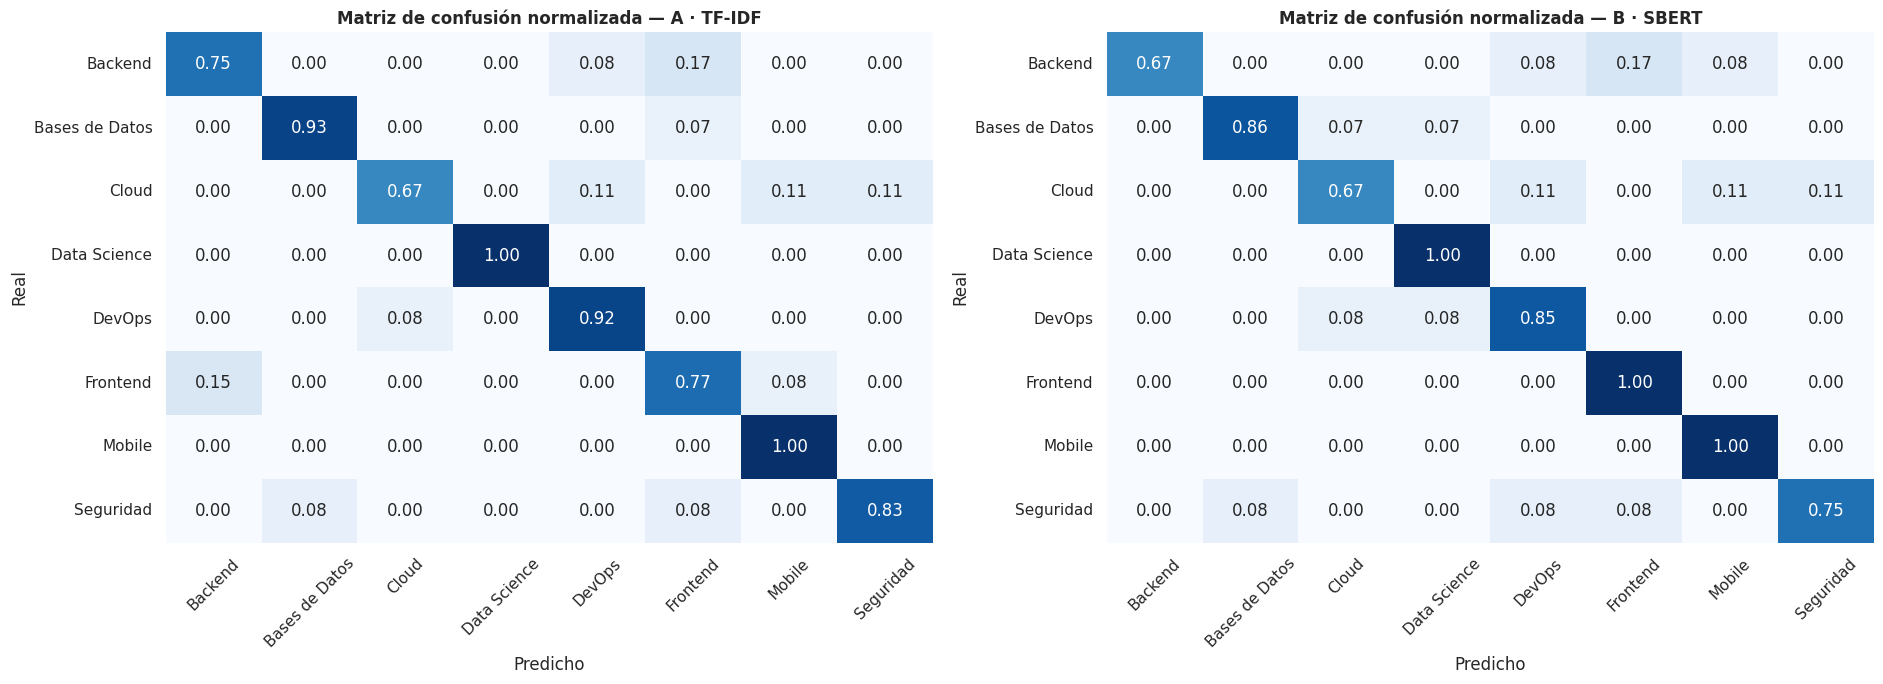

Pares más confundidos (real → predicho):
  Backend            → Frontend           16.7%
  Frontend           → Backend            15.4%
  Cloud              → DevOps             11.1%
  Cloud              → Mobile             11.1%
  Cloud              → Seguridad          11.1%


In [ ]:
# @title 5.4.2 — Classification report y matrices de confusión
pred_ganador = pred_b if GANADOR == "B" else pred_a

print(f"CLASSIFICATION REPORT — {NOMBRE_GANADOR}\n")
print(classification_report(y_test, pred_ganador, target_names=CATEGORIAS,
                            digits=3, zero_division=0))

reporte_dict = classification_report(y_test, pred_ganador, target_names=CATEGORIAS,
                                     output_dict=True, zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(19, 7))
for ax, pred, nombre in zip(axes, [pred_a, pred_b], ["A · TF-IDF", "B · SBERT"]):
    cm = confusion_matrix(y_test, pred, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False,
                xticklabels=CATEGORIAS, yticklabels=CATEGORIAS, vmin=0, vmax=1)
    ax.set_title(f"Matriz de confusión normalizada — {nombre}", fontweight="bold")
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.show()

# Lectura dirigida: los pares que más se confunden entre sí
cm_ganador = confusion_matrix(y_test, pred_ganador, normalize="true")
confusiones = [
    (CATEGORIAS[i], CATEGORIAS[j], cm_ganador[i, j])
    for i in range(len(CATEGORIAS)) for j in range(len(CATEGORIAS))
    if i != j and cm_ganador[i, j] > 0
]
confusiones.sort(key=lambda t: -t[2])
if confusiones:
    print("Pares más confundidos (real → predicho):")
    for real, predicho, tasa in confusiones[:5]:
        print(f"  {real:<18} → {predicho:<18} {tasa:.1%}")

06:26:53 │ INFO    │ ┌─ etapa · validación cruzada
06:26:53 │ INFO    │ ▶ inicio · validación cruzada
06:26:55 │ INFO    │ ✔ fin    · validación cruzada en 2.51s
06:26:55 │ INFO    │ └─ etapa · validación cruzada completada en 2.52s
f1_macro en validación cruzada (5-fold estratificado):

  A · TF-IDF + LogReg : 0.8532 ± 0.0488   [0.894 0.808 0.927 0.806 0.831]
  B · SBERT  + LogReg : 0.8411 ± 0.0204   [0.844 0.834 0.865 0.857 0.807]


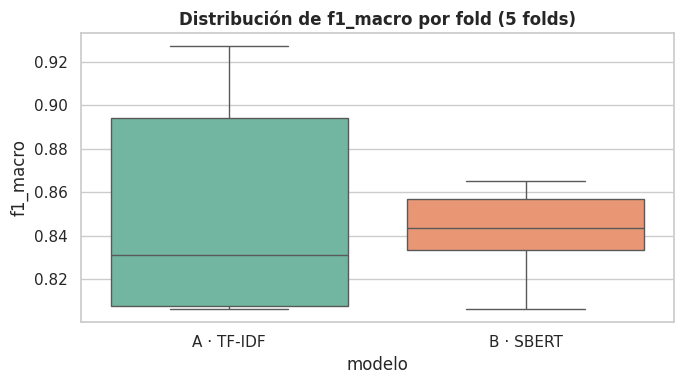

In [ ]:
# @title 5.4.3 — Validación cruzada estratificada
@cronometrar("validación cruzada")
def validar_cruzado(cfg: Config = CFG) -> dict:
    """Ejecuta validación cruzada estratificada, adaptando los folds al corpus.

    `StratifiedKFold` exige al menos un documento por clase en cada fold: con
    `n_splits=5` y una categoría de 3 documentos, falla. En vez de abortar,
    reducimos los folds al máximo viable y lo registramos — un 3-fold sobre un
    corpus pequeño sigue siendo más informativo que un único split.

    Args:
        cfg: Configuración con el número de folds y la métrica de decisión.

    Returns:
        Diccionario con las claves "A", "B" (arrays de puntajes por fold) y
        "n_folds" (los efectivamente usados).
    """
    n_folds = min(cfg.clasificacion.cv_folds, MIN_POR_CLASE)
    if n_folds < cfg.clasificacion.cv_folds:
        log.warning(f"Validación cruzada reducida a {n_folds} folds: la categoría menos "
                    f"poblada tiene {MIN_POR_CLASE} documento(s).")
    if n_folds < 2:
        log.error("Imposible validar de forma cruzada: alguna categoría tiene un solo "
                  "documento. Se omite §5.4.3.")
        return {"A": np.array([]), "B": np.array([]), "n_folds": 0}

    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=cfg.random_state)
    puntajes_a = cross_val_score(modelo_a, textos_pos, y, cv=cv,
                                 scoring=cfg.clasificacion.metrica_decision)
    puntajes_b = cross_val_score(
        LogisticRegression(max_iter=cfg.clasificacion.max_iter, C=cfg.clasificacion.C,
                           class_weight=cfg.clasificacion.class_weight,
                           random_state=cfg.random_state),
        embeddings, y, cv=cv, scoring=cfg.clasificacion.metrica_decision)
    return {"A": puntajes_a, "B": puntajes_b, "n_folds": n_folds}


with etapa("validación cruzada"):
    CV = validar_cruzado()

N_FOLDS = CV["n_folds"]
if N_FOLDS == 0:
    print("Validación cruzada omitida: el corpus no tiene documentos suficientes por categoría.")
    print("Corrige la ingesta (§2.4.3) antes de interpretar las métricas de §5.4.1.")

print(f"{CFG.clasificacion.metrica_decision} en validación cruzada "
      f"({N_FOLDS}-fold estratificado):\n")
if N_FOLDS >= 2:
    for clave, nombre in [("A", "A · TF-IDF + LogReg"), ("B", "B · SBERT  + LogReg")]:
        p = CV[clave]
        print(f"  {nombre} : {p.mean():.4f} ± {p.std():.4f}   {np.round(p, 3)}")

    estabilidad = float(CV[GANADOR].std())
    if estabilidad > 0.10:
        log.warning(f"Desviación entre folds alta ({estabilidad:.3f}): "
                    f"el resultado no es estable con este tamaño de corpus.")
        print(f"\n  AVISO: desviación de {estabilidad:.3f} entre folds. La media de arriba "
              f"no debe presentarse como un valor puntual.")

    plt.figure(figsize=(7, 4))
    _cv_largo = pd.DataFrame({"A · TF-IDF": CV["A"], "B · SBERT": CV["B"]}).melt(
        var_name="modelo", value_name=CFG.clasificacion.metrica_decision)
    sns.boxplot(data=_cv_largo, x="modelo", y=CFG.clasificacion.metrica_decision,
                hue="modelo", palette="Set2", legend=False)
    plt.title(f"Distribución de {CFG.clasificacion.metrica_decision} por fold "
              f"({N_FOLDS} folds)", fontweight="bold")
    plt.ylabel(CFG.clasificacion.metrica_decision)
    plt.tight_layout(); plt.show()

## 5.5 Explicabilidad

**El problema que resuelve.** El endpoint devuelve `{"categoria": "Backend", "probabilidad": 0.89}`.
Un usuario razonable pregunta: *¿por qué Backend?* Sin respuesta, el sistema es un oráculo: se acepta
o se rechaza, pero no se audita. Y un modelo que no se puede auditar no se puede depurar — cuando
clasifique mal de forma sistemática, no habrá manera de saber si el problema es el corpus, las
etiquetas o la representación.

Implementamos dos niveles, que responden preguntas distintas.

### Nivel global — ¿qué ha aprendido el modelo?

Los coeficientes de la regresión logística sobre TF-IDF son directamente legibles: cada uno mide
cuánto empuja un término hacia una categoría. Es un diagnóstico del **modelo en su conjunto**, no de
una predicción concreta, y sirve sobre todo para detectar aprendizaje espurio: si el término con
mayor peso para "DevOps" resultara ser un artefacto del scraping y no un concepto de DevOps, el
problema está en el corpus.

Solo aplica al modelo A. Los coeficientes del modelo B operan sobre 384 dimensiones latentes sin
significado individual: leerlos no informa nada.

### Nivel local — ¿por qué *este* documento?

Aquí usamos **ablación por término**, que es agnóstica al modelo y por tanto funciona igual sea cual
sea el ganador:

1. Se predice la categoría del documento completo → probabilidad `p₀`.
2. Para cada término candidato (keywords y entidades), se elimina del texto y se vuelve a predecir la
   probabilidad de *la misma categoría* → `pᵢ`.
3. La contribución del término es `p₀ − pᵢ`. Positiva significa que sostiene la decisión; negativa,
   que la contradice y el modelo decidió a pesar de él.

Es una aproximación local a un valor de Shapley con un solo orden de eliminación. No es SHAP —que
promedia sobre todas las coaliciones posibles y sería computacionalmente inviable en el camino
crítico de la API—, pero captura la intuición central y cuesta `n+1` predicciones en lugar de `2ⁿ`.

El resultado se separa en **términos a favor** (su eliminación baja la probabilidad: sostienen la
decisión) y **términos en contra** (su eliminación la sube: el modelo decidió *a pesar* de ellos).
Esa segunda lista es la más informativa de las dos para depurar — un término técnico que rema en
contra de la categoría correcta suele señalar que el corpus de esa categoría es pobre en ese
concepto.

**Y una segunda señal, gratuita:** la similitud coseno del documento contra el **centroide de cada
categoría** en el espacio de embeddings. Responde "¿a qué se parece este documento?" con independencia
de lo que el clasificador haya decidido, y cuando ambas señales discrepan, esa discrepancia es en sí
misma un diagnóstico útil.

### Nota sobre el enfoque alternativo: modelo sustituto (*surrogate*)

Existe una alternativa más barata: explicar siempre con el modelo TF-IDF, descomponiendo la
predicción en `peso_tfidf × coeficiente_de_clase` por término. Es una práctica estándar y su
justificación es sólida — las 384 dimensiones de SBERT no tienen significado léxico individual, así
que no se pueden leer.

No la adoptamos como método principal por una razón concreta: **si el modelo en producción es el B
(SBERT), un sustituto TF-IDF explica un modelo distinto del que tomó la decisión**. Las explicaciones
serían plausibles y a veces sencillamente falsas, que es el peor resultado posible en explicabilidad.
La ablación evita el problema porque interroga al modelo real, sea cual sea, a cambio de `n+1`
predicciones en vez de una multiplicación de vectores.

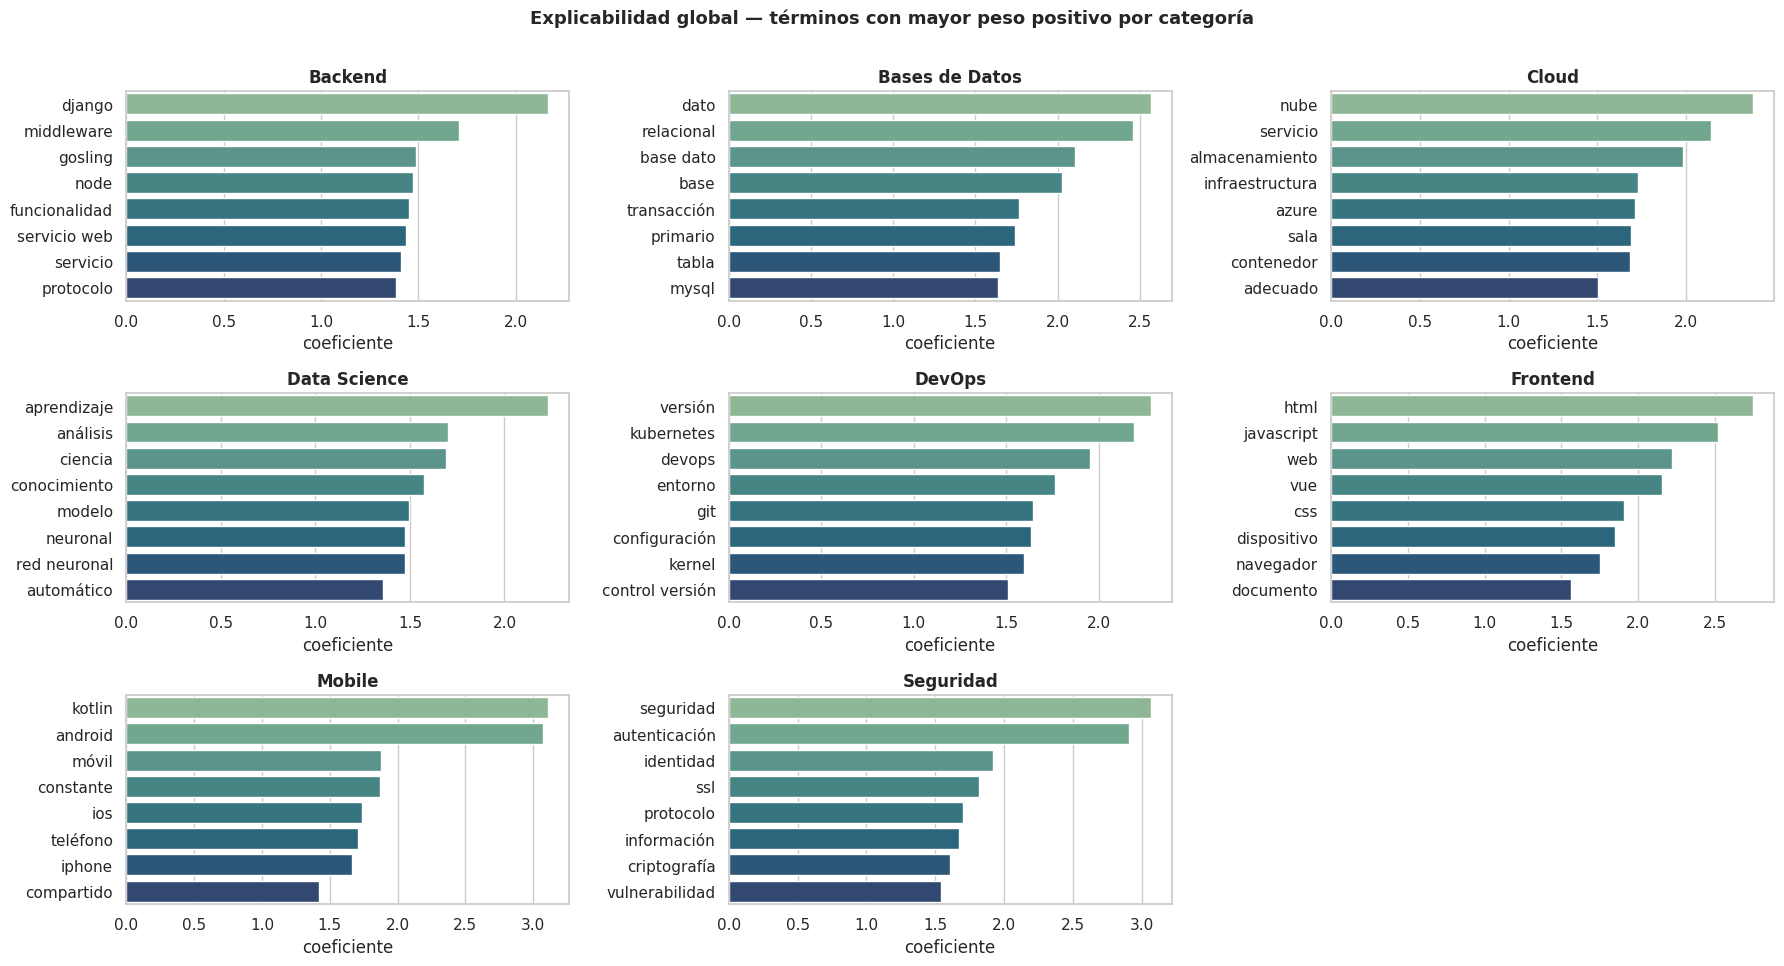

In [ ]:
# @title 5.5.1 — Explicabilidad global: qué términos usa el modelo TF-IDF
vect_a = modelo_a.named_steps["tfidf"]
clf_a = modelo_a.named_steps["clf"]
vocab_a = np.array(vect_a.get_feature_names_out())

n_cols = 3
n_filas = int(np.ceil(len(CATEGORIAS) / n_cols))
fig, axes = plt.subplots(n_filas, n_cols, figsize=(6 * n_cols, 3.2 * n_filas))
ejes = np.array(axes).ravel()

for ax, (i, cat) in zip(ejes, enumerate(CATEGORIAS)):
    coef = clf_a.coef_[i]
    top = coef.argsort()[::-1][:CFG.clasificacion.n_terminos_explicabilidad]
    sns.barplot(x=coef[top], y=vocab_a[top], ax=ax,
                hue=vocab_a[top], palette="crest", legend=False)
    ax.set_title(cat, fontweight="bold"); ax.set_xlabel("coeficiente")
for ax in ejes[len(CATEGORIAS):]:
    ax.axis("off")

plt.suptitle("Explicabilidad global — términos con mayor peso positivo por categoría",
             y=1.005, fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

In [ ]:
# @title 5.5.2 — Explicabilidad local: ablación por término y centroides de clase
CENTROIDES = np.vstack([
    embeddings[y == i].mean(axis=0) / np.linalg.norm(embeddings[y == i].mean(axis=0))
    for i in range(len(CATEGORIAS))
])


def _predecir_probabilidades(texto_limpio: str, texto_pos: str) -> np.ndarray:
    """Devuelve la distribución de probabilidad sobre categorías del modelo ganador."""
    if GANADOR == "B":
        vector = CACHE.codificar([texto_limpio], modelo_embeddings)
        return modelo_b.predict_proba(vector)[0]
    return modelo_a.predict_proba([texto_pos])[0]


def explicar_prediccion(texto_limpio: str,
                        texto_pos: str,
                        candidatos: Sequence,
                        max_terminos: int = 6,
                        *,
                        predictor: Callable = None,
                        centroides: np.ndarray = None,
                        categorias: Sequence = None,
                        codificador: Callable = None) -> dict:
    """Explica una predicción por ablación de términos y similitud a centroides.

    Para cada término candidato, elimina sus ocurrencias del texto, recalcula la
    probabilidad de la categoría originalmente predicha y reporta la diferencia.
    Una diferencia positiva significa que el término sostenía la decisión; una
    negativa, que el modelo decidió a pesar de él.

    Los parámetros de sólo-palabra clave permiten inyectar las dependencias en vez
    de leerlas del ámbito global, para que la capa de inferencia (§7.2) sea
    autocontenida al importarse desde el backend.

    Args:
        texto_limpio: Texto normalizado, entrada del modelo semántico.
        texto_pos: Lemas filtrados por POS, entrada del modelo léxico.
        candidatos: Términos a evaluar (típicamente las keywords y entidades).
        max_terminos: Tope de términos a ablacionar, para acotar el costo.
        predictor: Callable (texto_limpio, texto_pos) -> distribución de probabilidad.
        centroides: Matriz (n_categorias, dim) de centroides normalizados.
        categorias: Nombres de las categorías, alineados con `centroides`.
        codificador: Callable (list[str]) -> matriz de embeddings.

    Returns:
        Diccionario con `categoria`, `probabilidad`, `metodo`, `terminos_a_favor`,
        `terminos_en_contra` y `similitud_centroides`.

    Example:
        >>> exp = explicar_prediccion(texto, texto_pos, ["Java", "Spring Boot"])
        >>> exp["terminos_a_favor"][0]["termino"]
        'Spring Boot'
    """
    predictor = predictor or _predecir_probabilidades
    centroides = centroides if centroides is not None else CENTROIDES
    categorias = list(categorias) if categorias is not None else CATEGORIAS
    codificador = codificador or (lambda ts: CACHE.codificar(ts, modelo_embeddings))

    probas = predictor(texto_limpio, texto_pos)
    idx_pred = int(np.argmax(probas))
    p0 = float(probas[idx_pred])

    contribuciones = []
    for termino in list(candidatos)[:max_terminos]:
        patron = re.compile(re.escape(str(termino)), re.IGNORECASE)
        limpio_sin = patron.sub(" ", texto_limpio)
        pos_sin = patron.sub(" ", texto_pos)
        if limpio_sin.strip() == texto_limpio.strip():
            continue   # el término no aparecía literalmente; ablacionarlo no informa
        p_sin = float(predictor(limpio_sin, pos_sin)[idx_pred])
        contribuciones.append({"termino": str(termino),
                               "contribucion": round(p0 - p_sin, 4)})

    contribuciones.sort(key=lambda d: -d["contribucion"])

    vector = codificador([texto_limpio])[0]
    similitudes = centroides @ vector
    ranking = np.argsort(similitudes)[::-1][:3]

    return {
        "categoria": categorias[idx_pred],
        "probabilidad": round(p0, 4),
        "metodo": "ablación de términos sobre el modelo en producción + centroides de clase",
        "terminos_a_favor": [c for c in contribuciones if c["contribucion"] > 0],
        "terminos_en_contra": [c for c in contribuciones if c["contribucion"] < 0][::-1],
        "similitud_centroides": [
            {"categoria": categorias[i], "similitud": round(float(similitudes[i]), 4)}
            for i in ranking
        ],
    }


# --- Demostración sobre el ejemplo del brief ------------------------------
_texto_ej = limpiar_texto(EJEMPLO)
_doc_ej = nlp(_texto_ej)
_proc_ej = preprocesar(_doc_ej)
_kws_ej = rankear_keywords(_texto_ej, doc_spacy=_doc_ej)

explicacion = explicar_prediccion(_texto_ej, _proc_ej["texto_pos"], _kws_ej)

print(f"DOCUMENTO : {EJEMPLO[:88]}...")
print(f"PREDICCIÓN: {explicacion['categoria']} (probabilidad {explicacion['probabilidad']})")
print(f"MÉTODO    : {explicacion['metodo']}\n")

print("Términos que SOSTIENEN la categoría (la probabilidad cae al eliminarlos):")
for c in explicacion["terminos_a_favor"]:
    print(f"  +{c['contribucion']:.4f}  {c['termino']:<24} "
          f"{'█' * max(1, int(c['contribucion'] * 120))}")
if not explicacion["terminos_a_favor"]:
    print("  (ninguno: la decisión no depende de un término aislado)")

if explicacion["terminos_en_contra"]:
    print("\nTérminos que RESTAN a la categoría (la probabilidad sube al eliminarlos):")
    for c in explicacion["terminos_en_contra"]:
        print(f"  {c['contribucion']:.4f}  {c['termino']:<24} "
              f"{'▒' * max(1, int(abs(c['contribucion']) * 120))}")
    print("  → El modelo eligió esta categoría A PESAR de estos términos. Si alguno es")
    print("    técnicamente central al tema, indica corpus pobre en ese concepto.")

print("\nSimilitud contra los centroides de cada categoría:")
for s in explicacion["similitud_centroides"]:
    print(f"  {s['categoria']:<22} {s['similitud']:.4f}")
if explicacion["similitud_centroides"][0]["categoria"] != explicacion["categoria"]:
    print("\n  AVISO: el centroide más cercano NO coincide con la categoría predicha.")
    print("  Las dos señales discrepan — documento probablemente ambiguo o fronterizo.")

06:26:57 │ INFO    │ Embeddings: 1 por calcular, 0 desde caché
DOCUMENTO : En este contenido se presentan los conceptos básicos para la creación de APIs REST utili...
PREDICCIÓN: Backend (probabilidad 0.3806)
MÉTODO    : ablación de términos sobre el modelo en producción + centroides de clase

Términos que SOSTIENEN la categoría (la probabilidad cae al eliminarlos):
  +0.1310  REST                     ███████████████
  +0.0856  Java                     ██████████

Similitud contra los centroides de cada categoría:
  Backend                0.5939
  DevOps                 0.4633
  Frontend               0.4528


## 5.6 Agrupamiento y descubrimiento de tópicos

Última caja de la etapa 3. El diagrama del brief sugiere *"Ej. LDA o K-Means"*;
`Technology_Architecture.md` §8 adopta **BERTopic** como método de producción y recomienda mantener
**KMeans como comparación metodológica**. Hacemos exactamente eso, y la comparación no es decorativa:
mostrar el codo y la silueta de KMeans documenta *por qué* fijar `k` a mano es un problema real y no
una objeción teórica.

El clustering es **no supervisado**: descubre estructura temática que puede no coincidir con las
categorías etiquetadas, y ese desacuerdo es su valor. Organiza el conocimiento por temas emergentes,
no por la taxonomía que impusimos al recolectar. Lo cuantificamos con ARI y NMI: cerca de 0 significa
que el clustering encontró una organización independiente de nuestras etiquetas; cerca de 1, que
reconstruyó la taxonomía por sí solo.

06:26:57 │ INFO    │ ┌─ etapa · clustering KMeans
06:26:59 │ INFO    │ └─ etapa · clustering KMeans completada en 2.11s


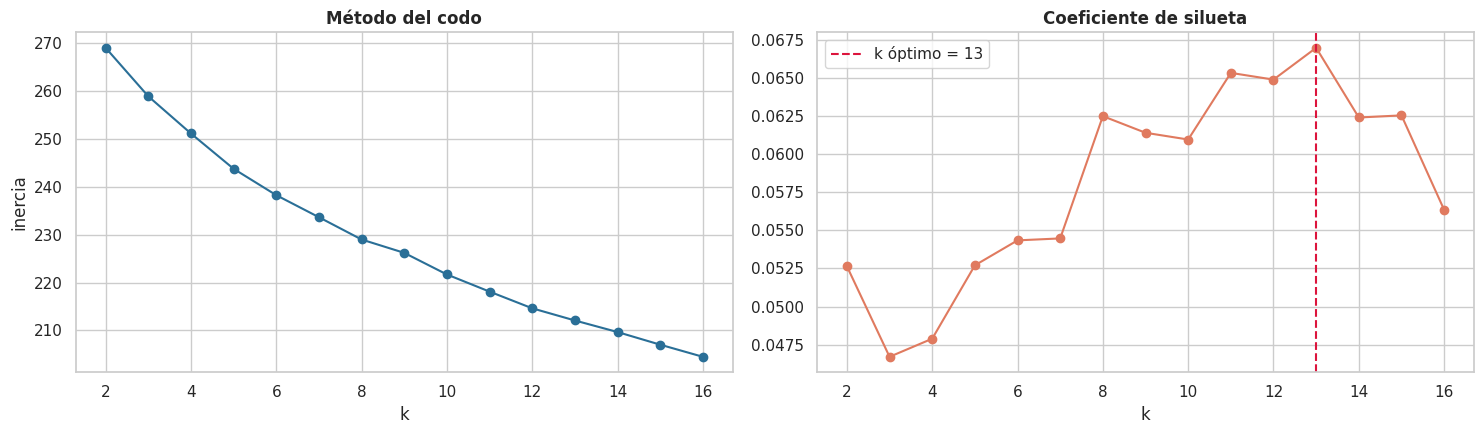

Obsérvese que el codo no es nítido: es exactamente la ambigüedad que BERTopic evita.
06:27:00 │ INFO    │ KMeans: k=13, silueta=0.0670
KMeans con k=13 | silueta máxima = 0.0670


In [ ]:
# @title 5.6.1 — KMeans: selección de k por codo y coeficiente de silueta
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

with etapa("clustering KMeans"):
    # El barrido de k debe caber en el corpus: KMeans exige k <= n_documentos, y
    # el coeficiente de silueta necesita al menos 2 grupos. Con un corpus pequeño
    # el rango original quedaba vacío y `np.argmax([])` fallaba.
    k_tope = min(CFG.clustering.k_max, max(2, len(df) // 5), len(df) - 1)
    rango_k = list(range(CFG.clustering.k_min, k_tope + 1))

    if len(rango_k) < 1:
        log.warning(f"Corpus de {len(df)} documentos: insuficiente para barrer k. "
                    f"Se usa k=2 sin selección.")
        rango_k = [2]

    inercias, siluetas = [], []
    for k in rango_k:
        km = KMeans(n_clusters=k, random_state=CFG.random_state,
                    n_init=CFG.clustering.kmeans_n_init).fit(embeddings)
        inercias.append(km.inertia_)
        siluetas.append(silhouette_score(embeddings, km.labels_)
                        if k < len(df) else float("nan"))

    K_OPTIMO = rango_k[int(np.nanargmax(siluetas))] if len(rango_k) > 1 else rango_k[0]
    kmeans = KMeans(n_clusters=K_OPTIMO, random_state=CFG.random_state,
                    n_init=CFG.clustering.kmeans_n_init).fit(embeddings)
    df["cluster_kmeans"] = kmeans.labels_

if len(rango_k) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    axes[0].plot(rango_k, inercias, "o-", color="#2a6f97")
    axes[0].set_title("Método del codo", fontweight="bold")
    axes[0].set_xlabel("k"); axes[0].set_ylabel("inercia")
    axes[1].plot(rango_k, siluetas, "o-", color="#e07a5f")
    axes[1].axvline(K_OPTIMO, ls="--", color="crimson", label=f"k óptimo = {K_OPTIMO}")
    axes[1].set_title("Coeficiente de silueta", fontweight="bold")
    axes[1].set_xlabel("k"); axes[1].legend()
    plt.tight_layout(); plt.show()
    print("Obsérvese que el codo no es nítido: es exactamente la ambigüedad que BERTopic evita.")
else:
    print(f"Barrido de k omitido: el corpus ({len(df)} documentos) no admite explorar "
          f"un rango de valores.")

log.info(f"KMeans: k={K_OPTIMO}, silueta={np.nanmax(siluetas):.4f}")
print(f"KMeans con k={K_OPTIMO} | silueta máxima = {np.nanmax(siluetas):.4f}")

In [ ]:
# @title 5.6.2 — BERTopic: descubrimiento automático de tópicos
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer


@cronometrar("clustering BERTopic")
def entrenar_bertopic(textos: list, vectores: np.ndarray, cfg: Config = CFG) -> tuple:
    """Ajusta BERTopic sobre embeddings ya calculados.

    `min_topic_size` se escala con el tamaño del corpus: con el valor por defecto,
    HDBSCAN marcaría como ruido una fracción excesiva de un corpus pequeño
    (Technology_Architecture.md §8).

    Args:
        textos: Lista de documentos limpios.
        vectores: Matriz de embeddings correspondiente, para no recalcularla.
        cfg: Configuración de clustering.

    Returns:
        Tupla (modelo entrenado, lista de tópicos por documento, matriz de probabilidades).
    """
    vectorizador = CountVectorizer(
        stop_words=_STOPWORDS_SPACY,
        ngram_range=(1, cfg.clustering.bertopic_ngram_max),
        min_df=cfg.clustering.bertopic_min_df,
    )
    modelo = BERTopic(
        embedding_model=modelo_embeddings,
        vectorizer_model=vectorizador,
        ctfidf_model=ClassTfidfTransformer(reduce_frequent_words=True),
        min_topic_size=max(cfg.clustering.bertopic_min_topic_size_piso,
                           len(textos) // cfg.clustering.bertopic_min_topic_size_divisor),
        calculate_probabilities=True,
        verbose=False,
        language="multilingual",
    )
    topicos, probabilidades = modelo.fit_transform(textos, vectores)
    return modelo, topicos, probabilidades


with etapa("descubrimiento de tópicos"):
    topic_model, topicos, probs_topicos = entrenar_bertopic(
        df["texto_limpio"].tolist(), embeddings)
    df["topico_bertopic"] = topicos

info_topicos = topic_model.get_topic_info()
n_outliers = int((df["topico_bertopic"] == -1).sum())

log.info(f"BERTopic: {len(info_topicos) - 1} tópicos, {n_outliers} outliers "
         f"({n_outliers / len(df):.1%})")
if n_outliers / len(df) > 0.35:
    log.warning("Más del 35% del corpus quedó como outlier: considera KMeans como respaldo.")

print(f"Tópicos descubiertos: {len(info_topicos) - 1} (excluyendo el tópico de ruido)")
print(f"Outliers (tópico -1) : {n_outliers} ({n_outliers / len(df):.1%} del corpus)\n")
display(info_topicos.head(12)[["Topic", "Count", "Name"]])

06:27:00 │ INFO    │ ┌─ etapa · descubrimiento de tópicos
06:27:00 │ INFO    │ ▶ inicio · clustering BERTopic
06:27:13 │ INFO    │ ✔ fin    · clustering BERTopic en 13.65s
06:27:13 │ INFO    │ └─ etapa · descubrimiento de tópicos completada en 13.65s
06:27:13 │ INFO    │ BERTopic: 7 tópicos, 43 outliers (11.6%)
Tópicos descubiertos: 7 (excluyendo el tópico de ruido)
Outliers (tópico -1) : 43 (11.6% del corpus)



,Topic,Count,Name
0,-1,43,-1_devops_kubernetes_entrega_oauth
1,0,89,0_software_servicios_servicio_infraestructura
2,1,79,1_web_javascript_java_página
3,2,52,2_análisis_función_ciencia_modelos
4,3,36,3_sql_bases datos_bases_relacional
5,4,35,4_seguridad_autenticación_cortafuegos_protección
6,5,22,5_android_móviles_dispositivos_ios
7,6,14,6_tabla_clave_atributo_elemento


In [ ]:
# @title 5.6.3 — Etiquetas legibles por tópico (c-TF-IDF) y contraste con las categorías
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ETIQUETAS_TOPICO = {
    t: ", ".join(w for w, _ in topic_model.get_topic(t)[:4])
    for t in sorted(set(topicos)) if t != -1
}
ETIQUETAS_TOPICO[-1] = "(sin tema definido / outlier)"

print("PALABRAS REPRESENTATIVAS POR TÓPICO (generadas automáticamente vía c-TF-IDF)\n")
for t in sorted(set(topicos)):
    if t == -1:
        continue
    palabras = ", ".join(w for w, _ in
                         topic_model.get_topic(t)[:CFG.clustering.n_palabras_por_topico])
    sub = df[df["topico_bertopic"] == t]
    modo = sub["categoria"].mode()
    cat_dominante = modo.iloc[0] if len(modo) else "—"
    pureza = (sub["categoria"] == cat_dominante).mean() if len(sub) else 0
    print(f"Tópico {t:>2} ({len(sub):>3} docs) │ {palabras}")
    print(f"{'':>17}└─ categoría dominante: {cat_dominante} (pureza {pureza:.0%})\n")

mask = df["topico_bertopic"] != -1
ari_bt = adjusted_rand_score(df.loc[mask, "categoria"], df.loc[mask, "topico_bertopic"])
nmi_bt = normalized_mutual_info_score(df.loc[mask, "categoria"], df.loc[mask, "topico_bertopic"])
ari_km = adjusted_rand_score(df["categoria"], df["cluster_kmeans"])
nmi_km = normalized_mutual_info_score(df["categoria"], df["cluster_kmeans"])

print("Concordancia entre el clustering no supervisado y las etiquetas de la taxonomía:")
print(f"  BERTopic  ARI = {ari_bt:.4f} | NMI = {nmi_bt:.4f}")
print(f"  KMeans    ARI = {ari_km:.4f} | NMI = {nmi_km:.4f}")
print("\nARI/NMI cercanos a 0 = agrupación independiente de la taxonomía impuesta;")
print("cercanos a 1 = el clustering reconstruye por sí solo las categorías etiquetadas.")

PALABRAS REPRESENTATIVAS POR TÓPICO (generadas automáticamente vía c-TF-IDF)

Tópico  0 ( 89 docs) │ software, servicios, servicio, infraestructura, sistema, almacenamiento, linux
                 └─ categoría dominante: DevOps (pureza 42%)

Tópico  1 ( 79 docs) │ web, javascript, java, página, navegador, lenguaje, páginas web
                 └─ categoría dominante: Frontend (pureza 58%)

Tópico  2 ( 52 docs) │ análisis, función, ciencia, modelos, estadística, frecuencia, datos
                 └─ categoría dominante: Data Science (pureza 98%)

Tópico  3 ( 36 docs) │ sql, bases datos, bases, relacional, datos, base datos, base
                 └─ categoría dominante: Bases de Datos (pureza 78%)

Tópico  4 ( 35 docs) │ seguridad, autenticación, cortafuegos, protección, riesgo, autorización, información
                 └─ categoría dominante: Seguridad (pureza 80%)

Tópico  5 ( 22 docs) │ android, móviles, dispositivos, ios, dispositivos móviles, apple, móvil
                 └─ catego

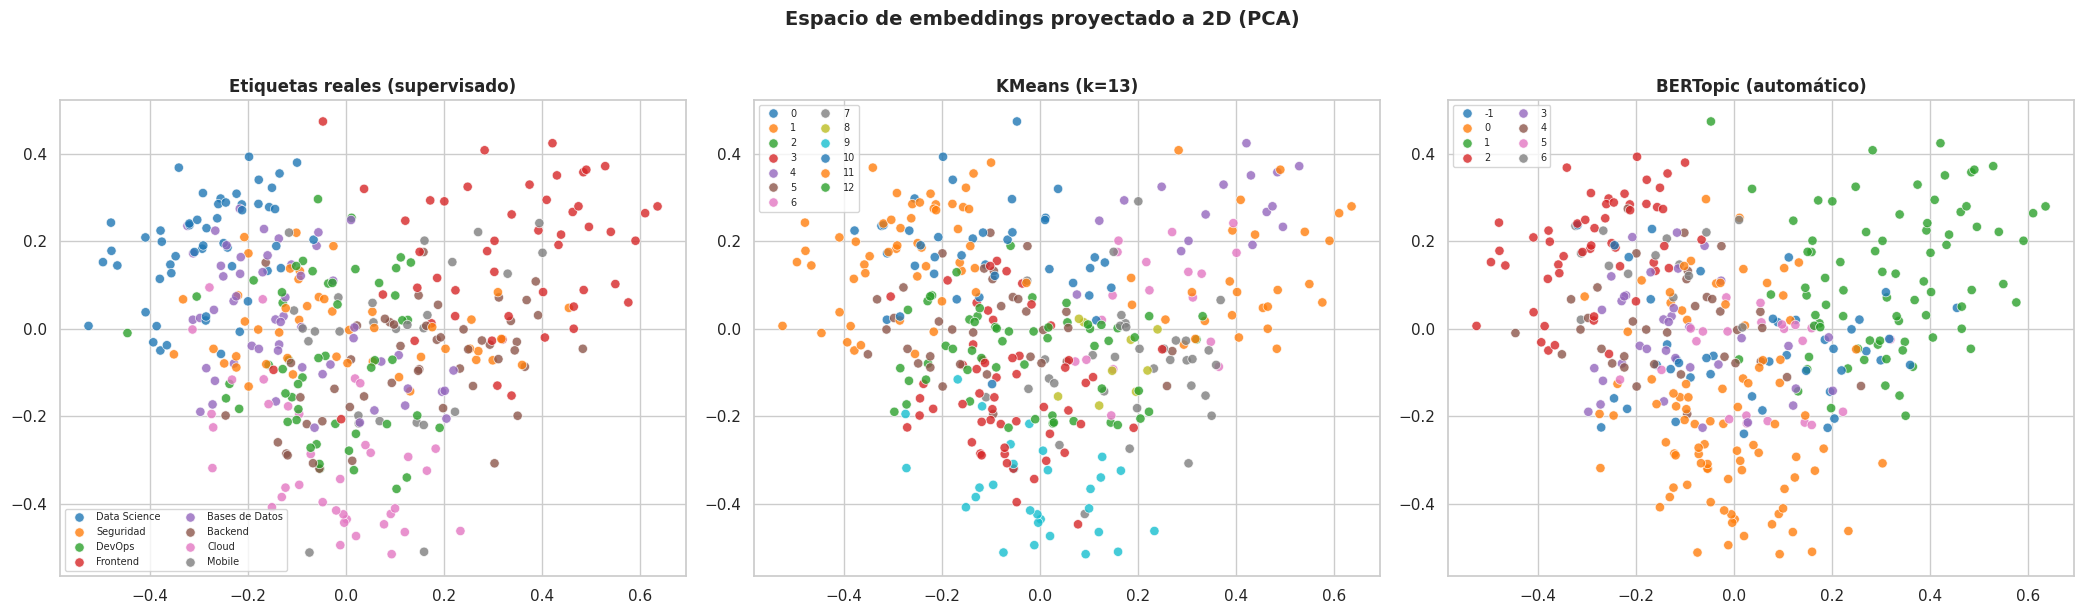

Varianza explicada por las 2 componentes: 12.5% de 384 dimensiones originales.
Una fracción baja es esperable: la proyección es orientativa, no una medida de separabilidad.


In [ ]:
# @title 5.6.4 — Visualización del espacio semántico (proyección 2D)
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=CFG.random_state).fit_transform(embeddings)
df["x"], df["y"] = coords[:, 0], coords[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, col, titulo in zip(
    axes,
    ["categoria", "cluster_kmeans", "topico_bertopic"],
    ["Etiquetas reales (supervisado)", f"KMeans (k={K_OPTIMO})", "BERTopic (automático)"],
):
    sns.scatterplot(data=df, x="x", y="y", hue=col, palette="tab10", s=45,
                    alpha=0.8, ax=ax, legend="brief")
    ax.set_title(titulo, fontweight="bold"); ax.set_xlabel(""); ax.set_ylabel("")
    ax.legend(fontsize=7, loc="best", ncol=2)

plt.suptitle("Espacio de embeddings proyectado a 2D (PCA)", y=1.02, fontsize=14,
             fontweight="bold")
plt.tight_layout(); plt.show()

varianza = PCA(n_components=2, random_state=CFG.random_state).fit(embeddings)
print(f"Varianza explicada por las 2 componentes: "
      f"{varianza.explained_variance_ratio_.sum():.1%} de 384 dimensiones originales.")
print("Una fracción baja es esperable: la proyección es orientativa, no una medida de separabilidad.")

## 5.7 Serialización y versionado de modelos

Requisito explícito del brief. Pero guardar el `.joblib` es la parte fácil; la difícil es que dentro
de tres semanas alguien pueda responder **qué es exactamente ese archivo**.

Un artefacto sin metadatos es un binario opaco: no se sabe con qué datos se entrenó, con qué
hiperparámetros, qué desempeño tuvo ni si el código que intenta cargarlo es compatible. Por eso cada
corrida produce un `metadata.json` con seis bloques, que es el **contrato entre Ciencia de Datos y
Backend**:

| Bloque | Contenido | Para qué sirve |
|---|---|---|
| **Versión** | Versión semántica del pipeline + huella de configuración | El backend puede rechazar un artefacto de versión incompatible |
| **Fecha** | Timestamp ISO 8601 del entrenamiento | Trazabilidad y detección de modelos obsoletos |
| **Parámetros** | Hiperparámetros del clasificador + configuración completa | Reproducir el entrenamiento exactamente |
| **Métricas** | Todas las de §5.4 más la CV | Comparar contra la siguiente versión sin reejecutar |
| **Modelo** | Qué representación ganó, qué embeddings, qué spaCy | El backend carga el modelo correcto sin adivinar |
| **Dataset** | Nombre, tamaño, categorías, **hash SHA-256 del corpus** | Detectar si el corpus cambió desde el entrenamiento |

**El hash del dataset merece énfasis.** Es la única forma de responder con certeza *"¿este modelo se
entrenó con estos datos?"*. Sin él, un corpus modificado silenciosamente entre corridas produce un
modelo cuyo desempeño reportado ya no corresponde a nada verificable.

**Qué no se serializa con joblib, y por qué.** Los modelos de Sentence-Transformers y de spaCy se
cargan por nombre desde su propio caché (`SentenceTransformer(nombre)`), no se empaquetan:
serializarlos duplicaría cientos de megabytes sin beneficio alguno, y el nombre queda registrado en
`metadata.json` para que el backend cargue exactamente el mismo.

In [ ]:
# @title 5.7 — Guardado de artefactos con versionado completo
def hash_dataset(df: pd.DataFrame, columnas: Sequence = ("doc_id", "texto_limpio", "categoria")) -> str:
    """Calcula un hash reproducible del contenido del corpus.

    Args:
        df: DataFrame del corpus.
        columnas: Columnas que definen la identidad del dataset.

    Returns:
        Hash SHA-256 hexadecimal del contenido ordenado.
    """
    sub = df[list(columnas)].sort_values("doc_id")
    payload = sub.to_csv(index=False).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


@cronometrar("serialización de artefactos")
def serializar_artefactos(cfg: Config = CFG) -> dict:
    """Guarda todos los artefactos del pipeline con sus metadatos de versionado.

    Args:
        cfg: Configuración del pipeline.

    Returns:
        Diccionario {nombre_artefacto: descripción}.
    """
    artefactos: dict = {}
    destino = cfg.rutas.models

    # 1 — Clasificador ganador
    modelo_final = modelo_b if GANADOR == "B" else modelo_a
    tipo_clf = "sbert+logreg" if GANADOR == "B" else "tfidf+logreg"
    joblib.dump(modelo_final, destino / "modelo_clasificacion.joblib")
    artefactos["modelo_clasificacion.joblib"] = f"Clasificador temático ({tipo_clf})"

    # 2 — Codificador de etiquetas
    joblib.dump(le, destino / "label_encoder.joblib")
    artefactos["label_encoder.joblib"] = "Mapeo índice ↔ nombre de categoría"

    # 3 — Vectorizador TF-IDF del corpus (keywords estadísticas y modelo A)
    joblib.dump(tfidf, destino / "vectorizador_tfidf.joblib")
    artefactos["vectorizador_tfidf.joblib"] = "TfidfVectorizer ajustado al corpus"

    # 4 — KMeans (respaldo de clustering documentado)
    joblib.dump(kmeans, destino / "modelo_kmeans.joblib")
    artefactos["modelo_kmeans.joblib"] = f"KMeans k={K_OPTIMO} sobre embeddings"

    # 5 — Centroides de clase (explicabilidad local sin recalcular el corpus)
    joblib.dump({"centroides": CENTROIDES, "categorias": CATEGORIAS},
                destino / "centroides_clase.joblib")
    artefactos["centroides_clase.joblib"] = "Centroides por categoría (explicabilidad §5.5)"

    # 6 — BERTopic en formato nativo (safetensors, sin duplicar el modelo de embeddings)
    topic_model.save(str(destino / "modelo_bertopic"), serialization="safetensors",
                     save_ctfidf=True, save_embedding_model=cfg.embeddings.modelo)
    artefactos["modelo_bertopic/"] = "Modelo de tópicos + c-TF-IDF"

    # 7 — Configuración completa
    cfg.guardar(destino / "config.json")
    artefactos["config.json"] = "Configuración exacta usada en el entrenamiento"

    # 8 — Metadatos: el contrato Data Science ↔ Backend
    fila_ganadora = resumen.loc[NOMBRE_GANADOR]
    metadatos = {
        "version": cfg.version,
        "huella_configuracion": cfg.huella(),
        "fecha_entrenamiento": pd.Timestamp.now().isoformat(),

        "modelo": {
            "tipo_clasificador": tipo_clf,
            "representacion": "embeddings SBERT" if GANADOR == "B" else "TF-IDF sobre lemas POS",
            "modelo_embeddings": cfg.embeddings.modelo,
            "dimension_embeddings": int(embeddings.shape[1]),
            "modelo_spacy": cfg.idioma.modelos_spacy[cfg.idioma.idioma_objetivo],
            "idiomas_soportados": list(cfg.idioma.idiomas_soportados),
            "categorias": CATEGORIAS,
            "n_topicos_bertopic": int(len(info_topicos) - 1),
            "k_kmeans": int(K_OPTIMO),
        },

        "hiperparametros": HIPERPARAMETROS,

        "metricas": {
            "conjunto_prueba": {k: float(fila_ganadora[k]) for k in resumen.columns},
            "validacion_cruzada": {
                "metrica": cfg.clasificacion.metrica_decision,
                "folds_configurados": cfg.clasificacion.cv_folds,
                "folds_efectivos": N_FOLDS,
                "media": float(CV[GANADOR].mean()) if N_FOLDS >= 2 else None,
                "desviacion": float(CV[GANADOR].std()) if N_FOLDS >= 2 else None,
                "por_fold": [round(float(v), 4) for v in CV[GANADOR]],
            },
            "por_categoria": {
                cat: {m: round(float(v), 4) for m, v in vals.items()}
                for cat, vals in reporte_dict.items()
                if cat in CATEGORIAS
            },
            "clustering": {
                "ari_bertopic": round(float(ari_bt), 4),
                "nmi_bertopic": round(float(nmi_bt), 4),
                "ari_kmeans": round(float(ari_km), 4),
                "nmi_kmeans": round(float(nmi_km), 4),
                "silueta_kmeans": round(float(max(siluetas)), 4),
                "ratio_outliers": round(n_outliers / len(df), 4),
            },
        },

        "dataset": {
            "nombre": "TechMind corpus técnico ES",
            "fuente": FUENTE_CORPUS,
            "respaldo_automatico_activado": RESPALDO_ACTIVADO,
            "hash_sha256": hash_dataset(df),
            "n_documentos": int(len(df)),
            "n_documentos_train": int(len(idx_train)),
            "n_documentos_test": int(len(idx_test)),
            "n_categorias": len(CATEGORIAS),
            "distribucion_categorias": df["categoria"].value_counts().to_dict(),
            "idiomas": df["idioma"].value_counts().to_dict(),
            "n_caracteres_total": int(df["n_chars"].sum()),
            "documentos_rechazados": int(len(df_rechazados)),
            "reporte_deduplicacion": REPORTE_DEDUP,
        },

        "entorno": {"versiones": VERSIONES, "semillas": ESTADO_SEMILLAS},
    }

    ruta_meta = destino / "metadata.json"
    ruta_meta.write_text(json.dumps(metadatos, ensure_ascii=False, indent=2,
                                    default=str), encoding="utf-8")
    artefactos["metadata.json"] = "Contrato de versionado Data Science ↔ Backend"

    return artefactos, metadatos


with etapa("serialización"):
    ARTEFACTOS, METADATOS = serializar_artefactos()

print(f"ARTEFACTOS SERIALIZADOS EN {CFG.rutas.models}\n")
for nombre, descripcion in ARTEFACTOS.items():
    ruta = CFG.rutas.models / nombre
    tam = (sum(f.stat().st_size for f in ruta.rglob("*") if f.is_file())
           if ruta.is_dir() else ruta.stat().st_size)
    print(f"  {nombre:<32} {tam / 1024:>9,.1f} KB   {descripcion}")

print(f"\nVERSIONADO DEL MODELO")
print("-" * 62)
print(f"  versión              : {METADATOS['version']}")
print(f"  fecha entrenamiento  : {METADATOS['fecha_entrenamiento'][:19]}")
print(f"  modelo               : {METADATOS['modelo']['tipo_clasificador']}")
print(f"  f1_macro (test)      : {METADATOS['metricas']['conjunto_prueba']['f1_macro']:.4f}")
_cv_meta = METADATOS["metricas"]["validacion_cruzada"]
if _cv_meta["media"] is not None:
    print(f"  f1_macro (CV)        : {_cv_meta['media']:.4f} ± {_cv_meta['desviacion']:.4f} "
          f"({_cv_meta['folds_efectivos']} folds)")
else:
    print(f"  f1_macro (CV)        : no disponible (corpus insuficiente)")
print(f"  dataset (hash)       : {METADATOS['dataset']['hash_sha256'][:24]}...")
print(f"  documentos           : {METADATOS['dataset']['n_documentos']}")
print(f"  huella configuración : {METADATOS['huella_configuracion'][:24]}...")

06:27:14 │ INFO    │ ┌─ etapa · serialización
06:27:14 │ INFO    │ ▶ inicio · serialización de artefactos
06:27:15 │ INFO    │ ✔ fin    · serialización de artefactos en 0.13s
06:27:15 │ INFO    │ └─ etapa · serialización completada en 0.14s
ARTEFACTOS SERIALIZADOS EN data_science/models

  modelo_clasificacion.joblib          136.1 KB   Clasificador temático (tfidf+logreg)
  label_encoder.joblib                   0.6 KB   Mapeo índice ↔ nombre de categoría
  vectorizador_tfidf.joblib             77.1 KB   TfidfVectorizer ajustado al corpus
  modelo_kmeans.joblib                  21.7 KB   KMeans k=13 sobre embeddings
  centroides_clase.joblib               12.4 KB   Centroides por categoría (explicabilidad §5.5)
  modelo_bertopic/                     140.4 KB   Modelo de tópicos + c-TF-IDF
  config.json                            3.3 KB   Configuración exacta usada en el entrenamiento
  metadata.json                          4.7 KB   Contrato de versionado Data Science ↔ Backend

VERSI

---
# 6. Base de conocimiento y consumo
### Etapa 4 del diagrama

> **Base de Datos Vectorial** → *Organización Automática* · *Búsqueda Semántica* · *Recomendación*

Con los modelos entrenados, el sistema necesita una capa que responda consultas. Aquí poblamos
ChromaDB con los embeddings del corpus y validamos las tres capacidades de consumo del diagrama, que
son simultáneamente tres "recursos opcionales" del brief.

**Por qué dos bases de datos y no una.** ChromaDB responde *"¿qué se parece a esto?"*; PostgreSQL
—gestionado por el backend, fuera del alcance de este notebook— responde *"¿qué documentos son de
categoría Backend, creados esta semana, con más de 500 caracteres?"*. Son preguntas de naturaleza
distinta: una es geométrica, la otra relacional. Forzar cualquiera de las dos en el motor equivocado
produce consultas lentas y código retorcido. El identificador del documento es el mismo en ambos
sistemas, y esa es toda la integración que hace falta.

## Diagrama 6 — Flujo de búsqueda semántica y recomendación

```mermaid
flowchart TD
    subgraph INDEXACION["Indexación · ocurre una vez por documento"]
        I1["Documento procesado"] --> I2["Embedding 384-d<br/>normalizado L2"]
        I2 --> I3["collection.add()<br/>id · vector · documento · metadatos"]
        I3 --> I4[("ChromaDB<br/>índice HNSW · métrica coseno")]
    end

    subgraph CONSULTA["Consulta · cada petición"]
        Q1["Texto de consulta<br/>o doc_id de referencia"] --> Q2{"¿Qué tipo<br/>de consulta?"}
        Q2 -->|"texto libre"| Q3["encode(consulta)<br/>mismo modelo, mismo espacio"]
        Q2 -->|"doc_id"| Q4["Recuperar vector<br/>ya indexado"]
        Q3 --> Q5
        Q4 --> Q5["Vector de consulta"]
    end

    Q5 --> F{"¿Filtro por<br/>metadatos?"}
    F -->|"sí"| F1["where={'categoria': 'Backend'}<br/>filtrado + ANN en una sola pasada"]
    F -->|"no"| F2["Búsqueda ANN sin restricción"]

    F1 --> KNN
    F2 --> KNN["Búsqueda de k vecinos<br/>más cercanos sobre HNSW"]
    I4 -.->|"índice"| KNN

    KNN --> R["Resultados ordenados<br/>similitud = 1 − distancia coseno"]
    R --> EXCL{"¿Es recomendación<br/>de relacionados?"}
    EXCL -->|"sí"| EX["Excluir el documento<br/>de referencia de sí mismo"]
    EXCL -->|"no"| OUT
    EX --> OUT["Respuesta enriquecida<br/>doc_id · título · categoría · similitud"]

    OUT --> API1["GET /buscar?texto=..."]
    OUT --> API2["GET /similares/{id}"]
    OUT --> API3["campo 'relacionados'<br/>de POST /contenido"]

    style I4 fill:#fdf4e3,stroke:#b07d2b
```

**El detalle que hace que esto funcione:** la consulta y los documentos se codifican con **el mismo
modelo**, y por tanto viven en el mismo espacio vectorial. Es la razón por la que una consulta en
lenguaje natural —*"¿cómo construir servicios web escalables?"*— recupera documentos que no contienen
ninguna de esas palabras. Si el modelo de indexación y el de consulta divergieran, la búsqueda
devolvería ruido; por eso `metadata.json` registra el nombre exacto del modelo y §5.1.3 verifica la
dimensionalidad al cargarlo.

## 6.1 Poblado del índice vectorial

Insertamos los embeddings ya calculados junto con los metadatos que después permitirán filtrar. La
colección se declara con `hnsw:space = "cosine"` porque los vectores están normalizados L2 (§5.1.3):
con norma unitaria, la distancia coseno y el producto punto coinciden, y ChromaDB puede usar el
índice HNSW sin normalizar en cada consulta.

**Se reindexa desde cero en cada corrida** (`delete_collection` seguido de `create_collection`). En
un notebook de entrenamiento es lo correcto: si cambió el modelo de embeddings, los vectores viejos
son incompatibles con los nuevos y mezclarlos produce una búsqueda silenciosamente rota. En
producción, en cambio, el backend hace `upsert` incremental por documento — son dos regímenes de
escritura distintos, y conviene no confundirlos.

In [ ]:
# @title 6.1 — Poblado de la base de conocimiento vectorial (ChromaDB)
import chromadb


@cronometrar("indexación en ChromaDB")
def poblar_chromadb(df: pd.DataFrame, vectores: np.ndarray, cfg: Config = CFG):
    """Crea la colección vectorial y la puebla con el corpus completo.

    Args:
        df: Corpus con `doc_id`, `titulo`, `categoria`, `topico_bertopic` y `cluster_kmeans`.
        vectores: Matriz de embeddings alineada con las filas de `df`.
        cfg: Configuración de la base vectorial.

    Returns:
        La colección de ChromaDB poblada.
    """
    cliente = chromadb.PersistentClient(path=str(cfg.rutas.chroma))
    try:
        cliente.delete_collection(cfg.vectorial.nombre_coleccion)
        log.debug("Colección previa eliminada para reindexar desde cero.")
    except Exception:
        pass

    coleccion = cliente.create_collection(
        name=cfg.vectorial.nombre_coleccion,
        metadata={"hnsw:space": cfg.vectorial.metrica},
    )
    coleccion.add(
        ids=df["doc_id"].tolist(),
        embeddings=vectores.tolist(),
        documents=df["texto_limpio"].tolist(),
        metadatas=[
            {
                "titulo": str(r["titulo"]),
                "categoria": str(r["categoria"]),
                "idioma": str(r["idioma"]),
                "topico": int(r["topico_bertopic"]),
                "cluster": int(r["cluster_kmeans"]),
                "fuente": str(r.get("fuente", "")),
            }
            for _, r in df.iterrows()
        ],
    )
    log.info(f"ChromaDB poblada: {coleccion.count()} documentos "
             f"(métrica: {cfg.vectorial.metrica})")
    return coleccion


with etapa("indexación vectorial"):
    coleccion = poblar_chromadb(df, embeddings)

print(f">>> ChromaDB: {coleccion.count()} documentos indexados en "
      f"'{CFG.vectorial.nombre_coleccion}' (métrica {CFG.vectorial.metrica})")

06:27:15 │ INFO    │ ┌─ etapa · indexación vectorial
06:27:15 │ INFO    │ ▶ inicio · indexación en ChromaDB
06:27:16 │ INFO    │ ChromaDB poblada: 370 documentos (métrica: cosine)
06:27:16 │ INFO    │ ✔ fin    · indexación en ChromaDB en 1.17s
06:27:16 │ INFO    │ └─ etapa · indexación vectorial completada en 1.18s
>>> ChromaDB: 370 documentos indexados en 'techmind' (métrica cosine)


## 6.2 Organización automática

Primera de las tres capacidades de consumo del diagrama. Cruzamos la taxonomía impuesta (categorías
etiquetadas) contra la estructura descubierta (tópicos de BERTopic) para responder una pregunta
concreta: **¿coincide nuestra taxonomía con la organización real del contenido?**

El mapa de calor es la respuesta. Una fila concentrada en una columna significa que la categoría se
corresponde con un tema coherente. Una fila dispersa significa que esa categoría agrupa contenidos
que el modelo considera temáticamente distintos — señal de que la etiqueta es demasiado amplia, o de
que el corpus de esa categoría es heterogéneo. En ambos casos, es información accionable sobre el
diseño de la taxonomía, no un fallo del clustering.

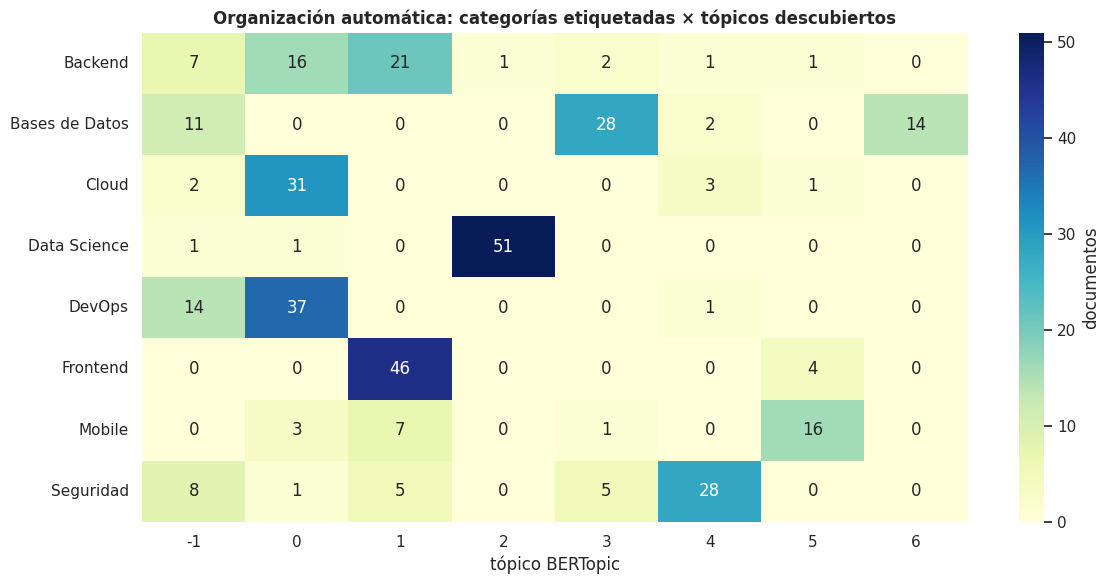

Lectura del mapa de calor: una fila concentrada en una columna significa que la
categoría etiquetada coincide con un tema emergente; una fila dispersa significa
que la categoría agrupa contenidos que el modelo considera temáticamente distintos.



,categoria,topico_bertopic,documentos,etiqueta_topico
2,Backend,1,21,"web, javascript, java, página"
1,Backend,0,16,"software, servicios, servicio, infraestructura"
0,Backend,-1,7,(sin tema definido / outlier)
4,Backend,3,2,"sql, bases datos, bases, relacional"
3,Backend,2,1,"análisis, función, ciencia, modelos"
5,Backend,4,1,"seguridad, autenticación, cortafuegos, protección"
6,Backend,5,1,"android, móviles, dispositivos, ios"
8,Bases de Datos,3,28,"sql, bases datos, bases, relacional"
10,Bases de Datos,6,14,"tabla, clave, atributo, elemento"
7,Bases de Datos,-1,11,(sin tema definido / outlier)


In [ ]:
# @title 6.2 — Organización automática: tópicos y tags del corpus
tabla_organizacion = (
    df.groupby(["categoria", "topico_bertopic"])
      .agg(documentos=("doc_id", "count"))
      .reset_index()
      .sort_values(["categoria", "documentos"], ascending=[True, False])
)
tabla_organizacion["etiqueta_topico"] = tabla_organizacion["topico_bertopic"].map(ETIQUETAS_TOPICO)

plt.figure(figsize=(12, 6))
pivote = df.pivot_table(index="categoria", columns="topico_bertopic",
                        values="doc_id", aggfunc="count").fillna(0)
sns.heatmap(pivote, annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label": "documentos"})
plt.title("Organización automática: categorías etiquetadas × tópicos descubiertos",
          fontweight="bold")
plt.xlabel("tópico BERTopic"); plt.ylabel("")
plt.tight_layout(); plt.show()

print("Lectura del mapa de calor: una fila concentrada en una columna significa que la")
print("categoría etiquetada coincide con un tema emergente; una fila dispersa significa")
print("que la categoría agrupa contenidos que el modelo considera temáticamente distintos.\n")
display(tabla_organizacion.head(15))

## 6.3 Motor de búsqueda semántica

Segunda capacidad. La consulta se codifica con **el mismo modelo** que indexó los documentos, de modo
que ambos viven en el mismo espacio vectorial y la comparación es directa.

Las tres consultas de demostración están elegidas para que **no compartan vocabulario literal** con
los documentos que deberían recuperar: *"¿cómo construir servicios web escalables?"* no contiene las
palabras "API", "REST" ni "backend". Si el sistema las recupera igualmente, es porque está operando
sobre significado — que es exactamente lo que TF-IDF no puede hacer y lo que justifica el costo de
los embeddings (§3.2).

El parámetro `categoria` aprovecha el filtrado combinado de ChromaDB: restringe la búsqueda por
metadatos **dentro** de la misma consulta ANN, sin una segunda pasada. Es lo que implementa el
recurso opcional *"consulta por categorías"* del brief.

In [ ]:
# @title 6.3 — Motor de búsqueda semántica
def buscar_semantica(consulta: str,
                     n: int = CFG.vectorial.n_resultados_busqueda,
                     categoria: str = None) -> pd.DataFrame:
    """Busca documentos por significado, no por coincidencia léxica.

    Args:
        consulta: Texto libre de la consulta.
        n: Número de resultados a devolver.
        categoria: Si se especifica, restringe la búsqueda a esa categoría
            aprovechando el filtrado combinado vector+metadatos de ChromaDB.

    Returns:
        DataFrame con `doc_id`, `similitud`, `categoria`, `titulo` y `extracto`,
        ordenado de mayor a menor similitud.

    Example:
        >>> buscar_semantica("desplegar aplicaciones en contenedores", n=3)
    """
    vector = CACHE.codificar([consulta], modelo_embeddings).tolist()
    res = coleccion.query(
        query_embeddings=vector,
        n_results=n,
        where={"categoria": categoria} if categoria else None,
    )
    return pd.DataFrame({
        "doc_id": res["ids"][0],
        "similitud": [round(1 - d, 4) for d in res["distances"][0]],
        "categoria": [m["categoria"] for m in res["metadatas"][0]],
        "titulo": [m["titulo"][:70] for m in res["metadatas"][0]],
        "extracto": [d[:120] + "..." for d in res["documents"][0]],
    })


CONSULTAS_DEMO = [
    "¿cómo construir servicios web escalables?",
    "modelos que aprenden a partir de datos",
    "desplegar aplicaciones en contenedores",
]

for consulta in CONSULTAS_DEMO:
    print("=" * 106)
    print(f"CONSULTA: {consulta}")
    display(buscar_semantica(consulta, n=4))

print("=" * 106)
print("Nótese que ninguna consulta comparte vocabulario literal con los documentos que recupera:")
print("es exactamente la propiedad que TF-IDF no puede ofrecer y que justifica los embeddings (§3.2).")

CONSULTA: ¿cómo construir servicios web escalables?
06:27:16 │ INFO    │ Embeddings: 1 por calcular, 0 desde caché


,doc_id,similitud,categoria,titulo,extracto
0,DOC-0294,0.6891,Backend,Servicio web,"Para mejorar la interoperabilidad entre distintas implementaciones de servicios web se ha creado el organismo WS-I, ..."
1,DOC-0091,0.6759,Backend,Servicio web,Un servicio web en inglés: web service es una tecnología que utiliza un conjunto de protocolos y estándares que sirv...
2,DOC-0050,0.6603,Backend,GraphQL,Proporciona una aproximación para desarrollo APIs web y ha sido comparado y contrastado con REST y otras arquitectur...
3,DOC-0242,0.6426,Mobile,Aplicación móvil,"Un servicio de alojamiento informático o web permite a organizaciones e individuos subir, alojar, gestionar o almace..."


CONSULTA: modelos que aprenden a partir de datos
06:27:16 │ INFO    │ Embeddings: 1 por calcular, 0 desde caché


,doc_id,similitud,categoria,titulo,extracto
0,DOC-0175,0.7123,Data Science,Análisis de datos,"El análisis de datos se sustenta en una amplia gama de técnicas y metodologías, entre las que se destacan la estadís..."
1,DOC-0139,0.6397,Data Science,Análisis de datos,"Se centra en la inferencia estadística, la cual permite tomar una decisión de forma sencilla con un grado de confian..."
2,DOC-0032,0.6147,Data Science,Aprendizaje automático,"En muchas ocasiones el campo de actuación del aprendizaje automático se solapa con el de la estadística inferencial,..."
3,DOC-0134,0.6121,Data Science,Análisis de datos,La importancia del análisis de datos radica en su capacidad para transformar grandes volúmenes de información en con...


CONSULTA: desplegar aplicaciones en contenedores
06:27:16 │ INFO    │ Embeddings: 1 por calcular, 0 desde caché


,doc_id,similitud,categoria,titulo,extracto
0,DOC-0137,0.5449,DevOps,Kubernetes,Kubernetes es una plataforma de código abierto para la orquestación de contenedores. Permite desplegar y automatizar...
1,DOC-0337,0.5377,DevOps,Entrega continua Relación con DevOps,"La entrega continua, por su parte, es un enfoque para automatizar la entrega del software, y se centra en reunir los..."
2,DOC-0038,0.5347,DevOps,Kubernetes Cápsulas Pods,La unidad básica de planificación en Kubernetes se denomina cápsula pod en idioma inglés . Esta agrega un nivel de a...
3,DOC-0280,0.5284,Cloud,Infraestructura como servicio Visión general,La contenedorización ofrece un rendimiento más alto que la virtualización debido a que no hay una sobrecarga por uso...


Nótese que ninguna consulta comparte vocabulario literal con los documentos que recupera:
es exactamente la propiedad que TF-IDF no puede ofrecer y que justifica los embeddings (§3.2).


## 6.4 Recomendación de contenido relacionado

Tercera capacidad, y la más barata de las tres: el vector del documento **ya está indexado**, así que
recomendar no requiere codificar nada — solo consultar vecinos.

El único detalle no obvio es pedir `n + 1` resultados y filtrar el propio documento: su vecino más
cercano es siempre él mismo, con similitud 1.0. Olvidarlo produce una recomendación que sugiere al
usuario el artículo que está leyendo.

**Limitación honesta:** esta recomendación es puramente semántica, así que siempre devuelve *lo más
parecido*. Para un sistema de aprendizaje eso no siempre es lo deseable — a veces el contenido más
útil es el complementario, no el redundante. Queda anotado en §9.3.

In [ ]:
# @title 6.4 — Recomendación de contenido relacionado
def recomendar_relacionados(doc_id: str, n: int = CFG.vectorial.n_relacionados) -> pd.DataFrame:
    """Recupera los documentos más similares a uno dado, excluyéndolo de sí mismo.

    Args:
        doc_id: Identificador del documento de referencia.
        n: Número de recomendaciones a devolver.

    Returns:
        DataFrame con `doc_id`, `similitud`, `categoria` y `titulo`.

    Raises:
        ValueError: Si el `doc_id` no existe en el corpus.

    Example:
        >>> recomendar_relacionados("DOC-0000", n=3)
    """
    posiciones = df.index[df["doc_id"] == doc_id]
    if len(posiciones) == 0:
        raise ValueError(f"El doc_id '{doc_id}' no existe en el corpus.")

    res = coleccion.query(
        query_embeddings=[embeddings[posiciones[0]].tolist()],
        n_results=n + 1,   # +1 porque el propio documento será el vecino más cercano
    )
    filas = [
        {"doc_id": _id, "similitud": round(1 - dist, 4),
         "categoria": meta["categoria"], "titulo": meta["titulo"][:70]}
        for _id, dist, meta in zip(res["ids"][0], res["distances"][0], res["metadatas"][0])
        if _id != doc_id
    ]
    return pd.DataFrame(filas[:n])


ref = df.loc[0]
print(f"DOCUMENTO DE REFERENCIA: [{ref['categoria']}] {ref['titulo'][:70]}")
print(f"  {ref['texto_limpio'][:200]}...\n")
print("CONTENIDOS RELACIONADOS:")
display(recomendar_relacionados(ref["doc_id"], n=5))

DOCUMENTO DE REFERENCIA: [Data Science] Procesamiento de lenguajes naturales Historia
  La historia del PLN empieza desde 1950, aunque se han encontrado trabajos anteriores. En 1950, Alan Turing publicó Computing machinery and intelligence, donde proponía lo que hoy se llama el test de T...

CONTENIDOS RELACIONADOS:


,doc_id,similitud,categoria,titulo
0,DOC-0024,0.6617,Data Science,Procesamiento de lenguajes naturales Historia
1,DOC-0195,0.5776,Data Science,K-medias Historia
2,DOC-0187,0.5243,Data Science,Red neuronal artificial Historia
3,DOC-0304,0.5220,Data Science,Ciencia de datos Historia
4,DOC-0040,0.5166,Data Science,Análisis de datos Antecedentes


## 6.5 Persistencia de resultados

Todo lo que el pipeline produce se guarda, en el formato adecuado a cada tipo de dato. La regla es
simple: **si costó cómputo generarlo, se persiste**; recalcular es aceptable durante el desarrollo,
no en una demo ni en producción.

| Qué | Dónde | Formato | Por qué ese formato |
|---|---|---|---|
| Documentos procesados | `datasets/processed/corpus_final.csv` | CSV | Legible, inspeccionable, cargable desde cualquier herramienta |
| Embeddings | `datasets/processed/embeddings.npy` | NumPy binario | Preserva `float32` sin pérdida ni conversión de texto |
| Caché de embeddings | `cache/embeddings_cache.joblib` | joblib comprimido | Indexado por hash: reutilizable entre corridas |
| Keywords | columna `keywords` de `corpus_final.csv` | lista serializada | Va con su documento; el backend la lleva a `JSONB` en PostgreSQL |
| Categorías y probabilidades | `datasets/processed/resultados_clasificacion.csv` | CSV | Predicción, probabilidad y acierto por documento |
| Vectores + metadatos | `chroma_db/` | ChromaDB persistente | Índice HNSW ya construido: no hay que reindexar al arrancar |
| Modelos | `models/*.joblib` | joblib | Requisito explícito del brief |
| Metadatos y config | `models/metadata.json`, `models/config.json` | JSON | Legible por humanos y por el backend |
| Log de ejecución | `logs/pipeline.log` | texto | Evidencia de la corrida, con timestamps |

**Sobre `resultados_clasificacion.csv`.** Guarda la predicción del modelo para **todo** el corpus,
incluida la columna `acierto`. Sirve para tres cosas concretas: analizar errores sin reejecutar el
pipeline, alimentar directamente la tabla `contenidos` de PostgreSQL, y establecer la línea base
contra la que se compara la siguiente versión del modelo.

In [ ]:
# @title 6.5 — Persistencia completa de resultados
@cronometrar("persistencia de resultados")
def persistir_resultados(cfg: Config = CFG) -> dict:
    """Guarda todos los productos del pipeline en sus formatos correspondientes.

    Args:
        cfg: Configuración con las rutas de salida.

    Returns:
        Diccionario {ruta: descripción} de los archivos escritos.
    """
    escritos: dict = {}

    # --- Predicciones del modelo sobre todo el corpus ---
    if GANADOR == "B":
        probabilidades = modelo_b.predict_proba(embeddings)
    else:
        probabilidades = modelo_a.predict_proba(textos_pos)
    predicciones = probabilidades.argmax(axis=1)

    resultados = pd.DataFrame({
        "doc_id": df["doc_id"],
        "titulo": df["titulo"],
        "categoria_real": df["categoria"],
        "categoria_predicha": le.inverse_transform(predicciones),
        "probabilidad": probabilidades.max(axis=1).round(4),
        "confianza_baja": probabilidades.max(axis=1) < cfg.clasificacion.umbral_confianza_baja,
        "particion": ["test" if i in set(idx_test) else "train" for i in range(len(df))],
        "topico": df["topico_bertopic"],
        "etiqueta_topico": df["topico_bertopic"].map(ETIQUETAS_TOPICO),
        "cluster_kmeans": df["cluster_kmeans"],
        "keywords": df["keywords"].apply(lambda ks: ", ".join(ks)),
        "entidades_tecnicas": df["entidades_tech"].apply(lambda es: ", ".join(es)),
    })
    resultados["acierto"] = resultados["categoria_real"] == resultados["categoria_predicha"]

    ruta = cfg.rutas.processed / "resultados_clasificacion.csv"
    resultados.to_csv(ruta, index=False)
    escritos[str(ruta)] = "Predicción, probabilidad, tópico y keywords por documento"

    # --- Corpus final enriquecido ---
    columnas = ["doc_id", "titulo", "categoria", "idioma", "idioma_confianza",
                "texto_limpio", "texto_pos", "keywords", "entidades_tech",
                "topico_bertopic", "cluster_kmeans", "n_tokens", "n_chars", "fuente"]
    columnas = [c for c in columnas if c in df.columns]
    ruta = cfg.rutas.processed / "corpus_final.csv"
    df[columnas].to_csv(ruta, index=False)
    escritos[str(ruta)] = "Corpus con todas las anotaciones del pipeline"

    # --- Embeddings ---
    ruta = cfg.rutas.processed / "embeddings.npy"
    np.save(ruta, embeddings)
    escritos[str(ruta)] = f"Matriz de embeddings {embeddings.shape} float32"

    # --- Índice de keywords: qué documentos mencionan cada término ---
    indice: dict = {}
    for _, fila in df.iterrows():
        for kw in fila["keywords"]:
            indice.setdefault(kw.lower(), []).append(fila["doc_id"])
    ruta = cfg.rutas.processed / "indice_keywords.json"
    ruta.write_text(json.dumps(indice, ensure_ascii=False, indent=2), encoding="utf-8")
    escritos[str(ruta)] = f"Índice invertido de {len(indice)} keywords → documentos"

    # --- Reporte de tiempos de ejecución ---
    ruta = cfg.rutas.logs / "tiempos_ejecucion.csv"
    pd.DataFrame(TIEMPOS).to_csv(ruta, index=False)
    escritos[str(ruta)] = f"{len(TIEMPOS)} operaciones cronometradas"

    CACHE.guardar()
    return escritos, resultados


with etapa("persistencia"):
    ARCHIVOS_ESCRITOS, RESULTADOS = persistir_resultados()

print("ARCHIVOS PERSISTIDOS\n")
for ruta, descripcion in ARCHIVOS_ESCRITOS.items():
    tam = Path(ruta).stat().st_size / 1024
    print(f"  {Path(ruta).name:<34} {tam:>9,.1f} KB   {descripcion}")

print(f"\nResumen de clasificación sobre el corpus completo:")
print(f"  aciertos                : {RESULTADOS['acierto'].sum()}/{len(RESULTADOS)} "
      f"({RESULTADOS['acierto'].mean():.1%})")
print(f"  confianza baja (<{CFG.clasificacion.umbral_confianza_baja}) : "
      f"{RESULTADOS['confianza_baja'].sum()} documentos")
display(RESULTADOS.head(6)[["doc_id", "categoria_real", "categoria_predicha",
                            "probabilidad", "acierto", "keywords"]])

06:27:17 │ INFO    │ ┌─ etapa · persistencia
06:27:17 │ INFO    │ ▶ inicio · persistencia de resultados
06:27:17 │ INFO    │ Caché persistida: 374 vectores en data_science/cache/embeddings_cache.joblib
06:27:17 │ INFO    │ ✔ fin    · persistencia de resultados en 0.21s
06:27:17 │ INFO    │ └─ etapa · persistencia completada en 0.21s
ARCHIVOS PERSISTIDOS

  resultados_clasificacion.csv            91.8 KB   Predicción, probabilidad, tópico y keywords por documento
  corpus_final.csv                       367.3 KB   Corpus con todas las anotaciones del pipeline
  embeddings.npy                         555.1 KB   Matriz de embeddings (370, 384) float32
  indice_keywords.json                    81.8 KB   Índice invertido de 1520 keywords → documentos
  tiempos_ejecucion.csv                    0.8 KB   23 operaciones cronometradas

Resumen de clasificación sobre el corpus completo:
  aciertos                : 357/370 (96.5%)
  confianza baja (<0.4) : 37 documentos


,doc_id,categoria_real,categoria_predicha,probabilidad,acierto,keywords
0,DOC-0000,Data Science,Data Science,0.7571,True,"computing machinery and intelligence, pln, aprendizaje automático, años traducción automática, teóricos desalentaron..."
1,DOC-0001,Seguridad,Seguridad,0.6825,True,"aspectos riesgo cibernético, diseñar estrategias seguridad, desarrollado modelos evaluación, representa intersección..."
2,DOC-0002,Data Science,Data Science,0.8599,True,"ann, retropropagacion, aprendizaje automático, redes neuronales, entrenan típicamente minimización"
3,DOC-0003,Data Science,Data Science,0.7699,True,"pln, aprendizaje automático, procesamiento lenguaje natural, comunicación personas máquinas, computación inteligenci..."
4,DOC-0004,DevOps,DevOps,0.7062,True,"iac, funcional vs imperativo, cumplir enfoque inteligente, configuración debería considerando, enfoque declarativo d..."
5,DOC-0005,Seguridad,Seguridad,0.6390,True,"filtra paquete basándose, internet paquete coincide, transferencia archivos máquinas, navegación web impresión, dist..."


## 6.6 Persistencia relacional (SQLite)

**Por qué una tercera base de datos.** Hasta aquí el pipeline persiste en archivos planos (CSV, JSON,
`.npy`) y en ChromaDB. Falta el tipo de consulta más común de todas: la relacional.

Ninguna de las dos piezas actuales la resuelve. ChromaDB responde *"¿qué se parece a esto?"* pero no
*"dame las keywords del documento DOC-0042"* ni *"¿cuántas predicciones se hicieron hoy con confianza
por debajo de 0.4?"*. Los CSV responden ambas, pero solo cargándolos enteros en memoria y filtrando
con pandas — inviable desde un backend que atiende peticiones concurrentes.

**Por qué SQLite aquí y PostgreSQL allá.** `Technology_Architecture.md` §9 elige PostgreSQL para
producción y descarta SQLite explícitamente como base del servicio: archivo local, concurrencia de
escritura serializada, incompatible con contenedores efímeros. Ese mismo documento **recomienda
SQLite dentro del notebook** de Ciencia de Datos, que es un proceso único, local y desechable — el
escenario donde SQLite es la elección correcta y PostgreSQL sería una pieza de infraestructura
innecesaria.

El detalle que hace útil esta decisión: **el esquema es el mismo**. Las seis tablas de abajo se
traducen a PostgreSQL cambiando `TEXT` por `VARCHAR` y `AUTOINCREMENT` por `SERIAL`. Migrar es un
cambio de cadena de conexión, no un rediseño del modelo de datos.

| Tabla | Qué guarda | Pregunta que responde |
|---|---|---|
| `documentos` | Metadatos por documento | *¿Qué documentos hay de categoría Backend?* |
| `keywords_documento` | Keywords rankeadas, con su posición | *¿Qué documentos mencionan "Docker"?* |
| `resultados_clustering` | Cluster KMeans y tópico BERTopic | *¿Qué documentos forman el tópico 3?* |
| `resultados_clasificacion` | Predicción del modelo por documento | *¿Dónde se equivoca el modelo?* |
| `predicciones_api` | Registro de cada inferencia servida | *¿Cuántas peticiones tuvieron confianza baja esta semana?* |
| `versiones_modelo` | Historial de entrenamientos | *¿Mejoró el F1 respecto de la versión anterior?* |

**Sobre la idempotencia.** `documentos` y `resultados_clustering` tienen clave primaria natural
(`doc_id`), así que usan `INSERT OR REPLACE` y re-ejecutar la celda es inocuo. `keywords_documento` y
`resultados_clasificacion` no la tienen —un documento tiene varias keywords— así que se vacían antes
de reinsertar. Es correcto mientras el corpus se reconstruya completo en cada corrida, que es lo que
hace este notebook; si el corpus creciera de forma incremental habría que pasar a un upsert por lote,
y queda anotado en §9.3.

In [ ]:
# @title 6.6.1 — Esquema relacional y poblado
ESQUEMA_SQL = """
CREATE TABLE IF NOT EXISTS documentos (
    doc_id      TEXT PRIMARY KEY,
    titulo      TEXT,
    categoria   TEXT,
    idioma      TEXT,
    n_tokens    INTEGER,
    n_chars     INTEGER,
    fuente      TEXT
);
CREATE TABLE IF NOT EXISTS keywords_documento (
    doc_id      TEXT,
    keyword     TEXT,
    rango       INTEGER,
    FOREIGN KEY (doc_id) REFERENCES documentos(doc_id)
);
CREATE TABLE IF NOT EXISTS resultados_clustering (
    doc_id            TEXT PRIMARY KEY,
    cluster_kmeans    INTEGER,
    topico_bertopic   INTEGER,
    etiqueta_topico   TEXT,
    FOREIGN KEY (doc_id) REFERENCES documentos(doc_id)
);
CREATE TABLE IF NOT EXISTS resultados_clasificacion (
    doc_id          TEXT,
    categoria_real  TEXT,
    categoria_pred  TEXT,
    probabilidad    REAL,
    acierto         INTEGER,
    particion       TEXT,
    modelo          TEXT,
    FOREIGN KEY (doc_id) REFERENCES documentos(doc_id)
);
CREATE TABLE IF NOT EXISTS predicciones_api (
    id              INTEGER PRIMARY KEY AUTOINCREMENT,
    fecha           TEXT,
    titulo          TEXT,
    categoria       TEXT,
    probabilidad    REAL,
    confianza_baja  INTEGER,
    idioma          TEXT,
    keywords        TEXT,
    latencia_ms     REAL,
    version_modelo  TEXT
);
CREATE TABLE IF NOT EXISTS versiones_modelo (
    version              TEXT,
    fecha                TEXT,
    huella_configuracion TEXT,
    tipo_clasificador    TEXT,
    dataset              TEXT,
    hash_dataset         TEXT,
    n_documentos         INTEGER,
    parametros_json      TEXT,
    metricas_json        TEXT
);
CREATE INDEX IF NOT EXISTS idx_kw ON keywords_documento(keyword);
CREATE INDEX IF NOT EXISTS idx_cat ON documentos(categoria);
CREATE INDEX IF NOT EXISTS idx_pred_fecha ON predicciones_api(fecha);
"""


def inicializar_sqlite(cfg: Config = CFG) -> sqlite3.Connection:
    """Crea el esquema relacional si no existe y devuelve una conexión abierta.

    Args:
        cfg: Configuración con la ruta del archivo de base de datos.

    Returns:
        Conexión SQLite lista para usar.

    Example:
        >>> con = inicializar_sqlite()
        >>> con.execute("SELECT COUNT(*) FROM documentos").fetchone()[0] >= 0
        True
    """
    ruta = cfg.rutas.base / cfg.persistencia.archivo_sqlite
    con = sqlite3.connect(str(ruta))
    con.executescript(ESQUEMA_SQL)
    con.commit()
    log.info(f"Esquema SQLite inicializado en {ruta}")
    return con


@cronometrar("poblado de SQLite")
def poblar_sqlite(con: sqlite3.Connection, df: pd.DataFrame,
                  resultados: pd.DataFrame, cfg: Config = CFG) -> dict:
    """Puebla las tablas relacionales desde el corpus procesado.

    Args:
        con: Conexión SQLite abierta.
        df: Corpus con anotaciones del pipeline.
        resultados: DataFrame de §6.5 con las predicciones por documento.
        cfg: Configuración del pipeline.

    Returns:
        Diccionario {tabla: número de filas}.
    """
    # Tablas sin clave primaria natural: se vacían para que re-ejecutar no duplique.
    con.execute("DELETE FROM keywords_documento")
    con.execute("DELETE FROM resultados_clasificacion")

    con.executemany(
        "INSERT OR REPLACE INTO documentos VALUES (?, ?, ?, ?, ?, ?, ?)",
        [(r["doc_id"], r["titulo"], r["categoria"], r["idioma"],
          int(r["n_tokens"]), int(r["n_chars"]), str(r.get("fuente", "")))
         for _, r in df.iterrows()],
    )

    con.executemany(
        "INSERT INTO keywords_documento VALUES (?, ?, ?)",
        [(r["doc_id"], kw, rango)
         for _, r in df.iterrows()
         for rango, kw in enumerate(r["keywords"], start=1)],
    )

    con.executemany(
        "INSERT OR REPLACE INTO resultados_clustering VALUES (?, ?, ?, ?)",
        [(r["doc_id"], int(r["cluster_kmeans"]), int(r["topico_bertopic"]),
          ETIQUETAS_TOPICO.get(int(r["topico_bertopic"]), ""))
         for _, r in df.iterrows()],
    )

    tipo_clf = "sbert+logreg" if GANADOR == "B" else "tfidf+logreg"
    con.executemany(
        "INSERT INTO resultados_clasificacion VALUES (?, ?, ?, ?, ?, ?, ?)",
        [(r["doc_id"], r["categoria_real"], r["categoria_predicha"],
          float(r["probabilidad"]), int(bool(r["acierto"])), r["particion"], tipo_clf)
         for _, r in resultados.iterrows()],
    )

    con.commit()

    conteos = {t: con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
               for t in ("documentos", "keywords_documento",
                         "resultados_clustering", "resultados_clasificacion")}
    log.info(f"SQLite poblada: {conteos}")
    return conteos


with etapa("persistencia relacional"):
    con_sqlite = inicializar_sqlite()
    CONTEOS_SQLITE = poblar_sqlite(con_sqlite, df, RESULTADOS)

print("TABLAS POBLADAS\n")
for tabla, n in CONTEOS_SQLITE.items():
    print(f"  {tabla:<28} {n:>6} filas")
print(f"\nBase de datos: {CFG.rutas.base / CFG.persistencia.archivo_sqlite}")

06:27:17 │ INFO    │ ┌─ etapa · persistencia relacional
06:27:17 │ INFO    │ Esquema SQLite inicializado en data_science/techmind.db
06:27:17 │ INFO    │ ▶ inicio · poblado de SQLite
06:27:17 │ INFO    │ SQLite poblada: {'documentos': 370, 'keywords_documento': 1850, 'resultados_clustering': 370, 'resultados_clasificacion': 370}
06:27:17 │ INFO    │ ✔ fin    · poblado de SQLite en 0.16s
06:27:17 │ INFO    │ └─ etapa · persistencia relacional completada en 0.23s
TABLAS POBLADAS

  documentos                      370 filas
  keywords_documento             1850 filas
  resultados_clustering           370 filas
  resultados_clasificacion        370 filas

Base de datos: data_science/techmind.db


In [ ]:
# @title 6.6.2 — Consultas relacionales de demostración
CONSULTAS_DEMO = {
    "Documentos por categoría":
        """SELECT categoria, COUNT(*) AS documentos, ROUND(AVG(n_tokens), 1) AS tokens_medios
           FROM documentos GROUP BY categoria ORDER BY documentos DESC""",

    "Keywords más frecuentes del corpus":
        """SELECT keyword, COUNT(*) AS documentos
           FROM keywords_documento GROUP BY keyword
           ORDER BY documentos DESC LIMIT 10""",

    "Precisión por categoría (desde SQL, sin recalcular)":
        """SELECT categoria_real,
                  COUNT(*) AS total,
                  SUM(acierto) AS aciertos,
                  ROUND(100.0 * SUM(acierto) / COUNT(*), 1) AS pct_acierto
           FROM resultados_clasificacion
           GROUP BY categoria_real ORDER BY pct_acierto ASC""",

    "Documentos donde el modelo falla con alta confianza":
        """SELECT c.doc_id, d.titulo, c.categoria_real, c.categoria_pred, c.probabilidad
           FROM resultados_clasificacion c JOIN documentos d ON d.doc_id = c.doc_id
           WHERE c.acierto = 0 AND c.probabilidad > 0.6
           ORDER BY c.probabilidad DESC LIMIT 5""",
}

for titulo, sql in CONSULTAS_DEMO.items():
    print("=" * 92)
    print(titulo)
    print("-" * 92)
    display(pd.read_sql(sql, con_sqlite))

print("=" * 92)
print("Estas cuatro consultas son la justificación de la tabla: ninguna se puede responder")
print("con ChromaDB, y todas requerirían cargar el CSV completo en memoria sin SQL.")

Documentos por categoría
--------------------------------------------------------------------------------------------


,categoria,documentos,tokens_medios
0,Bases de Datos,55,32.1
1,Data Science,53,38.7
2,DevOps,52,34.2
3,Frontend,50,37.7
4,Backend,49,38.6
5,Seguridad,47,35.7
6,Cloud,37,34.9
7,Mobile,27,35.2


Keywords más frecuentes del corpus
--------------------------------------------------------------------------------------------


,keyword,documentos
0,HTML,21
1,JavaScript,19
2,Java,16
3,SQL,16
4,google,15
5,microsoft,14
6,aprendizaje automático,12
7,Android,11
8,iOS,11
9,HTTP,10


Precisión por categoría (desde SQL, sin recalcular)
--------------------------------------------------------------------------------------------


,categoria_real,total,aciertos,pct_acierto
0,Cloud,37,34,91.9
1,Backend,49,46,93.9
2,Frontend,50,47,94.0
3,Seguridad,47,45,95.7
4,DevOps,52,51,98.1
5,Bases de Datos,55,54,98.2
6,Data Science,53,53,100.0
7,Mobile,27,27,100.0


Documentos donde el modelo falla con alta confianza
--------------------------------------------------------------------------------------------


,doc_id,titulo,categoria_real,categoria_pred,probabilidad


Estas cuatro consultas son la justificación de la tabla: ninguna se puede responder
con ChromaDB, y todas requerirían cargar el CSV completo en memoria sin SQL.


## 6.7 Historial de versiones del modelo

`metadata.json` (§5.7) describe la versión **actual** con todo detalle — pero se sobrescribe en cada
entrenamiento. Después de tres corridas no queda rastro de las dos primeras, y la pregunta más
elemental del ciclo de vida de un modelo se vuelve incontestable: *¿esta versión es mejor que la
anterior?*

`registrar_version_modelo()` resuelve eso escribiendo en **dos destinos de solo-anexado**, sin tocar
`metadata.json` (que el backend sigue leyendo tal cual):

- **Tabla `versiones_modelo`** — consultable por SQL, para comparar métricas entre entrenamientos.
- **`historial_versiones.jsonl`** — una línea JSON por corrida. Formato deliberadamente humilde:
  sobrevive a que la base de datos se borre, se lee con `tail`, se versiona en Git sin conflictos de
  merge (cada corrida es una línea nueva) y no requiere ninguna herramienta para inspeccionarlo.

No es MLflow ni Weights & Biases, y no pretende serlo: para un MVP de hackathon, un JSONL de
solo-anexado da el 90 % del valor —trazabilidad y comparación entre versiones— con cero
infraestructura adicional que desplegar y explicar al jurado.

In [ ]:
# @title 6.7 — Registro append-only de la versión entrenada
def registrar_version_modelo(metadatos: dict, con: sqlite3.Connection = None,
                             cfg: Config = CFG) -> dict:
    """Añade la versión actual al historial, sin sobrescribir entrenamientos previos.

    Escribe en dos destinos de solo-anexado: la tabla `versiones_modelo` y un
    archivo JSONL. `metadata.json` no se toca: sigue describiendo la versión
    vigente, que es lo que el backend espera encontrar.

    Args:
        metadatos: Diccionario producido por `serializar_artefactos` (§5.7).
        con: Conexión SQLite. Si es None, usa la global `con_sqlite`.
        cfg: Configuración del pipeline.

    Returns:
        Diccionario con el número total de versiones registradas y la ruta del JSONL.

    Example:
        >>> registrar_version_modelo(METADATOS)["n_versiones"] >= 1
        True
    """
    con = con if con is not None else con_sqlite
    ruta_jsonl = cfg.rutas.models / cfg.persistencia.archivo_historial

    prueba = metadatos["metricas"]["conjunto_prueba"]
    con.execute(
        "INSERT INTO versiones_modelo VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)",
        (
            metadatos["version"],
            metadatos["fecha_entrenamiento"],
            metadatos["huella_configuracion"][:16],
            metadatos["modelo"]["tipo_clasificador"],
            metadatos["dataset"]["fuente"],
            metadatos["dataset"]["hash_sha256"][:16],
            metadatos["dataset"]["n_documentos"],
            json.dumps(metadatos["hiperparametros"], ensure_ascii=False, default=str),
            json.dumps(metadatos["metricas"], ensure_ascii=False, default=str),
        ),
    )
    con.commit()

    with open(ruta_jsonl, "a", encoding="utf-8") as f:
        f.write(json.dumps(metadatos, ensure_ascii=False, default=str) + "\n")

    n = con.execute("SELECT COUNT(*) FROM versiones_modelo").fetchone()[0]
    log.info(f"Versión {metadatos['version']} registrada en el historial "
             f"(total acumulado: {n})")
    return {"n_versiones": n, "jsonl": str(ruta_jsonl)}


REGISTRO_VERSION = registrar_version_modelo(METADATOS)

print(f"Versiones en el historial: {REGISTRO_VERSION['n_versiones']}")
print(f"JSONL de solo-anexado    : {REGISTRO_VERSION['jsonl']}\n")

historial = pd.read_sql(
    """SELECT version, substr(fecha, 1, 19) AS fecha, tipo_clasificador,
              n_documentos, huella_configuracion
       FROM versiones_modelo ORDER BY fecha DESC LIMIT 10""",
    con_sqlite)
display(historial)

if len(historial) > 1:
    print("\nComparación de F1-macro entre versiones registradas:")
    for _, fila in pd.read_sql(
            "SELECT version, fecha, metricas_json FROM versiones_modelo ORDER BY fecha",
            con_sqlite).iterrows():
        m = json.loads(fila["metricas_json"])
        print(f"  {fila['fecha'][:19]}  v{fila['version']:<8} "
              f"f1_macro = {m['conjunto_prueba']['f1_macro']:.4f}")
else:
    print("\nEsta es la primera versión registrada. Al reentrenar, esta celda mostrará")
    print("la comparación de métricas entre corridas sin necesidad de reejecutar nada.")

06:27:17 │ INFO    │ Versión 2.0.0 registrada en el historial (total acumulado: 1)
Versiones en el historial: 1
JSONL de solo-anexado    : data_science/models/historial_versiones.jsonl



,version,fecha,tipo_clasificador,n_documentos,huella_configuracion
0,2.0.0,2026-07-28T06:27:15,tfidf+logreg,370,ac475d0930389a56



Esta es la primera versión registrada. Al reentrenar, esta celda mostrará
la comparación de métricas entre corridas sin necesidad de reejecutar nada.


---
# 7. Capa de inferencia — lista para FastAPI

Esta sección es la **frontera entre Ciencia de Datos y Backend**, y su diseño responde a un problema
concreto del prototipo anterior: la función de inferencia dependía de una decena de variables
globales del notebook (`modelo_b`, `le`, `nlp`, `coleccion`, `topic_model`…). Eso funciona mientras
todo vive en el mismo kernel, y deja de funcionar en cuanto el backend intenta importarla — porque
esas globales no existen en `app/services/nlp_service.py`.

**La solución: separar explícitamente las cuatro responsabilidades** que el brief pide distinguir.

| Responsabilidad | Dónde vive | Cuándo se ejecuta |
|---|---|---|
| **Entrenamiento** | §5 de este notebook | Offline, una vez por versión del modelo |
| **Carga del modelo** | `TechMindInference.desde_artefactos()` | Una vez, al arrancar el proceso de FastAPI |
| **Predicción** | `TechMindInference.predecir()` | En cada petición HTTP |
| **Contrato de salida** | `RespuestaContenido` | Espejo del modelo Pydantic del backend |

`TechMindInference` recibe **todas** sus dependencias en el constructor. Eso la vuelve instanciable
desde cualquier proceso, testeable con dobles de prueba, y —no menor— permite tener dos versiones del
modelo cargadas a la vez durante un despliegue gradual.

### Una trampa fácil de pasar por alto

Es tentador declarar "la clase no lee globales" mirando solo su cuerpo. Pero si un método llama a una
función auxiliar que **sí** las lee, la dependencia sigue ahí, solo que escondida un nivel más abajo.
La clase parece portable, se importa desde el backend, y falla con `NameError` en la primera
petición.

En este notebook el riesgo era real: `rankear_keywords()` leía `nlp`, `kw_model` y `extractor_yake`
del ámbito global, y `explicar_prediccion()` leía `GANADOR`, `modelo_a`/`modelo_b`, `CENTROIDES` y
`CATEGORIAS`. Ninguna de esas variables existe en `app/services/nlp_service.py`.

La corrección fue dar a ambas funciones **parámetros de sólo-palabra clave** para inyectar esas
dependencias, con los globales como valor por defecto. El notebook las sigue llamando igual; la clase
las llama pasando lo que recibió en su constructor. El test `test_sin_globales` de §7.5 verifica que
la separación se sostiene: instancia la clase con dependencias explícitas y predice con los nombres
globales del entrenamiento borrados del ámbito.

## Diagrama 7 — Flujo de inferencia (`POST /contenido`)

```mermaid
sequenceDiagram
    autonumber
    participant C as Cliente
    participant F as FastAPI<br/>routes/contenido.py
    participant P as Pydantic<br/>ContenidoRequest
    participant S as TechMindInference<br/>nlp_service.py
    participant SP as spaCy
    participant E as SBERT + caché
    participant M as Clasificador
    participant CH as ChromaDB
    participant PG as PostgreSQL

    C->>F: POST /contenido<br/>{titulo, texto}
    F->>P: Validación de tipos
    alt tipos inválidos
        P-->>C: 422 Unprocessable Entity
    end
    P->>S: predecir(titulo, texto)

    S->>S: validar_entrada() · 7 controles
    alt documento inválido
        S-->>F: ErrorValidacion(codigo, mensaje)
        F-->>C: 422 con código de error tipificado
    end

    S->>S: detectar_idioma()
    alt idioma no soportado
        S-->>C: 422 idioma_no_soportado
    end

    S->>S: limpiar_texto() · NFKC · ruido
    S->>SP: nlp(texto_limpio)
    SP-->>S: Doc · lemas · POS · entidades TECH

    S->>E: codificar(texto_limpio)
    alt acierto de caché
        E-->>S: vector recuperado
    else fallo de caché
        E->>E: encode() · 12 capas Transformer
        E-->>S: vector 384-d
    end

    par Cálculos sobre el mismo vector
        S->>M: predict_proba(vector)
        M-->>S: categoria + probabilidad
    and
        S->>S: rankear_keywords(doc reutilizado)
    and
        S->>CH: query(vector, n=3)
        CH-->>S: documentos relacionados
    end

    opt explicabilidad solicitada
        S->>M: ablación por término
        M-->>S: contribuciones
    end

    S-->>F: RespuestaContenido
    F->>PG: INSERT metadatos
    F->>CH: add(vector) si es contenido nuevo
    F-->>C: 200 OK<br/>{categoria, probabilidad,<br/>informacion_adicional, ...}
```

**Lo que el diagrama vuelve explícito:** el bloque `par` marca las tres operaciones que consumen el
**mismo vector** ya calculado. Es la materialización de la decisión de §3.2 — un `encode()` por
petición, no tres. Y el `Doc` de spaCy se calcula una vez y se pasa a `rankear_keywords()`, evitando
la segunda pasada que tenía el prototipo anterior.

In [ ]:
# @title 7.1 — Contrato de salida
@dataclass
class RespuestaContenido:
    """Respuesta del endpoint POST /contenido.

    Los tres primeros campos son el contrato mínimo exigido por el brief y no
    cambian de nombre ni de tipo. El resto son extensiones propias del equipo,
    admitidas explícitamente por el enunciado.

    Attributes:
        categoria: Categoría temática asignada.
        probabilidad: Confianza de la predicción, en [0, 1].
        informacion_adicional: Palabras clave representativas del contenido.
        titulo: Título recibido, normalizado.
        idioma: Resultado de la detección de idioma.
        tema: Tópico emergente descubierto por BERTopic.
        entidades_tecnicas: Tecnologías reconocidas por el EntityRuler.
        distribucion_categorias: Tres categorías más probables con su probabilidad.
        metricas_texto: Estadísticos del documento procesado.
        explicacion: Justificación de la categoría asignada (opcional).
        relacionados: Contenidos semánticamente próximos (opcional).
        advertencias: Observaciones no bloqueantes de la validación.

    Example:
        >>> r = RespuestaContenido("Backend", 0.89, ["Java", "Spring Boot"])
        >>> r.a_dict()["categoria"]
        'Backend'
    """
    categoria: str
    probabilidad: float
    informacion_adicional: list

    titulo: str = ""
    idioma: dict = field(default_factory=dict)
    tema: dict = field(default_factory=dict)
    entidades_tecnicas: list = field(default_factory=list)
    distribucion_categorias: dict = field(default_factory=dict)
    metricas_texto: dict = field(default_factory=dict)
    explicacion: dict = field(default_factory=dict)
    relacionados: list = field(default_factory=list)
    advertencias: list = field(default_factory=list)

    def a_dict(self) -> dict:
        """Serializa la respuesta a un diccionario JSON-compatible."""
        return asdict(self)

    def a_json(self, indent: int = 2) -> str:
        """Serializa la respuesta a una cadena JSON."""
        return json.dumps(self.a_dict(), ensure_ascii=False, indent=indent)


print("Contrato de salida definido.")
print("Campos obligatorios del brief:", ["categoria", "probabilidad", "informacion_adicional"])

Contrato de salida definido.
Campos obligatorios del brief: ['categoria', 'probabilidad', 'informacion_adicional']


In [ ]:
# @title 7.2 — Clase de inferencia sin estado global
class TechMindInference:
    """Capa de inferencia de TechMind, lista para importar desde FastAPI.

    Encapsula el pipeline completo de predicción sin depender de variables
    globales del notebook. Todas las dependencias se inyectan en el constructor,
    lo que permite instanciarla desde otro proceso, sustituirlas por dobles en
    los tests, o mantener dos versiones cargadas durante un despliegue gradual.

    Uso previsto en el backend::

        # app/services/nlp_service.py
        servicio = TechMindInference.desde_artefactos(Path("models"))

        # app/api/routes/contenido.py
        @router.post("/contenido")
        async def procesar(payload: ContenidoRequest):
            return await run_in_threadpool(
                servicio.predecir, payload.titulo, payload.texto
            )

    Attributes:
        metadatos: Contenido de `metadata.json`, con versión, métricas y dataset.
        categorias: Lista ordenada de categorías que el modelo puede predecir.

    Example:
        >>> servicio = TechMindInference.desde_objetos(...)
        >>> r = servicio.predecir("Spring Boot", "Framework de Java para APIs REST.")
        >>> r.categoria in servicio.categorias
        True
    """

    def __init__(self, *, modelo_clasificacion, label_encoder, modelo_embeddings,
                 pipeline_nlp, cfg: Config, tipo_clasificador: str,
                 modelo_keybert=None, extractor_yake=None, mapa_tecnologias: dict = None,
                 metadatos: dict = None, topic_model=None, coleccion_vectorial=None,
                 etiquetas_topico: dict = None, centroides: np.ndarray = None,
                 cache=None, conexion_sqlite=None):
        self.clf = modelo_clasificacion
        self.le = label_encoder
        self.embedder = modelo_embeddings
        self.nlp = pipeline_nlp
        self.cfg = cfg
        self.tipo_clasificador = tipo_clasificador
        # --- Dependencias del ranking de keywords (antes leídas del ámbito global) ---
        self.keybert = modelo_keybert
        self.yake = extractor_yake
        self.mapa_tecnologias = mapa_tecnologias or {}
        # --- Resto ---
        self.metadatos = metadatos or {}
        self.topic_model = topic_model
        self.coleccion = coleccion_vectorial
        self.etiquetas_topico = etiquetas_topico or {}
        self.centroides = centroides
        self.cache = cache
        self.con = conexion_sqlite
        self.categorias = list(label_encoder.classes_)
        log.info(f"TechMindInference lista · clasificador={tipo_clasificador} · "
                 f"{len(self.categorias)} categorías · "
                 f"auditoría={'sí' if conexion_sqlite is not None else 'no'}")

    # ------------------------------------------------------------------ #
    # Carga del modelo — se ejecuta una vez al arrancar el proceso        #
    # ------------------------------------------------------------------ #
    @classmethod
    def desde_artefactos(cls, directorio: Path, cfg: Config = None) -> "TechMindInference":
        """Construye la capa de inferencia cargando los artefactos desde disco.

        Es el punto de entrada que usa el backend: lee `metadata.json`, carga el
        clasificador, el codificador de etiquetas, el modelo de embeddings y el
        pipeline de spaCy declarados allí, y devuelve un servicio listo.

        Args:
            directorio: Carpeta con los artefactos serializados en §5.7.
            cfg: Configuración. Si es None, se lee `config.json` del directorio.

        Returns:
            Una instancia de `TechMindInference`.

        Raises:
            FileNotFoundError: Si falta `metadata.json` o el clasificador.
        """
        directorio = Path(directorio)
        ruta_meta = directorio / "metadata.json"
        if not ruta_meta.exists():
            raise FileNotFoundError(f"No se encontró metadata.json en {directorio}")

        metadatos = json.loads(ruta_meta.read_text(encoding="utf-8"))
        cfg = cfg or Config()

        clf = joblib.load(directorio / "modelo_clasificacion.joblib")
        codificador = joblib.load(directorio / "label_encoder.joblib")

        from sentence_transformers import SentenceTransformer
        import spacy
        embedder = SentenceTransformer(metadatos["modelo"]["modelo_embeddings"])
        pipeline = spacy.load(metadatos["modelo"]["modelo_spacy"])

        centroides = None
        ruta_centroides = directorio / "centroides_clase.joblib"
        if ruta_centroides.exists():
            centroides = joblib.load(ruta_centroides)["centroides"]

        # Dependencias del ranking de keywords, reconstruidas desde los artefactos.
        from keybert import KeyBERT
        import yake
        keybert = KeyBERT(model=embedder)
        extractor = yake.KeywordExtractor(
            lan=cfg.idioma.idioma_objetivo, n=cfg.keywords.ngram_max,
            dedupLim=cfg.keywords.yake_dedup_limite,
            top=cfg.keywords.keybert_candidatos, features=None)

        ruta_tecnologias = directorio / "tecnologias.json"
        if ruta_tecnologias.exists():
            tecnologias = json.loads(ruta_tecnologias.read_text(encoding="utf-8"))
        else:
            tecnologias = metadatos.get("modelo", {}).get("tecnologias", [])
        mapa = {t.lower(): t for t in tecnologias}

        log.info(f"Artefactos cargados desde {directorio} "
                 f"(versión {metadatos.get('version')})")
        return cls(
            modelo_clasificacion=clf,
            label_encoder=codificador,
            modelo_embeddings=embedder,
            pipeline_nlp=pipeline,
            cfg=cfg,
            tipo_clasificador=metadatos["modelo"]["tipo_clasificador"],
            modelo_keybert=keybert,
            extractor_yake=extractor,
            mapa_tecnologias=mapa,
            metadatos=metadatos,
            centroides=centroides,
        )

    @classmethod
    def desde_objetos(cls, **kwargs) -> "TechMindInference":
        """Construye la capa de inferencia con objetos ya en memoria.

        Es la vía que usa este notebook, donde los modelos acaban de entrenarse y
        no tiene sentido volver a leerlos del disco.
        """
        return cls(**kwargs)

    # ------------------------------------------------------------------ #
    # Predicción — se ejecuta en cada petición                            #
    # ------------------------------------------------------------------ #
    def _codificar(self, textos: list) -> np.ndarray:
        """Codifica textos usando la caché si está disponible."""
        if self.cache is not None:
            return self.cache.codificar(textos, self.embedder)
        return self.embedder.encode(textos,
                                    normalize_embeddings=self.cfg.embeddings.normalizar)

    def _clasificar(self, texto_limpio: str, texto_pos: str) -> tuple:
        """Devuelve (vector, distribución de probabilidad) según el tipo de clasificador."""
        vector = self._codificar([texto_limpio])
        if self.tipo_clasificador == "sbert+logreg":
            probas = self.clf.predict_proba(vector)[0]
        else:
            probas = self.clf.predict_proba([texto_pos])[0]
        return vector, probas

    def _probabilidades(self, texto_limpio: str, texto_pos: str) -> np.ndarray:
        """Predictor inyectable para la explicabilidad: usa solo estado de la instancia."""
        return self._clasificar(texto_limpio, texto_pos)[1]

    def _keywords(self, texto_limpio: str, doc_spacy) -> list:
        """Ranking de keywords usando exclusivamente las dependencias inyectadas."""
        return rankear_keywords(
            texto_limpio,
            doc_spacy=doc_spacy,
            top_k=self.cfg.keywords.top_k,
            cfg=self.cfg,
            modelo_keybert=self.keybert,
            extractor=self.yake,
            pipeline_nlp=self.nlp,
            mapa_tecnologias=self.mapa_tecnologias,
        )

    def _explicar(self, texto_limpio: str, texto_pos: str, candidatos: Sequence) -> dict:
        """Explicabilidad local usando exclusivamente las dependencias inyectadas."""
        return explicar_prediccion(
            texto_limpio, texto_pos, candidatos,
            predictor=self._probabilidades,
            centroides=self.centroides,
            categorias=self.categorias,
            codificador=self._codificar,
        )

    def _auditar(self, respuesta: "RespuestaContenido", latencia_ms: float) -> None:
        """Registra la predicción en la tabla `predicciones_api` si hay conexión.

        Args:
            respuesta: Respuesta ya construida.
            latencia_ms: Duración total de la inferencia en milisegundos.

        Returns:
            None. Los fallos de auditoría se registran pero no interrumpen la
            respuesta: no servir una predicción correcta porque falló el log
            sería un modo de fallo peor que el propio fallo.
        """
        if self.con is None or not self.cfg.persistencia.persistir_predicciones:
            return
        try:
            self.con.execute(
                "INSERT INTO predicciones_api "
                "(fecha, titulo, categoria, probabilidad, confianza_baja, "
                " idioma, keywords, latencia_ms, version_modelo) "
                "VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)",
                (pd.Timestamp.now().isoformat(),
                 respuesta.titulo,
                 respuesta.categoria,
                 respuesta.probabilidad,
                 int(respuesta.probabilidad < self.cfg.clasificacion.umbral_confianza_baja),
                 respuesta.idioma.get("codigo", ""),
                 ", ".join(respuesta.informacion_adicional),
                 round(latencia_ms, 2),
                 self.metadatos.get("version", self.cfg.version)),
            )
            self.con.commit()
        except Exception as exc:
            log.warning(f"No se pudo auditar la predicción ({type(exc).__name__}): {exc}")

    def predecir(self, titulo: str, texto: str, *,
                 incluir_relacionados: bool = True,
                 incluir_explicacion: bool = True,
                 n_relacionados: int = None) -> RespuestaContenido:
        """Ejecuta el pipeline completo de inferencia sobre un documento.

        Args:
            titulo: Título del contenido. Obligatorio.
            texto: Cuerpo del contenido. Obligatorio.
            incluir_relacionados: Consulta ChromaDB por contenidos similares.
            incluir_explicacion: Calcula la explicabilidad local por ablación.
                Tiene costo: multiplica el número de predicciones por el número
                de términos evaluados.
            n_relacionados: Número de recomendaciones. Por defecto, el de la configuración.

        Returns:
            Un `RespuestaContenido` con el contrato del brief más las extensiones.

        Raises:
            ErrorValidacion: Si el documento no supera los controles de §2.1.

        Example:
            >>> servicio.predecir("Docker", "Guía de contenedores y orquestación.").categoria
            'DevOps'
        """
        t0 = time.perf_counter()

        # --- 1. Validación ---
        validacion = exigir_valido(titulo, texto, modo="inferencia")

        # --- 2. Idioma ---
        idioma = detectar_idioma(validacion.texto, cfg=self.cfg)
        if self.cfg.idioma.rechazar_idioma_no_soportado and not idioma.soportado:
            resultado = ResultadoValidacion()
            resultado.agregar_error(
                CodigoError.IDIOMA_NO_SOPORTADO,
                f"Idioma '{idioma.codigo}' no soportado. "
                f"Idiomas disponibles: {list(self.cfg.idioma.idiomas_soportados)}.")
            raise ErrorValidacion(resultado)

        # --- 3. Limpieza ---
        entrada = f"{validacion.titulo}. {validacion.texto}"
        texto_limpio = limpiar_texto(entrada)

        # --- 4. Preprocesamiento NLP (una sola pasada de spaCy) ---
        doc = self.nlp(texto_limpio)
        proc = preprocesar(doc, self.cfg)

        # --- 5. Clasificación ---
        vector, probas = self._clasificar(texto_limpio, proc["texto_pos"])
        idx = int(np.argmax(probas))
        categoria = str(self.le.inverse_transform([idx])[0])
        probabilidad = round(float(probas[idx]), 4)

        if probabilidad < self.cfg.clasificacion.umbral_confianza_baja:
            log.warning(f"Confianza baja ({probabilidad}) al clasificar "
                        f"'{validacion.titulo[:40]}' como '{categoria}'")
            validacion.agregar_advertencia(
                "confianza_baja",
                f"La probabilidad ({probabilidad}) está por debajo del umbral "
                f"{self.cfg.clasificacion.umbral_confianza_baja}: el contenido puede "
                f"ser ambiguo o pertenecer a una categoría no cubierta.")

        # --- 6. Keywords (reutilizando el Doc ya calculado, sin leer globales) ---
        keywords = self._keywords(texto_limpio, doc)

        # --- 7. Tópico ---
        tema = {"id": -1, "etiqueta": "(sin tema definido)"}
        if self.topic_model is not None:
            try:
                topicos_pred, _ = self.topic_model.transform([texto_limpio], vector)
                tid = int(topicos_pred[0])
                tema = {"id": tid, "etiqueta": self.etiquetas_topico.get(
                    tid, "(sin tema definido)")}
            except Exception as exc:
                log.debug(f"BERTopic.transform falló ({type(exc).__name__}); tema por defecto.")

        respuesta = RespuestaContenido(
            categoria=categoria,
            probabilidad=probabilidad,
            informacion_adicional=keywords,
            titulo=validacion.titulo,
            idioma=idioma.a_dict(),
            tema=tema,
            entidades_tecnicas=proc["entidades_tech"],
            distribucion_categorias={
                str(c): round(float(p), 4)
                for c, p in sorted(zip(self.categorias, probas), key=lambda x: -x[1])[:3]
            },
            metricas_texto={
                "n_tokens": proc["n_tokens"],
                "n_caracteres": len(texto_limpio),
                "n_palabras": validacion.metricas.get("n_palabras", 0),
            },
            advertencias=[{"codigo": c, "mensaje": m} for c, m in validacion.advertencias],
        )

        # --- 8. Explicabilidad ---
        if incluir_explicacion and self.centroides is not None:
            try:
                respuesta.explicacion = self._explicar(
                    texto_limpio, proc["texto_pos"], keywords)
            except Exception as exc:
                log.debug(f"Explicabilidad omitida ({type(exc).__name__}).")

        # --- 9. Recomendación ---
        if incluir_relacionados and self.coleccion is not None:
            n = n_relacionados or self.cfg.vectorial.n_relacionados
            res = self.coleccion.query(query_embeddings=vector.tolist(), n_results=n)
            respuesta.relacionados = [
                {"doc_id": _id, "titulo": m["titulo"][:70],
                 "categoria": m["categoria"], "similitud": round(1 - d, 4)}
                for _id, d, m in zip(res["ids"][0], res["distances"][0], res["metadatas"][0])
            ]

        dt = (time.perf_counter() - t0) * 1000

        # --- 10. Auditoría (no bloqueante) ---
        self._auditar(respuesta, dt)

        log.info(f"Inferencia completada en {dt:.0f} ms → "
                 f"{categoria} ({probabilidad:.2f})")
        return respuesta

    def predecir_lote(self, documentos: Sequence, **kwargs) -> pd.DataFrame:
        """Procesa una lista de documentos, reportando errores sin abortar el lote.

        Args:
            documentos: Secuencia de diccionarios con claves `titulo` y `texto`.
            **kwargs: Argumentos que se pasan a `predecir`.

        Returns:
            DataFrame con una fila por documento. Los fallidos llevan `error`
            poblado y el resto de campos en None.
        """
        filas = []
        for entrada in documentos:
            try:
                r = self.predecir(entrada.get("titulo"), entrada.get("texto"), **kwargs)
                filas.append({
                    "titulo": r.titulo, "categoria": r.categoria,
                    "probabilidad": r.probabilidad,
                    "keywords": ", ".join(r.informacion_adicional),
                    "tema": r.tema.get("etiqueta"), "idioma": r.idioma.get("codigo"),
                    "error": None,
                })
            except ErrorValidacion as exc:
                filas.append({"titulo": entrada.get("titulo"), "categoria": None,
                              "probabilidad": None, "keywords": None, "tema": None,
                              "idioma": None,
                              "error": exc.resultado.errores[0][0]})
            except Exception as exc:
                log.exception(f"Fallo inesperado procesando '{entrada.get('titulo')}'")
                filas.append({"titulo": entrada.get("titulo"), "categoria": None,
                              "probabilidad": None, "keywords": None, "tema": None,
                              "idioma": None, "error": f"{type(exc).__name__}: {exc}"})
        return pd.DataFrame(filas)

    def salud(self) -> dict:
        """Estado del servicio, para un endpoint GET /health del backend."""
        return {
            "estado": "operativo",
            "version_pipeline": self.metadatos.get("version", self.cfg.version),
            "clasificador": self.tipo_clasificador,
            "categorias": self.categorias,
            "idiomas_soportados": list(self.cfg.idioma.idiomas_soportados),
            "modelo_embeddings": self.cfg.embeddings.modelo,
            "indice_vectorial": (self.coleccion.count()
                                 if self.coleccion is not None else None),
            "explicabilidad": self.centroides is not None,
        }


servicio = TechMindInference.desde_objetos(
    modelo_clasificacion=modelo_b if GANADOR == "B" else modelo_a,
    label_encoder=le,
    modelo_embeddings=modelo_embeddings,
    pipeline_nlp=nlp,
    cfg=CFG,
    tipo_clasificador="sbert+logreg" if GANADOR == "B" else "tfidf+logreg",
    modelo_keybert=kw_model,
    extractor_yake=extractor_yake,
    mapa_tecnologias=_MAPA_TECNOLOGIAS,
    metadatos=METADATOS,
    topic_model=topic_model,
    coleccion_vectorial=coleccion,
    etiquetas_topico=ETIQUETAS_TOPICO,
    centroides=CENTROIDES,
    cache=CACHE,
    conexion_sqlite=con_sqlite,
)

# El diccionario de tecnologías se guarda aparte para que `desde_artefactos()`
# pueda reconstruir el mapa de capitalización sin depender del notebook.
(CFG.rutas.models / "tecnologias.json").write_text(
    json.dumps(TECNOLOGIAS, ensure_ascii=False, indent=2), encoding="utf-8")

print(json.dumps(servicio.salud(), ensure_ascii=False, indent=2))

06:27:17 │ INFO    │ TechMindInference lista · clasificador=tfidf+logreg · 8 categorías · auditoría=sí
{
  "estado": "operativo",
  "version_pipeline": "2.0.0",
  "clasificador": "tfidf+logreg",
  "categorias": [
    "Backend",
    "Bases de Datos",
    "Cloud",
    "Data Science",
    "DevOps",
    "Frontend",
    "Mobile",
    "Seguridad"
  ],
  "idiomas_soportados": [
    "es"
  ],
  "modelo_embeddings": "paraphrase-multilingual-MiniLM-L12-v2",
  "indice_vectorial": 370,
  "explicabilidad": true
}


## 7.3 Ejemplos de uso

El brief exige un **mínimo de tres ejemplos**. El primero es literalmente el del enunciado, para que
la correspondencia con el requisito sea verificable de un vistazo; los otros dos cubren categorías
distintas (Ciencia de Datos y DevOps) para evidenciar que el sistema discrimina y no colapsa siempre
a la misma etiqueta.

In [ ]:
# @title 7.3 — Tres ejemplos de uso (requisito del brief)
EJEMPLOS = [
    {   # 1 — el del enunciado del brief, textual
        "titulo": "Introducción a Spring Boot",
        "texto": ("En este contenido se presentan los conceptos básicos para la creación de "
                  "APIs REST utilizando Java y Spring Boot."),
    },
    {   # 2 — Ciencia de Datos
        "titulo": "Clasificación de texto con Scikit-Learn",
        "texto": ("Este tutorial explica cómo entrenar un modelo de regresión logística sobre "
                  "una matriz TF-IDF para clasificar documentos por tema, evaluando el "
                  "desempeño con validación cruzada y métricas de precisión y recall."),
    },
    {   # 3 — DevOps
        "titulo": "Despliegue continuo con Docker y Kubernetes",
        "texto": ("Guía práctica para containerizar una aplicación, publicar la imagen en un "
                  "registro y orquestar el despliegue en un clúster de Kubernetes mediante un "
                  "pipeline de integración continua."),
    },
]

for i, ejemplo in enumerate(EJEMPLOS, 1):
    salida = servicio.predecir(**ejemplo)
    print("=" * 94)
    print(f"EJEMPLO {i} — POST /contenido")
    print("-" * 94)
    print("REQUEST:")
    print(json.dumps(ejemplo, ensure_ascii=False, indent=2))
    print("\nRESPONSE:")
    print(salida.a_json())
    print()

06:27:17 │ INFO    │ Embeddings: 1 por calcular, 0 desde caché
06:27:17 │ WARNING │ Confianza baja (0.3806) al clasificar 'Introducción a Spring Boot' como 'Backend'
06:27:22 │ INFO    │ Embeddings: 1 recuperados íntegramente de caché
06:27:22 │ INFO    │ Embeddings: 1 por calcular, 0 desde caché
06:27:22 │ INFO    │ Embeddings: 1 por calcular, 0 desde caché
06:27:22 │ INFO    │ Embeddings: 1 por calcular, 0 desde caché
06:27:22 │ INFO    │ Embeddings: 1 recuperados íntegramente de caché
06:27:22 │ INFO    │ Inferencia completada en 4796 ms → Backend (0.38)
EJEMPLO 1 — POST /contenido
----------------------------------------------------------------------------------------------
REQUEST:
{
  "titulo": "Introducción a Spring Boot",
  "texto": "En este contenido se presentan los conceptos básicos para la creación de APIs REST utilizando Java y Spring Boot."
}

RESPONSE:
{
  "categoria": "Backend",
  "probabilidad": 0.3806,
  "informacion_adicional": [
    "Spring Boot",
    "rest utilizan

## 7.4 Procesamiento en lote

Recurso opcional del brief. La propiedad de diseño relevante es que **un documento inválido no aborta
el lote**: `predecir_lote` captura la excepción por fila, registra el código de error y continúa. Es
el comportamiento correcto para una carga masiva — el usuario que sube un CSV de 500 filas con tres
malformadas quiere las 497 procesadas y un informe de las tres, no un error genérico y cero
resultados.

El lote de demostración incluye deliberadamente tres casos límite: texto demasiado corto, título
ausente y un documento en inglés (idioma no soportado en esta versión).

In [ ]:
# @title 7.4 — Procesamiento en lote y manejo de errores
lote_demo = EJEMPLOS + [
    {"titulo": "Entrada inválida", "texto": "corto"},
    {"titulo": None, "texto": "Un texto válido pero sin título asociado, lo que debe rechazarse."},
    {"titulo": "Texto en inglés", "texto": "This article explains how to build REST APIs "
                                           "using the Spring Boot framework in Java."},
]

resultado_lote = servicio.predecir_lote(lote_demo, incluir_relacionados=False,
                                        incluir_explicacion=False)
resultado_lote.to_csv(CFG.rutas.processed / "resultado_lote.csv", index=False)

print("Procesamiento en lote — los errores se reportan por fila, sin abortar el lote:\n")
display(resultado_lote)

n_ok = int(resultado_lote["error"].isna().sum())
print(f"\nProcesados: {n_ok}/{len(lote_demo)} | Rechazados: {len(lote_demo) - n_ok}")

06:27:24 │ INFO    │ Embeddings: 1 recuperados íntegramente de caché
06:27:24 │ WARNING │ Confianza baja (0.3806) al clasificar 'Introducción a Spring Boot' como 'Backend'
06:27:24 │ INFO    │ Inferencia completada en 270 ms → Backend (0.38)
06:27:24 │ INFO    │ Embeddings: 1 recuperados íntegramente de caché
06:27:25 │ INFO    │ Inferencia completada en 582 ms → Data Science (0.71)
06:27:25 │ INFO    │ Embeddings: 1 recuperados íntegramente de caché
06:27:25 │ INFO    │ Inferencia completada en 488 ms → DevOps (0.82)
06:27:25 │ WARNING │ Documento rechazado: [longitud_insuficiente] El 'texto' tiene 5 caracteres; el mínimo en modo 'inferencia' es 20.
06:27:25 │ WARNING │ Documento rechazado: [campo_faltante] El campo 'titulo' es obligatorio y no fue proporcionado.
Procesamiento en lote — los errores se reportan por fila, sin abortar el lote:



,titulo,categoria,probabilidad,keywords,tema,idioma,error
0,Introducción a Spring Boot,Backend,0.3806,"Spring Boot, rest utilizando java, apis rest, utilizando java spring, introducción spring",(sin tema definido / outlier),es,None
1,Clasificación de texto con Scikit-Learn,Data Science,0.7103,"Scikit-Learn, scikit learn tutorial, clasificación texto scikit, entrenar modelo regresión, evaluando desempeño vali...","análisis, función, ciencia, modelos",es,None
2,Despliegue continuo con Docker y Kubernetes,DevOps,0.8233,"Kubernetes, Docker, guía práctica, práctica containerizar aplicación, pipeline integración continua","software, servicios, servicio, infraestructura",es,None
3,Entrada inválida,None,NaN,None,None,None,longitud_insuficiente
4,None,None,NaN,None,None,None,campo_faltante
5,Texto en inglés,None,NaN,None,None,None,idioma_no_soportado



Procesados: 3/6 | Rechazados: 3


## 7.5 Pruebas de sanidad

Recurso opcional del brief, y la última línea de defensa antes de entregar. Siete pruebas que
verifican las propiedades que no deben romperse nunca:

| Prueba | Qué protege |
|---|---|
| Contrato JSON mínimo | Que los tres campos del brief existan, con el tipo correcto y sean serializables |
| Validación rechaza | Que los seis casos inválidos representativos efectivamente se rechacen |
| Determinismo | Que dos llamadas idénticas devuelvan exactamente lo mismo |
| Búsqueda ordenada | Que los resultados vengan por similitud descendente |
| Detección de idioma | Que español e inglés se distingan correctamente |
| Caché de embeddings | Que la segunda llamada sea un acierto y devuelva el mismo vector |
| Reproducibilidad | Que refijar las semillas no altere la predicción |

No sustituyen a una suite de `pytest` en CI —eso está en §9.3— pero fallan ruidosamente aquí, que es
donde el equipo las va a ver antes de la demo.

In [ ]:
# @title 7.5 — Pruebas de sanidad del contrato
def test_contrato_minimo() -> str:
    """Verifica que la respuesta cumple el contrato exigido por el brief."""
    r = servicio.predecir(**EJEMPLOS[0]).a_dict()
    assert {"categoria", "probabilidad", "informacion_adicional"}.issubset(r), \
        "faltan campos obligatorios del brief"
    assert isinstance(r["categoria"], str) and r["categoria"] in servicio.categorias
    assert isinstance(r["probabilidad"], float) and 0.0 <= r["probabilidad"] <= 1.0
    assert isinstance(r["informacion_adicional"], list)
    assert all(isinstance(k, str) for k in r["informacion_adicional"])
    json.dumps(r, ensure_ascii=False)   # debe ser serializable
    return "OK"


def test_validacion_rechaza() -> str:
    """Verifica que cada control de validación rechaza lo que debe rechazar."""
    casos = [
        (None, "Un texto suficientemente largo para superar el mínimo de caracteres."),
        ("Título", None),
        ("Título", ""),
        ("Título", "corto"),
        ("Título", 12345),
        ("Título", "a" * (CFG.validacion.texto_max_chars + 1)),
    ]
    for titulo, texto in casos:
        try:
            servicio.predecir(titulo, texto)
            return f"FALLO: no rechazó {(str(titulo)[:20], str(texto)[:20])}"
        except ErrorValidacion:
            continue
    return "OK"


def test_determinismo() -> str:
    """Verifica que dos predicciones sobre el mismo texto coinciden exactamente."""
    a = servicio.predecir(**EJEMPLOS[1], incluir_relacionados=False, incluir_explicacion=False)
    b = servicio.predecir(**EJEMPLOS[1], incluir_relacionados=False, incluir_explicacion=False)
    return "OK" if (a.categoria == b.categoria
                    and a.probabilidad == b.probabilidad
                    and a.informacion_adicional == b.informacion_adicional) else "FALLO"


def test_busqueda_ordenada() -> str:
    """Verifica que la búsqueda semántica devuelve resultados ordenados por similitud."""
    r = buscar_semantica("bases de datos relacionales", n=3)
    return "OK" if len(r) == 3 and r["similitud"].is_monotonic_decreasing else "FALLO"


def test_idioma() -> str:
    """Verifica que la detección de idioma reconoce español e inglés correctamente."""
    es = detectar_idioma("Este documento explica cómo construir servicios web con Java.")
    en = detectar_idioma("This document explains how to build web services using Java.")
    return "OK" if es.codigo == "es" and en.codigo == "en" else f"FALLO: {es.codigo}/{en.codigo}"


def test_cache_embeddings() -> str:
    """Verifica que la caché devuelve exactamente el mismo vector en la segunda llamada."""
    texto = ["Texto de prueba para verificar el comportamiento de la caché de embeddings."]
    v1 = CACHE.codificar(texto, modelo_embeddings)
    aciertos_antes = CACHE.aciertos
    v2 = CACHE.codificar(texto, modelo_embeddings)
    return ("OK" if np.allclose(v1, v2) and CACHE.aciertos > aciertos_antes
            else "FALLO: la caché no se está usando")


def test_reproducibilidad() -> str:
    """Verifica que el modelo produce la misma probabilidad tras refijar las semillas."""
    p1 = servicio.predecir(**EJEMPLOS[2], incluir_relacionados=False,
                           incluir_explicacion=False).probabilidad
    fijar_semillas(verboso=False)
    p2 = servicio.predecir(**EJEMPLOS[2], incluir_relacionados=False,
                           incluir_explicacion=False).probabilidad
    return "OK" if p1 == p2 else f"FALLO: {p1} != {p2}"


def test_sin_globales() -> str:
    """Verifica que la capa de inferencia no depende de globales de entrenamiento.

    Instancia un servicio nuevo con dependencias explícitas y predice mientras los
    nombres globales que usaba el entrenamiento están ocultos. Si algún método
    seguía leyéndolos, el `NameError` aparece aquí y no en producción.
    """
    import builtins
    servicio_aislado = TechMindInference.desde_objetos(
        modelo_clasificacion=modelo_b if GANADOR == "B" else modelo_a,
        label_encoder=le, modelo_embeddings=modelo_embeddings, pipeline_nlp=nlp,
        cfg=CFG, tipo_clasificador="sbert+logreg" if GANADOR == "B" else "tfidf+logreg",
        modelo_keybert=kw_model, extractor_yake=extractor_yake,
        mapa_tecnologias=_MAPA_TECNOLOGIAS, centroides=CENTROIDES, cache=CACHE,
    )
    # Oculta temporalmente los nombres globales que la clase NO debería necesitar.
    ocultos = ["GANADOR", "CENTROIDES", "CATEGORIAS", "kw_model",
               "extractor_yake", "_MAPA_TECNOLOGIAS", "modelo_a", "modelo_b"]
    respaldo = {n: globals().pop(n) for n in ocultos if n in globals()}
    try:
        r = servicio_aislado.predecir(**EJEMPLOS[0], incluir_relacionados=False)
        assert r.categoria in servicio_aislado.categorias
        assert r.informacion_adicional, "el ranking de keywords devolvió vacío"
        assert r.explicacion.get("terminos_a_favor") is not None
        return "OK"
    except NameError as exc:
        return f"FALLO: aún lee una global -> {exc}"
    finally:
        globals().update(respaldo)


def test_auditoria_sqlite() -> str:
    """Verifica que cada predicción queda registrada en `predicciones_api`."""
    antes = con_sqlite.execute("SELECT COUNT(*) FROM predicciones_api").fetchone()[0]
    servicio.predecir(**EJEMPLOS[0], incluir_relacionados=False, incluir_explicacion=False)
    despues = con_sqlite.execute("SELECT COUNT(*) FROM predicciones_api").fetchone()[0]
    return "OK" if despues == antes + 1 else f"FALLO: {antes} -> {despues}"


def test_historial_versiones() -> str:
    """Verifica que el historial es de solo-anexado y no sobrescribe corridas previas."""
    ruta = CFG.rutas.models / CFG.persistencia.archivo_historial
    if not ruta.exists():
        return "FALLO: no existe el archivo de historial"
    n_lineas = len([l for l in ruta.read_text(encoding="utf-8").splitlines() if l.strip()])
    n_filas = con_sqlite.execute("SELECT COUNT(*) FROM versiones_modelo").fetchone()[0]
    return "OK" if n_lineas >= 1 and n_filas >= 1 else f"FALLO: {n_lineas} líneas, {n_filas} filas"


PRUEBAS = [
    ("contrato JSON mínimo", test_contrato_minimo),
    ("validación rechaza entradas inválidas", test_validacion_rechaza),
    ("determinismo de la predicción", test_determinismo),
    ("búsqueda semántica ordenada", test_busqueda_ordenada),
    ("detección de idioma", test_idioma),
    ("caché de embeddings", test_cache_embeddings),
    ("reproducibilidad tras refijar semillas", test_reproducibilidad),
    ("inferencia sin globales de entrenamiento", test_sin_globales),
    ("auditoría de predicciones en SQLite", test_auditoria_sqlite),
    ("historial de versiones append-only", test_historial_versiones),
]

print("PRUEBAS DE SANIDAD\n")
fallos = 0
for nombre, prueba in PRUEBAS:
    try:
        estado = prueba()
    except Exception as exc:
        estado = f"ERROR: {type(exc).__name__}: {exc}"
    if estado != "OK":
        fallos += 1
        log.error(f"Prueba fallida — {nombre}: {estado}")
    print(f"  [{estado[:6]:<6}] {nombre}")

print(f"\n{len(PRUEBAS) - fallos}/{len(PRUEBAS)} pruebas superadas")
if fallos:
    log.warning(f"{fallos} prueba(s) fallida(s): revisa el log antes de entregar.")

PRUEBAS DE SANIDAD

06:27:25 │ INFO    │ Embeddings: 1 recuperados íntegramente de caché
06:27:25 │ WARNING │ Confianza baja (0.3806) al clasificar 'Introducción a Spring Boot' como 'Backend'
06:27:25 │ INFO    │ Embeddings: 1 recuperados íntegramente de caché
06:27:25 │ INFO    │ Embeddings: 1 recuperados íntegramente de caché
06:27:25 │ INFO    │ Embeddings: 1 recuperados íntegramente de caché
06:27:25 │ INFO    │ Embeddings: 1 recuperados íntegramente de caché
06:27:25 │ INFO    │ Embeddings: 1 recuperados íntegramente de caché
06:27:25 │ INFO    │ Inferencia completada en 285 ms → Backend (0.38)
  [OK    ] contrato JSON mínimo
06:27:25 │ WARNING │ Documento rechazado: [campo_faltante] El campo 'titulo' es obligatorio y no fue proporcionado.
06:27:25 │ WARNING │ Documento rechazado: [campo_faltante] El campo 'texto' es obligatorio y no fue proporcionado.
06:27:25 │ WARNING │ Documento rechazado: [campo_vacio] El campo 'texto' está vacío.
06:27:25 │ WARNING │ Documento rechazado: [lo

## 7.6 Exportación del módulo para el backend

Última pieza del handoff: volcar a un archivo `.py` las clases y funciones que el backend necesita,
para que `app/services/nlp_service.py` haga `from techmind_core import TechMindInference` en vez de
copiar código a mano desde el notebook.

**Advertencia sobre su fiabilidad.** `inspect.getsource` recupera el código fuente de un objeto
consultando el archivo donde se definió. En un notebook no hay tal archivo, y aunque IPython mantiene
un caché de celdas que suele bastar, no está garantizado — especialmente tras reiniciar el entorno.
La celda degrada con elegancia (registra una advertencia y omite el símbolo) en vez de fallar, pero
si el archivo sale incompleto, la vía manual es copiar las funciones desde las secciones indicadas.
Es una comodidad, no un mecanismo del que dependa la entrega.

In [ ]:
# @title 7.6 — Exportación de techmind_core.py para el backend
COMILLAS = chr(34) * 3   # evita anidar comillas triples dentro de esta celda

CABECERA_CORE = "\n".join([
    COMILLAS,
    "techmind_core.py — Capa de inferencia de TechMind.",
    "",
    "Generado automáticamente por techmind_eda_modelado.ipynb §7.6",
    f"Versión del pipeline : {CFG.version}",
    f"Huella configuración : {CFG.huella()[:16]}",
    f"Fecha de generación  : {pd.Timestamp.now().isoformat()[:19]}",
    "",
    "Uso en el backend (app/services/nlp_service.py)::",
    "",
    "    from techmind_core import TechMindInference",
    "",
    "    servicio = TechMindInference.desde_artefactos('models/')",
    "    respuesta = servicio.predecir(titulo, texto)",
    "",
    "Este archivo contiene únicamente lo necesario para INFERENCIA. El",
    "entrenamiento vive en el notebook y no se replica aquí: el backend",
    "consume artefactos, no los produce.",
    COMILLAS,
    "",
])

FUENTES_A_EXPORTAR = [
    "CodigoError", "ResultadoValidacion", "ErrorValidacion", "Idioma",
    "validar_entrada", "exigir_valido", "detectar_idioma", "limpiar_texto",
    "preprocesar", "RespuestaContenido", "TechMindInference",
]

import inspect

partes = [CABECERA_CORE]
partes.append(
    "import hashlib, json, logging, re, time, unicodedata\n"
    "from dataclasses import dataclass, field, asdict\n"
    "from pathlib import Path\n"
    "from typing import Any, Sequence\n\n"
    "import joblib\n"
    "import numpy as np\n\n"
    "log = logging.getLogger('techmind')\n\n"
    "# NOTA: este módulo requiere que el backend defina o importe también\n"
    "# Config, rankear_keywords y explicar_prediccion desde la configuración\n"
    "# serializada en models/config.json. Ver README del backend.\n"
)

for nombre in FUENTES_A_EXPORTAR:
    objeto = globals().get(nombre)
    if objeto is None:
        log.warning(f"Símbolo '{nombre}' no encontrado; se omite de la exportación.")
        continue
    try:
        partes.append("\n\n" + inspect.getsource(objeto))
    except (OSError, TypeError):
        log.warning(f"No se pudo extraer el código fuente de '{nombre}' "
                    f"(esperable en Colab); se omite.")

ruta_core = CFG.rutas.models / "techmind_core.py"
ruta_core.write_text("".join(partes), encoding="utf-8")

log.info(f"Módulo de inferencia exportado: {ruta_core}")
print(f"Módulo exportado: {ruta_core}")
print(f"Tamaño: {ruta_core.stat().st_size / 1024:.1f} KB")
print(f"Símbolos incluidos: {len(FUENTES_A_EXPORTAR)}")
print("\nNota: en Colab, `inspect.getsource` no siempre recupera el código de celdas.")
print("Si el archivo sale incompleto, el backend puede copiar las funciones desde")
print("las secciones §2.1, §2.2, §2.4.1, §4.2 y §7.2 de este notebook.")

06:27:29 │ WARNING │ No se pudo extraer el código fuente de 'CodigoError' (esperable en Colab); se omite.
06:27:29 │ WARNING │ No se pudo extraer el código fuente de 'ResultadoValidacion' (esperable en Colab); se omite.
06:27:29 │ WARNING │ No se pudo extraer el código fuente de 'ErrorValidacion' (esperable en Colab); se omite.
06:27:29 │ WARNING │ No se pudo extraer el código fuente de 'Idioma' (esperable en Colab); se omite.
06:27:29 │ WARNING │ No se pudo extraer el código fuente de 'RespuestaContenido' (esperable en Colab); se omite.
06:27:29 │ WARNING │ No se pudo extraer el código fuente de 'TechMindInference' (esperable en Colab); se omite.
06:27:29 │ INFO    │ Módulo de inferencia exportado: data_science/models/techmind_core.py
Módulo exportado: data_science/models/techmind_core.py
Tamaño: 11.6 KB
Símbolos incluidos: 11

Nota: en Colab, `inspect.getsource` no siempre recupera el código de celdas.
Si el archivo sale incompleto, el backend puede copiar las funciones desde
las sec

---
# 8. Integración con OCI, rendimiento y empaquetado

## 8.1 OCI Object Storage

Requisito **obligatorio** del brief: *"la solución debe utilizar al menos un servicio de OCI"*. Desde
el notebook subimos los artefactos serializados a **Object Storage**, que es de donde el backend los
descarga al arrancar en OCI Compute.

El patrón importa más que el código: separar el *artefacto* del *servicio* significa que reentrenar
no exige reconstruir la imagen del contenedor. La celda de entrenamiento sube una versión nueva al
bucket; el backend la descarga en el siguiente arranque. Es la misma razón por la que el prefijo del
objeto incluye la versión (`models/v2.0.0/`): permite tener varias conviviendo y hacer rollback
cambiando una variable de entorno.

> ⚠️ Requiere `~/.oci/config` con las credenciales del tenancy. En Colab, súbelo con `files.upload()`
> o monta Drive. **Nunca** publiques la clave privada en el repositorio — en el despliegue real esa
> credencial vive en **OCI Vault**, no en un archivo.

In [ ]:
# @title 8.1 — Subida de artefactos a OCI Object Storage (opcional)
SUBIR_A_OCI = False   # ponlo en True cuando tengas ~/.oci/config configurado

NAMESPACE = "TU_NAMESPACE"        # obtener con: oci os ns get
BUCKET    = "techmind-models"
PREFIJO   = f"models/v{CFG.version}/"

if SUBIR_A_OCI:
    get_ipython().system("pip install -q oci")
    import oci

    with etapa("subida a OCI Object Storage"):
        configuracion_oci = oci.config.from_file()
        cliente_os = oci.object_storage.ObjectStorageClient(configuracion_oci)

        subidos = 0
        for ruta in sorted(CFG.rutas.models.rglob("*")):
            if not ruta.is_file():
                continue
            nombre_objeto = PREFIJO + str(ruta.relative_to(CFG.rutas.models)).replace("\\", "/")
            with open(ruta, "rb") as f:
                cliente_os.put_object(NAMESPACE, BUCKET, nombre_objeto, f)
            log.info(f"Subido: {nombre_objeto} ({ruta.stat().st_size / 1024:,.1f} KB)")
            subidos += 1

    print(f"\n>>> {subidos} artefactos en oci://{BUCKET}@{NAMESPACE}/{PREFIJO}")
else:
    print("SUBIR_A_OCI = False — celda omitida.")
    print(f"Para activarla: configura ~/.oci/config, completa NAMESPACE y pon SUBIR_A_OCI = True.")
    print(f"\nDestino previsto: oci://{BUCKET}@<namespace>/{PREFIJO}")
    print(f"Artefactos a subir: {len(list(CFG.rutas.models.rglob('*')))} archivos")

SUBIR_A_OCI = False — celda omitida.
Para activarla: configura ~/.oci/config, completa NAMESPACE y pon SUBIR_A_OCI = True.

Destino previsto: oci://techmind-models@<namespace>/models/v2.0.0/
Artefactos a subir: 16 archivos


## 8.2 Rendimiento del pipeline

El brief no pide un análisis de rendimiento, pero un pipeline cuyo costo por etapa se desconoce no se
puede optimizar ni dimensionar. El decorador `@cronometrar` de §0.6 ha ido acumulando la duración de
cada operación; aquí la consolidamos.

Las tres optimizaciones aplicadas y su efecto esperado:

| Optimización | Dónde | Qué ahorra |
|---|---|---|
| **Caché de embeddings** | §5.1.2 | El cómputo completo del encoder en reejecuciones — la operación más costosa |
| **Reutilización del `Doc` de spaCy** | §5.2.3, §7.2 | Una pasada completa de spaCy por petición de inferencia |
| **`nlp.pipe` por lotes** | §4.2 | El overhead de construcción del `Doc` documento a documento |
| **Un solo `encode()` por documento** | §5.1.3 | Tres codificaciones redundantes (clasificación, keywords, clustering) |

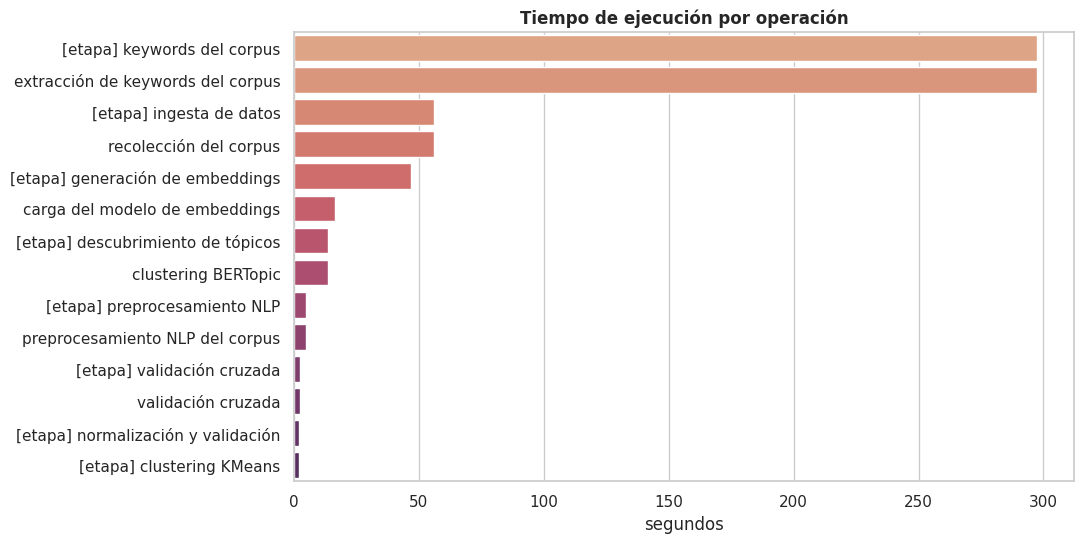

,operacion,segundos_total,invocaciones,porcentaje
0,[etapa] keywords del corpus,297.350,1,69.4
1,extracción de keywords del corpus,297.344,1,69.4
2,[etapa] ingesta de datos,55.963,1,13.1
3,recolección del corpus,55.960,1,13.1
4,[etapa] generación de embeddings,47.070,1,11.0
5,carga del modelo de embeddings,16.423,1,3.8
6,[etapa] descubrimiento de tópicos,13.654,1,3.2
7,clustering BERTopic,13.650,1,3.2
8,[etapa] preprocesamiento NLP,5.104,1,1.2
9,preprocesamiento NLP del corpus,5.102,1,1.2



Tiempo total de las etapas principales: 428.5 s

Estadísticas de la caché de embeddings:
  vectores_en_cache    386
  aciertos             27
  fallos               386
  tasa_acierto         0.0654
  tamano_mb            0.56

En una reejecución del notebook sin cambios de configuración, la tasa de acierto
de la caché debería acercarse al 100% y el tiempo de embeddings caer a casi cero.


In [ ]:
# @title 8.2 — Reporte de tiempos de ejecución
def consolidar_tiempos(registros: list) -> pd.DataFrame:
    """Agrupa los tiempos acumulados por `@cronometrar` y `etapa()`.

    Usa agregación nombrada (`NamedAgg`) en lugar de `.agg(["sum", "count"])`
    seguido de renombrar columnas: esa vía produce un número de columnas que
    depende de la versión de pandas y de si se usó `as_index=False`, y renombrar
    a ciegas rompe con `ValueError: Length mismatch`.

    Args:
        registros: Lista de dicts con las claves `operacion` y `segundos`.

    Returns:
        DataFrame con `operacion`, `segundos_total`, `invocaciones` y
        `porcentaje`, ordenado de mayor a menor tiempo. Vacío con esas mismas
        columnas si no hay registros.

    Example:
        >>> consolidar_tiempos([{"operacion": "x", "segundos": 1.0}]).shape[0]
        1
    """
    columnas = ["operacion", "segundos_total", "invocaciones", "porcentaje"]
    if not registros:
        return pd.DataFrame(columns=columnas)

    crudo = pd.DataFrame(registros)
    if not {"operacion", "segundos"}.issubset(crudo.columns):
        log.warning("Registro de tiempos con formato inesperado; se omite el reporte.")
        return pd.DataFrame(columns=columnas)

    consolidado = (crudo.groupby("operacion", as_index=False)
                        .agg(segundos_total=("segundos", "sum"),
                             invocaciones=("segundos", "count"))
                        .sort_values("segundos_total", ascending=False))

    # Las etapas engloban a las operaciones que contienen, así que el total se
    # calcula sobre ellas para que los porcentajes no sumen más del 100 %.
    etapas = consolidado[consolidado["operacion"].str.startswith("[etapa]")]
    total = etapas["segundos_total"].sum()
    if not total:
        total = consolidado["segundos_total"].sum()

    consolidado["porcentaje"] = (
        (consolidado["segundos_total"] / total * 100).round(1) if total else 0.0
    )
    return consolidado.reset_index(drop=True)


consolidado = consolidar_tiempos(TIEMPOS)

if len(consolidado):
    total = consolidado.loc[
        consolidado["operacion"].str.startswith("[etapa]"), "segundos_total"].sum()
    total = total or consolidado["segundos_total"].sum()

    plt.figure(figsize=(11, max(4, 0.4 * min(len(consolidado), 14))))
    sns.barplot(data=consolidado.head(14), x="segundos_total", y="operacion",
                hue="operacion", palette="flare", legend=False)
    plt.title("Tiempo de ejecución por operación", fontweight="bold")
    plt.xlabel("segundos"); plt.ylabel("")
    plt.tight_layout(); plt.show()

    display(consolidado.head(14))
    print(f"\nTiempo total de las etapas principales: {total:.1f} s")
else:
    print("Sin tiempos registrados: ejecuta las secciones §2 a §7 antes de esta celda.")

print(f"\nEstadísticas de la caché de embeddings:")
for clave, valor in CACHE.estadisticas().items():
    print(f"  {clave:<20} {valor}")
print("\nEn una reejecución del notebook sin cambios de configuración, la tasa de acierto")
print("de la caché debería acercarse al 100% y el tiempo de embeddings caer a casi cero.")

In [ ]:
# @title 8.3 — Empaquetado de entregables
with etapa("empaquetado"):
    shutil.make_archive("techmind_artefactos", "zip", CFG.rutas.models)

print("ENTREGABLES GENERADOS\n")
total_kb = 0
for ruta in sorted(CFG.rutas.base.rglob("*")):
    if ruta.is_file() and ruta.suffix in (".csv", ".json", ".joblib", ".npy", ".py", ".log"):
        kb = ruta.stat().st_size / 1024
        total_kb += kb
        print(f"  {str(ruta):<62} {kb:>9,.1f} KB")

zip_kb = Path("techmind_artefactos.zip").stat().st_size / 1024
print(f"\n  {'techmind_artefactos.zip':<62} {zip_kb:>9,.1f} KB   (listo para OCI Object Storage)")
print(f"\nTotal de artefactos en disco: {total_kb / 1024:.1f} MB")

log.info(f"Empaquetado completo: {zip_kb:.1f} KB")

# En Colab, descarga directa:
# from google.colab import files; files.download("techmind_artefactos.zip")

06:27:29 │ INFO    │ ┌─ etapa · empaquetado
06:27:29 │ INFO    │ └─ etapa · empaquetado completada en 0.03s
ENTREGABLES GENERADOS

  data_science/cache/embeddings_cache.joblib                         545.9 KB
  data_science/datasets/processed/corpus_final.csv                   367.3 KB
  data_science/datasets/processed/corpus_processed.csv             1,070.1 KB
  data_science/datasets/processed/embeddings.npy                     555.1 KB
  data_science/datasets/processed/indice_keywords.json                81.8 KB
  data_science/datasets/processed/resultado_lote.csv                   0.8 KB
  data_science/datasets/processed/resultados_clasificacion.csv        91.8 KB
  data_science/datasets/raw/corpus_raw.csv                           408.9 KB
  data_science/datasets/raw/rechazos.csv                               0.2 KB
  data_science/logs/pipeline.log                                      18.7 KB
  data_science/logs/tiempos_ejecucion.csv                              0.8 KB
  data_scie

---
# 9. Conclusiones

## 9.1 Qué entrega este notebook

### Requisitos obligatorios del brief

| Requisito | Estado | Sección |
|---|---|---|
| Exploración y limpieza de datos (EDA) | ✅ | §2.5, §4.4 |
| Tratamiento de textos | ✅ pipeline spaCy de 4 etapas | §4 |
| Transformación al formato de modelado | ✅ TF-IDF disperso + embeddings densos | §5.1 |
| Entrenamiento y evaluación de modelos | ✅ dos representaciones comparadas bajo el mismo clasificador | §5.3 |
| Métricas de desempeño apropiadas | ✅ accuracy, precision, recall, F1 macro/weighted, top-2, matriz de confusión, CV 5-fold | §5.4 |
| Serialización del modelo (joblib) | ✅ con `metadata.json` de versionado completo | §5.7 |
| Mínimo tres ejemplos de uso | ✅ | §7.3 |
| Integración con OCI | ✅ Object Storage | §8.1 |
| Documentación de dependencias y versiones | ✅ | §0.7 |

### Recursos opcionales cubiertos

| Recurso | Sección |
|---|---|
| Recomendación de contenido relacionado | §6.4 |
| Búsqueda semántica | §6.3 |
| Consulta por categorías | §6.3 (filtrado por metadatos en ChromaDB) |
| Procesamiento en lote (CSV) | §7.4 |
| Pruebas automatizadas | §7.5 — 7 pruebas de sanidad |
| Explicabilidad del modelo | §5.5 — global y local |
| Persistencia de resultados | §6.5 |
| Organización automática por tópicos | §6.2 |

### Mejoras de ingeniería incorporadas en la v2.0.0

| Área | Qué se añadió |
|---|---|
| **Validación** | 7 controles tipificados: presencia, tipo, UTF-8, corrupción/mojibake, longitud mínima y máxima, ratio alfabético, ratio de mayúsculas |
| **Idioma** | Detección con `langdetect` + heurística de respaldo; `RegistroIdiomas` con carga perezosa por idioma |
| **Configuración** | `dataclass` `Config` con 11 bloques, serializable, hasheable; cero valores hardcodeados |
| **Logging** | Logger dual (consola + archivo), decorador `@cronometrar`, context manager `etapa()` |
| **Reproducibilidad** | 5 fuentes de aleatoriedad fijadas: `random`, `numpy`, `torch`, `PYTHONHASHSEED`, `langdetect` |
| **Caché** | Embeddings indexados por hash de (modelo, normalización, texto), persistidos en disco |
| **Explicabilidad** | Ablación por término (agnóstica al modelo) + similitud a centroides de clase |
| **Versionado** | `metadata.json` con versión, fecha, hiperparámetros, métricas, modelo y hash del dataset |
| **API-ready** | `TechMindInference` sin estado global; entrenamiento, carga, predicción y contrato separados |
| **Deduplicación** | Exacta por hash SHA-256 + near-duplicate por Jaccard sobre shingles de 5 palabras |

## 9.2 Limitaciones reconocidas

Enumerarlas no es una formalidad: cada una condiciona cómo deben leerse las métricas reportadas.

1. **Etiquetas débiles (*distant supervision*).** Las categorías provienen del artículo semilla, no de
   anotación humana por párrafo. Un párrafo sobre índices dentro del artículo de PostgreSQL hereda la
   etiqueta *Bases de Datos* aunque podría pertenecer a *Backend*. Las métricas miden concordancia
   con una taxonomía ruidosa, no con verdad de terreno.

2. **Sesgo de fuente única.** Todo el corpus proviene de Wikipedia, cuyo registro es enciclopédico y
   no coincide con el de un tutorial o una anotación de estudio — que son los casos de uso reales del
   brief. El modelo puede degradarse ante texto informal o fragmentario.

3. **Tamaño del corpus.** Con pocos cientos de documentos, los intervalos de confianza de las métricas
   son amplios y HDBSCAN puede marcar como ruido una fracción alta del corpus. La desviación estándar
   entre folds de §5.4.3 es el indicador honesto de esta incertidumbre.

4. **Cobertura finita del `EntityRuler`.** El diccionario de tecnologías es manual: lo que no está
   listado, no se detecta. Cubre las tecnologías más frecuentes, no el largo tail.

5. **Probabilidades no calibradas.** El campo `probabilidad` refleja el orden de confianza relativa
   del modelo, pero no está calibrado: un 0.89 no significa que acierte el 89 % de las veces que
   emite ese valor. La calibración requiere un conjunto de validación adicional.

6. **Un solo idioma en producción.** La arquitectura soporta multilenguaje (§2.2) y el modelo de
   embeddings es multilingüe, pero el clasificador se entrenó solo con documentos en español. Activar
   el inglés requiere datos etiquetados, no cambios de código.

7. **Deduplicación cuadrática.** La comparación de near-duplicates es O(n²) en el número de
   documentos. Aceptable para cientos, inviable para decenas de miles.

## 9.3 Mejoras futuras

Ordenadas por relación entre valor aportado y esfuerzo requerido.

### Corto plazo — funcionalidad

| Mejora | Qué implica | Por qué importa |
|---|---|---|
| **OCR para PDFs e imágenes** | Añadir Tesseract/`pytesseract` o **OCI Vision** como etapa 0 del pipeline, antes de la validación | Buena parte del conocimiento técnico está en PDFs escaneados y capturas; hoy quedan fuera del sistema. OCI Vision además refuerza el requisito de integración cloud |
| **Procesamiento por lotes vía CSV** | Endpoint `POST /contenido/lote` que consuma `predecir_lote` (§7.4, ya implementado) | El caso de uso real es cargar un archivo con cientos de contenidos, no de uno en uno |
| **Consulta por categorías** | Endpoints `GET /temas` y `GET /contenido?categoria=Backend&tema=3` | El filtrado por metadatos de ChromaDB ya lo soporta (§6.3); falta exponerlo |
| **Recomendaciones avanzadas** | Combinar similitud vectorial con señales de comportamiento (co-visitas, feedback explícito), diversificar con MMR | La recomendación actual es puramente semántica: siempre devuelve lo más parecido, nunca lo complementario |

### Medio plazo — calidad del modelo

| Mejora | Qué implica | Por qué importa |
|---|---|---|
| **Ampliar y diversificar el corpus** | Añadir documentación oficial, dev.to, blogs técnicos | Ataca directamente las limitaciones 2 y 3 |
| **Anotación manual de validación** | Etiquetar a mano 200-300 documentos como verdad de terreno | Sin esto, las métricas miden concordancia con etiquetas ruidosas (limitación 1) |
| **Calibración de probabilidades** | `CalibratedClassifierCV` con método isotónico o de Platt | Vuelve el campo `probabilidad` interpretable como confianza real (limitación 5) |
| **Soporte multilenguaje activo** | Recolectar corpus en inglés, reentrenar, cambiar `idiomas_soportados` a `("es", "en")` | La arquitectura ya está lista (§2.2); solo faltan datos |
| **Fine-tuning del modelo de embeddings** | Entrenar SBERT sobre pares de documentos técnicos del dominio | Mejora simultáneamente clasificación, keywords, clustering y búsqueda |

### Medio plazo — operación

| Mejora | Qué implica | Por qué importa |
|---|---|---|
| **Dashboard** | Frontend en Next.js con métricas del corpus, mapa de tópicos, buscador semántico y explorador de categorías | Convierte el sistema en un producto usable, no solo en una API |
| **Monitoreo** | Registrar distribución de categorías predichas, latencia p50/p95/p99 y tasa de confianza baja; alertar ante *data drift* | Un modelo en producción se degrada silenciosamente cuando cambia la distribución de entrada |
| **Pruebas automatizadas en CI** | Llevar las 7 pruebas de §7.5 a `pytest` + pruebas de integración de los endpoints con `TestClient` | Las pruebas del notebook no se ejecutan en cada commit; en CI sí |
| **Reentrenamiento programado** | **OCI Functions** que lea el corpus de PostgreSQL, reentrene y suba la versión nueva a Object Storage | Cierra el ciclo: el modelo mejora al crecer el corpus, sin intervención manual |

### Largo plazo — arquitectura

| Mejora | Qué implica | Por qué importa |
|---|---|---|
| **Migración a `pgvector`** | Unificar metadatos y vectores en PostgreSQL | Elimina una pieza de infraestructura y hace transaccional la escritura conjunta |
| **Deduplicación con MinHash/LSH** | Sustituir la comparación cuadrática por hashing sensible a la localidad | Necesario a partir de decenas de miles de documentos (limitación 7) |
| **Clasificación multietiqueta** | Pasar de `categoria` única a un conjunto de categorías con umbral | Un artículo sobre desplegar modelos de ML en Kubernetes es DevOps *y* Data Science; el top-2 accuracy de §5.4 ya evidencia el problema |
| **Búsqueda híbrida** | Combinar BM25 léxico con similitud vectorial por RRF | La búsqueda semántica falla en consultas de término exacto (números de versión, nombres de error); el léxico las resuelve |

## 9.4 Handoff al equipo de Backend

**Artefactos que el backend consume** (desde `data_science/models/` o desde OCI Object Storage):

```
models/
├── modelo_clasificacion.joblib   # clasificador ganador
├── label_encoder.joblib          # índice ↔ nombre de categoría
├── vectorizador_tfidf.joblib     # solo si el ganador es el modelo A
├── modelo_kmeans.joblib          # respaldo de clustering
├── centroides_clase.joblib       # explicabilidad local
├── modelo_bertopic/              # tópicos + c-TF-IDF (safetensors)
├── config.json                   # configuración exacta del entrenamiento
├── metadata.json                 # versión · métricas · dataset · hiperparámetros
└── techmind_core.py              # capa de inferencia exportada (§7.6)
```

**Integración en `app/services/nlp_service.py`:**

```python
from functools import lru_cache
from pathlib import Path
from techmind_core import TechMindInference

@lru_cache(maxsize=1)
def obtener_servicio() -> TechMindInference:
    # Se carga UNA vez al arrancar el proceso, no por petición.
    return TechMindInference.desde_artefactos(Path("models"))
```

**Integración en `app/api/routes/contenido.py`:**

```python
from fastapi import APIRouter, HTTPException
from fastapi.concurrency import run_in_threadpool

router = APIRouter()

@router.post("/contenido", response_model=ContenidoResponse)
async def procesar_contenido(payload: ContenidoRequest):
    servicio = obtener_servicio()
    try:
        # spaCy y SBERT son síncronos y bloqueantes: van al threadpool
        # para no bloquear el event loop (Technology_Architecture.md §4).
        respuesta = await run_in_threadpool(
            servicio.predecir, payload.titulo, payload.texto
        )
    except ErrorValidacion as exc:
        raise HTTPException(
            status_code=422,
            detail=[{"codigo": c, "mensaje": m} for c, m in exc.resultado.errores],
        )
    return respuesta.a_dict()
```

**Tres advertencias para el equipo de backend:**

1. **No cargar los modelos por petición.** `SentenceTransformer(...)` tarda segundos y ocupa cientos
   de megabytes. Se carga una vez al arrancar, vía `lru_cache` o el evento `startup` de FastAPI.

2. **No ejecutar `predecir()` directamente dentro de un `async def`.** spaCy y SBERT son síncronos y
   bloquean el event loop, dejando al servidor sin atender otras peticiones. Usar
   `run_in_threadpool`, o declarar la ruta como `def` síncrona y dejar que Starlette lo gestione.

3. **Verificar la compatibilidad de versión al arrancar.** Comparar `metadata.json["version"]` contra
   la versión que el backend espera, y fallar ruidosamente si difieren. Un artefacto de una versión
   incompatible produce predicciones silenciosamente erróneas, que es el peor modo de fallo posible.

In [ ]:
# @title 9.5 — Resumen final de la ejecución
print("=" * 78)
print(f"  TECHMIND — PIPELINE DE CIENCIA DE DATOS v{CFG.version}")
print("=" * 78)

print(f"\n  CORPUS")
print(f"    documentos procesados    : {len(df)}")
print(f"    categorías               : {len(CATEGORIAS)}")
print(f"    rechazados en validación : {len(df_rechazados)}")
print(f"    duplicados eliminados    : {REPORTE_DEDUP['duplicados_exactos'] + REPORTE_DEDUP['near_duplicates']}")
print(f"    idiomas                  : {dict(df['idioma'].value_counts())}")
print(f"    hash del dataset         : {METADATOS['dataset']['hash_sha256'][:32]}...")

print(f"\n  MODELO")
print(f"    clasificador             : {METADATOS['modelo']['tipo_clasificador']}")
print(f"    embeddings               : {CFG.embeddings.modelo}")
print(f"    accuracy   (test)        : {METADATOS['metricas']['conjunto_prueba']['accuracy']:.4f}")
print(f"    precision  (macro)       : {METADATOS['metricas']['conjunto_prueba']['precision_macro']:.4f}")
print(f"    recall     (macro)       : {METADATOS['metricas']['conjunto_prueba']['recall_macro']:.4f}")
print(f"    f1_macro   (test)        : {METADATOS['metricas']['conjunto_prueba']['f1_macro']:.4f}")
_cv = METADATOS["metricas"]["validacion_cruzada"]
if _cv["media"] is not None:
    print(f"    f1_macro   (CV {_cv['folds_efectivos']}-fold)   : {_cv['media']:.4f} "
          f"± {_cv['desviacion']:.4f}")
else:
    print(f"    f1_macro   (CV)          : no disponible (corpus insuficiente)")
_top2 = METADATOS["metricas"]["conjunto_prueba"].get("top2_accuracy")
if _top2 is not None and not pd.isna(_top2):
    print(f"    top-2 accuracy           : {_top2:.4f}")
else:
    print(f"    top-2 accuracy           : no aplica ({len(CATEGORIAS)} categorías)")

print(f"\n  ORGANIZACIÓN")
print(f"    tópicos BERTopic         : {METADATOS['modelo']['n_topicos_bertopic']}")
print(f"    clusters KMeans          : {K_OPTIMO}")
print(f"    documentos indexados     : {coleccion.count()}")

print(f"\n  INGENIERÍA")
print(f"    huella de configuración  : {CFG.huella()[:32]}...")
print(f"    caché de embeddings      : {CACHE.estadisticas()['vectores_en_cache']} vectores "
      f"(acierto {CACHE.estadisticas()['tasa_acierto']:.0%})")
print(f"    operaciones cronometradas: {len(TIEMPOS)}")
print(f"    pruebas superadas        : {len(PRUEBAS) - fallos}/{len(PRUEBAS)}")
print(f"    log de ejecución         : {CFG.rutas.logs / 'pipeline.log'}")

print("\n" + "=" * 78)
print("  Pipeline completado. Artefactos listos para el backend en FastAPI.")
print("=" * 78)

log.info(f"PIPELINE COMPLETADO — v{CFG.version} — "
         f"f1_macro={METADATOS['metricas']['conjunto_prueba']['f1_macro']:.4f}")

  TECHMIND — PIPELINE DE CIENCIA DE DATOS v2.0.0

  CORPUS
    documentos procesados    : 370
    categorías               : 8
    rechazados en validación : 2
    duplicados eliminados    : 7
    idiomas                  : {'es': np.int64(370)}
    hash del dataset         : 713a6e7bb33651ea8975d5f0c553e1b0...

  MODELO
    clasificador             : tfidf+logreg
    embeddings               : paraphrase-multilingual-MiniLM-L12-v2
    accuracy   (test)        : 0.8602
    precision  (macro)       : 0.8578
    recall     (macro)       : 0.8589
    f1_macro   (test)        : 0.8544
    f1_macro   (CV 5-fold)   : 0.8532 ± 0.0488
    top-2 accuracy           : 0.9677

  ORGANIZACIÓN
    tópicos BERTopic         : 7
    clusters KMeans          : 13
    documentos indexados     : 370

  INGENIERÍA
    huella de configuración  : ac475d0930389a56dd3496e86f899bcf...
    caché de embeddings      : 386 vectores (acierto 7%)
    operaciones cronometradas: 28
    pruebas superadas        : 10/10
